<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Numerical_Simulation_of_Electron_Hydrodynamic_Refrigeration_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using the verified cached numerical environment.
Running the simulation and preparing the figures...
Collision integration: NVIDIA L4, float64, at most 32,768 sampled quartets per batch.
Using the matching cached collision integrals.
Flow: 272 cells, 498 faces, R=48.875 ohm, continuity=1.19e-14; CPU sparse LU (RCM plus COLAMD), 0.0 s
Conservation, zero-bias, and thermoelectric sign checks passed.
Model: resolved binary collisions + hydrodynamic electronic refrigeration.
CUDA verified: NVIDIA L4, free VRAM 21.5 GiB.
Flow: 6,421 cells, 12,624 faces, R=45.241 ohm, continuity=1.39e-13; CPU sparse LU (RCM plus COLAMD), 0.4 s
Thermal benchmark: CPU 0.0268 s, GPU 0.5383 s; selected CuPy GPU.
Simulation: 20 s elapsed...
hydro mesh 1: t=0.063 ns, ROI=149.835 K, 25 accepted steps.
Simulation: 40 s elapsed...
Simulation: 60 s elapsed...
hydro mesh 1: t=0.460 ns, ROI=149.063 K, 38 accepted steps.
Simulation: 80 s elapsed...
hydro mesh 1: ROI=148.8514 K, cooling=1.1486 K, 85 accepted/0 rejected ste

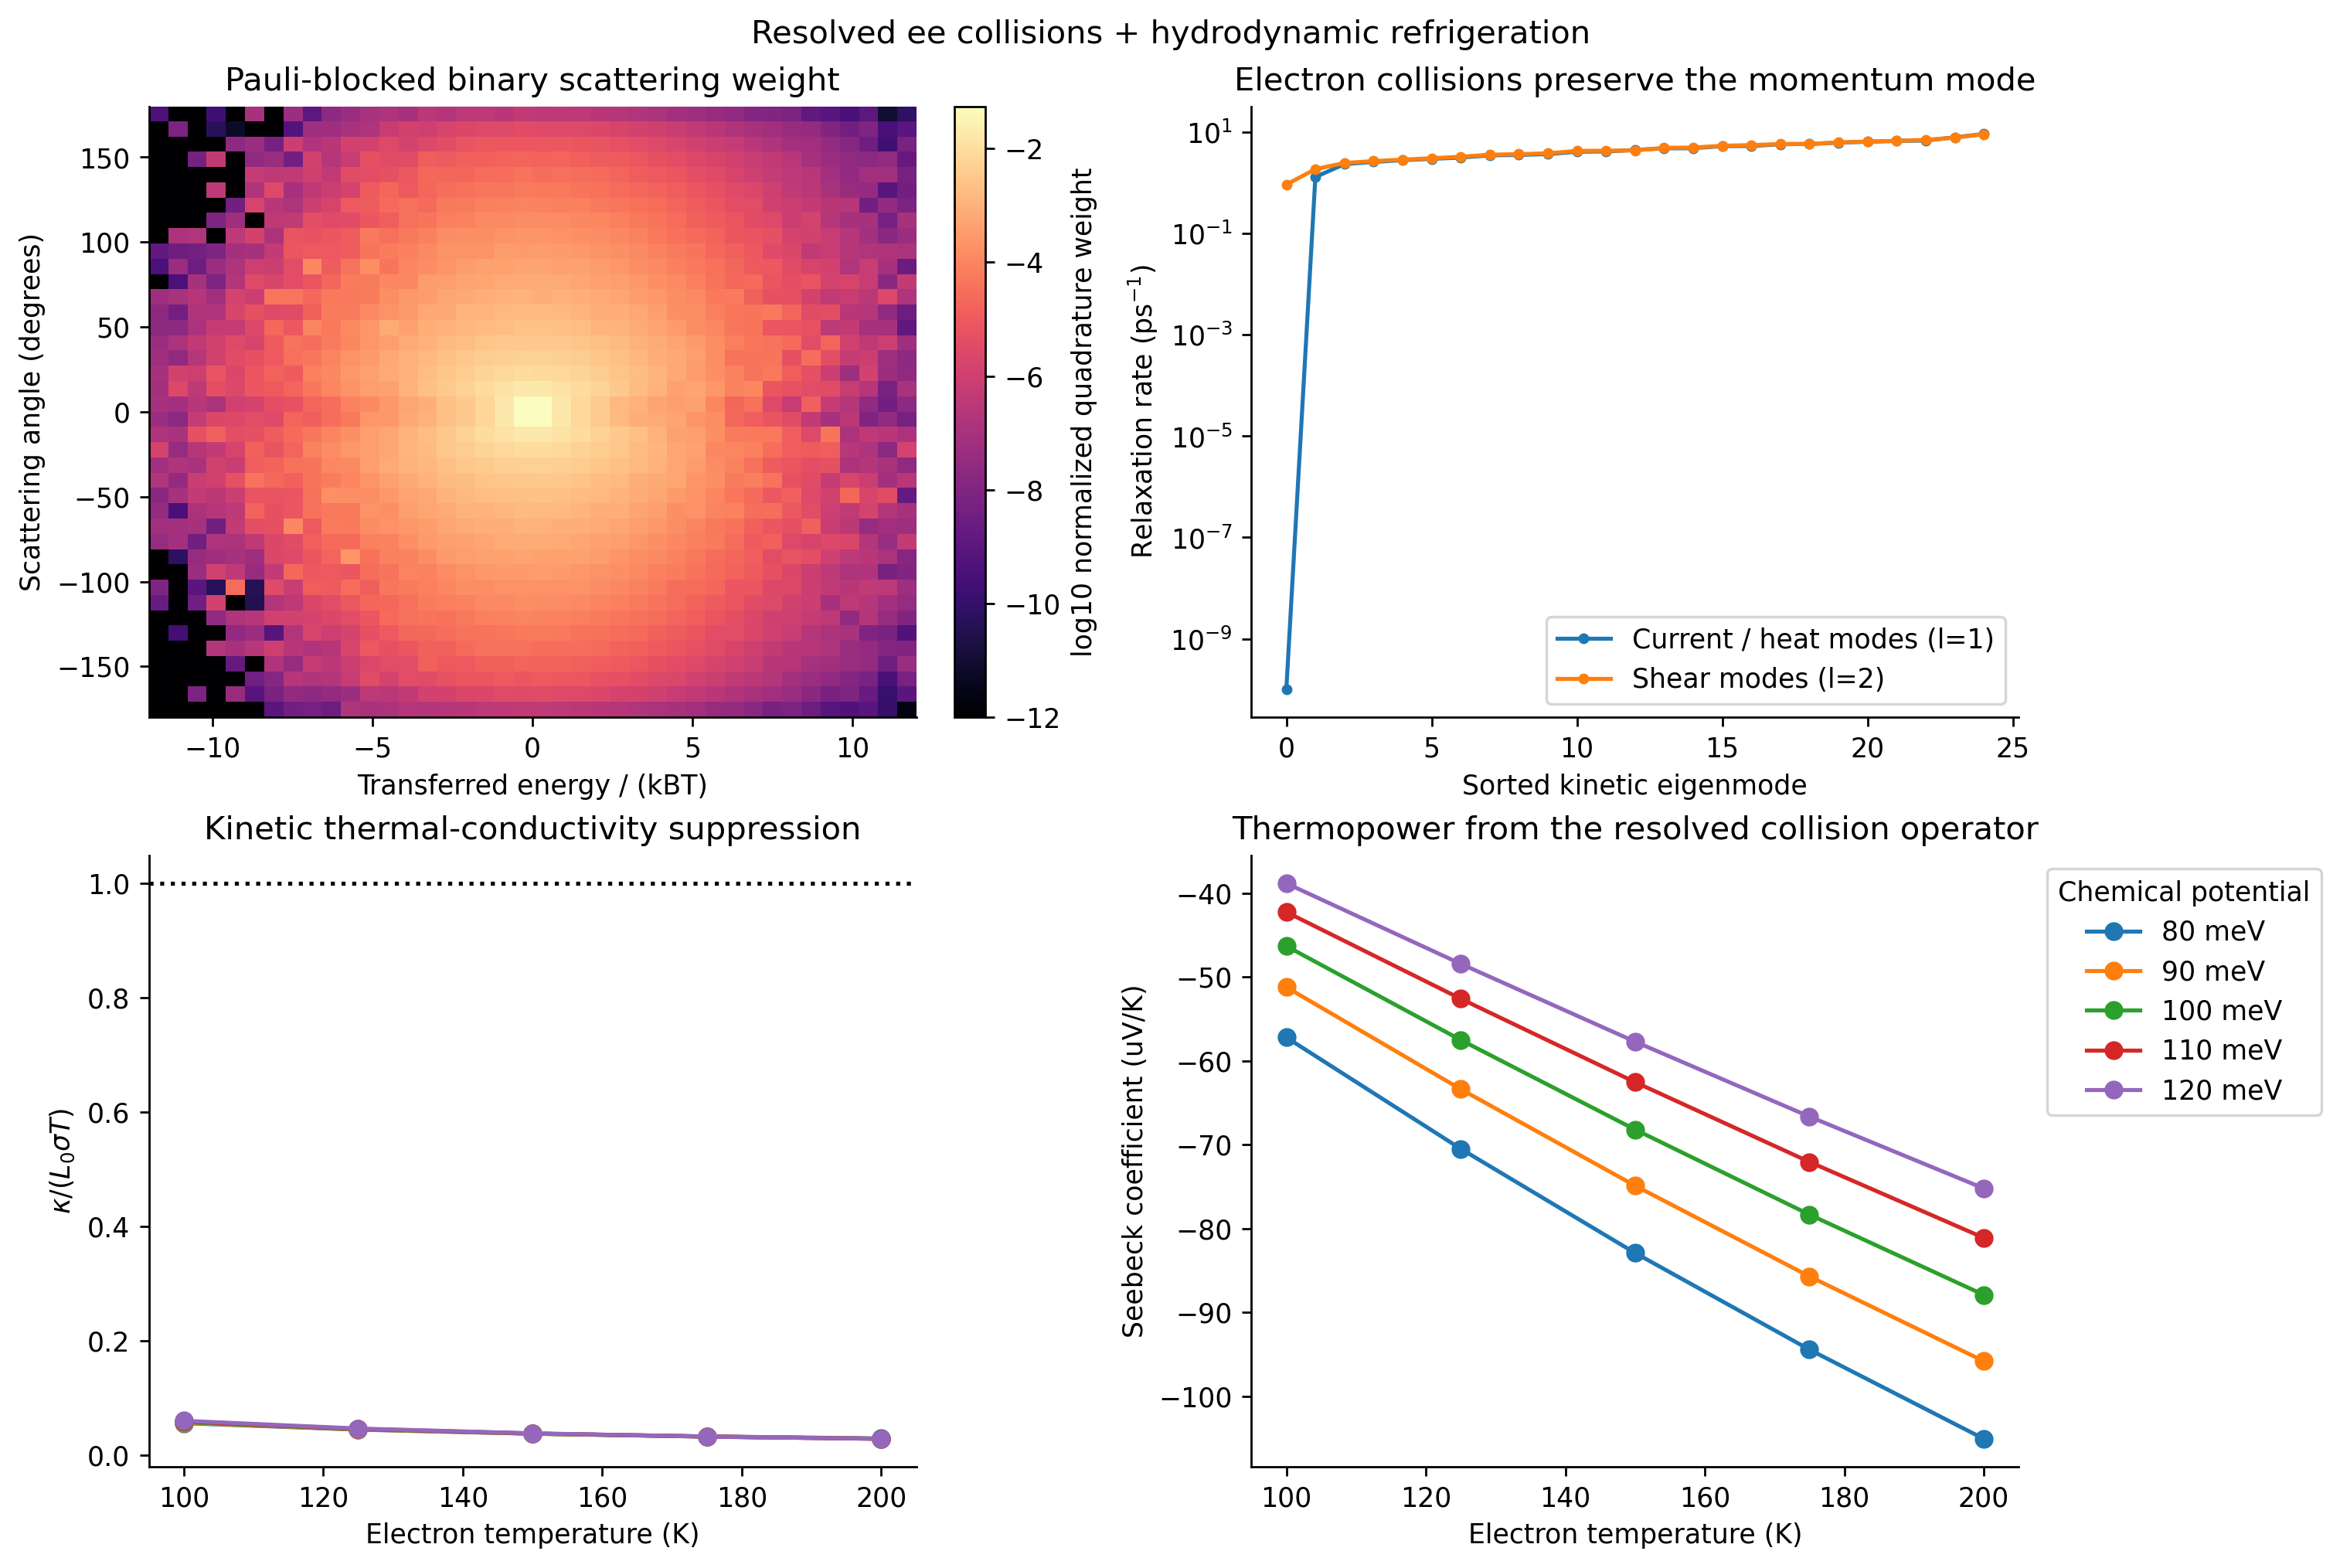

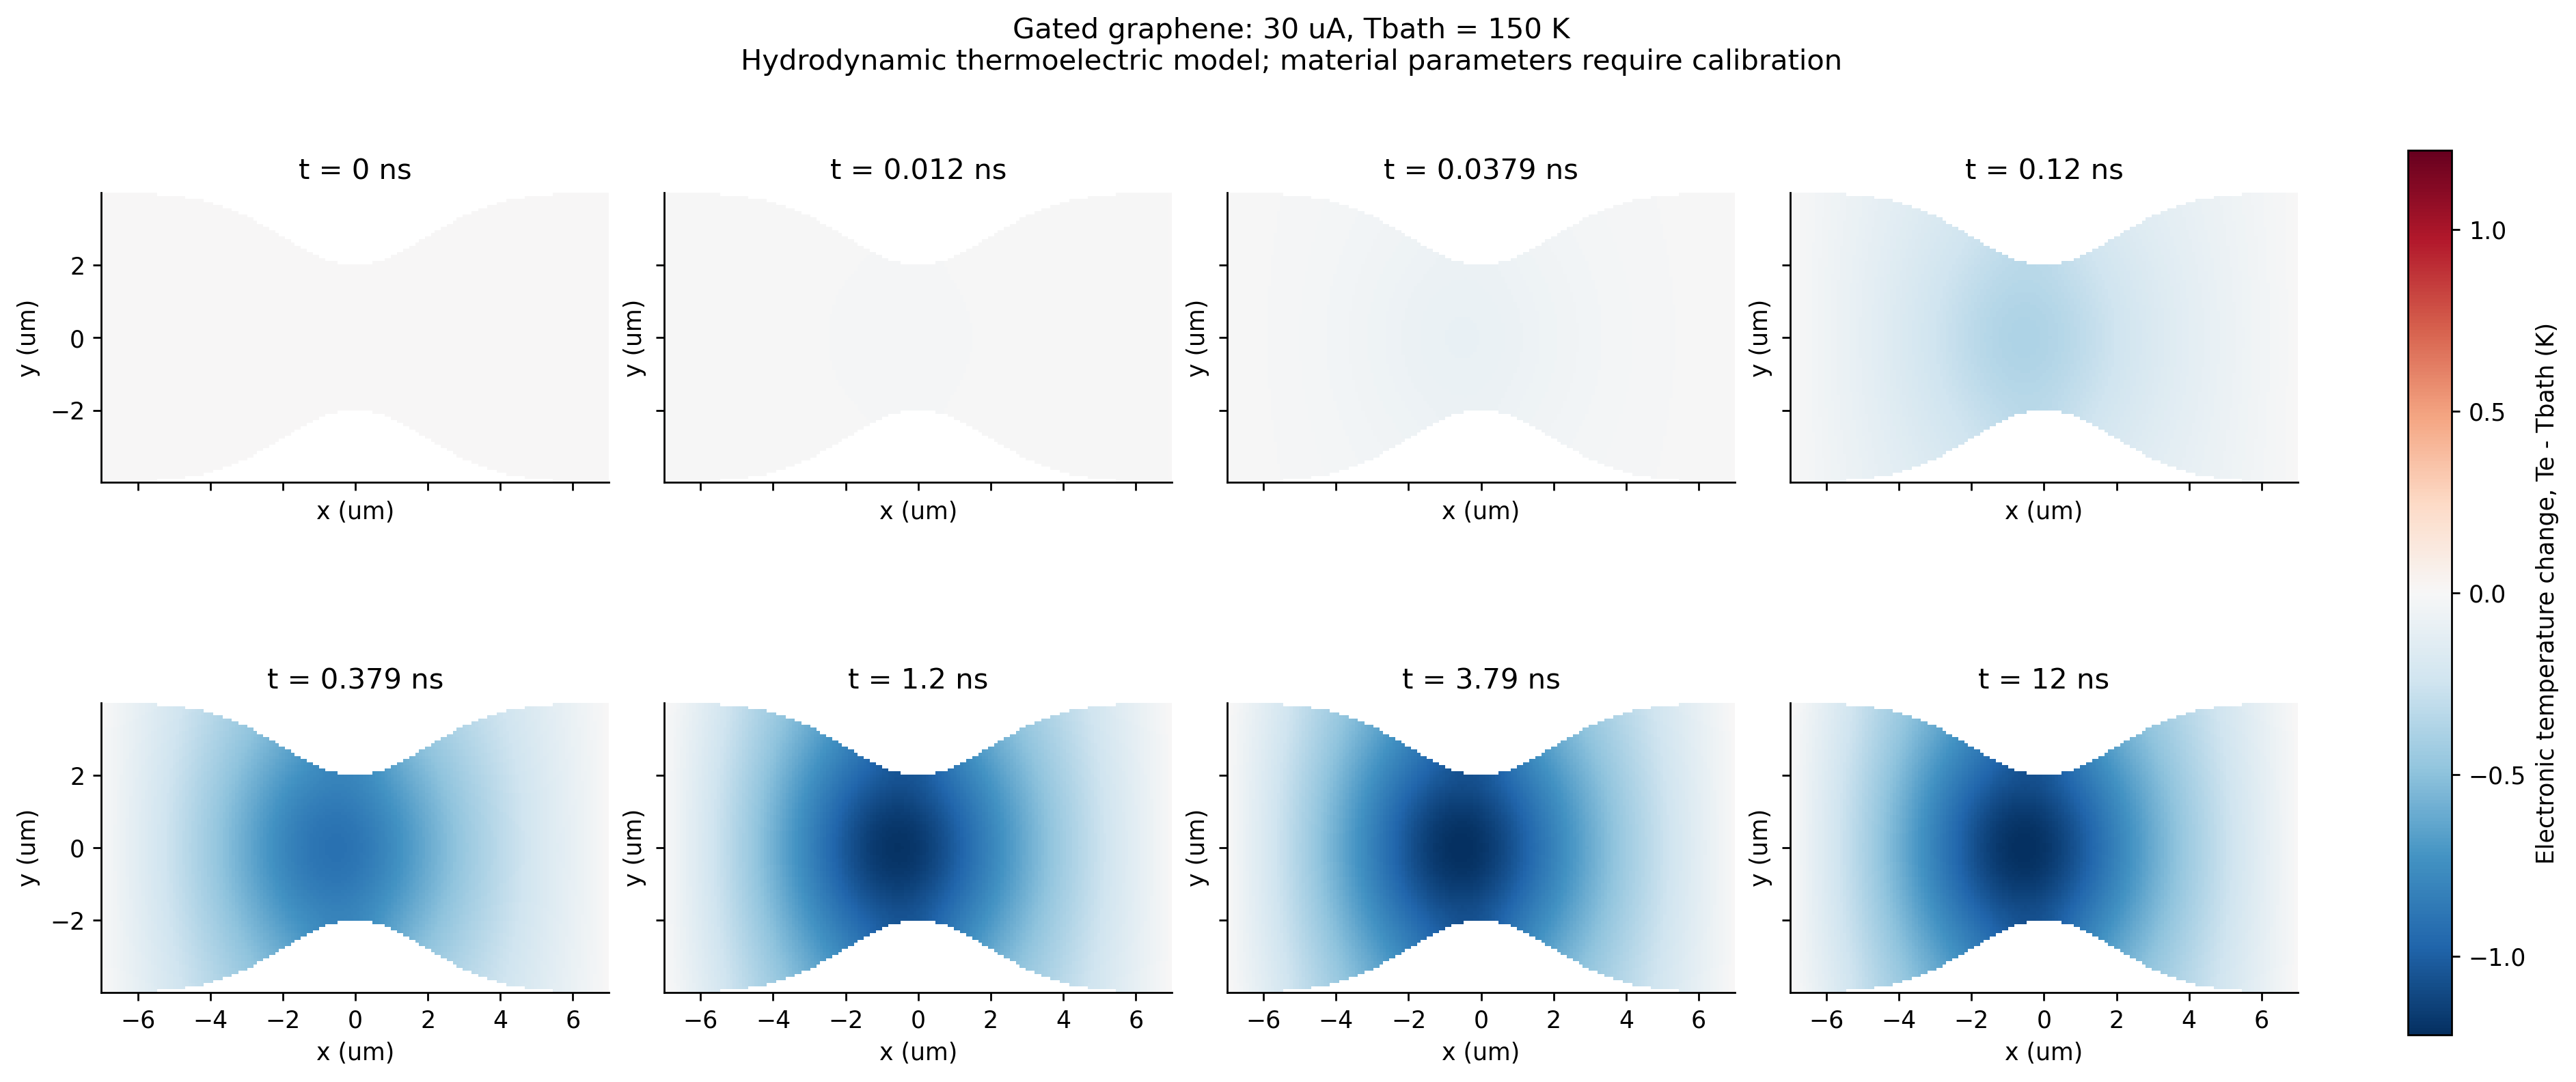

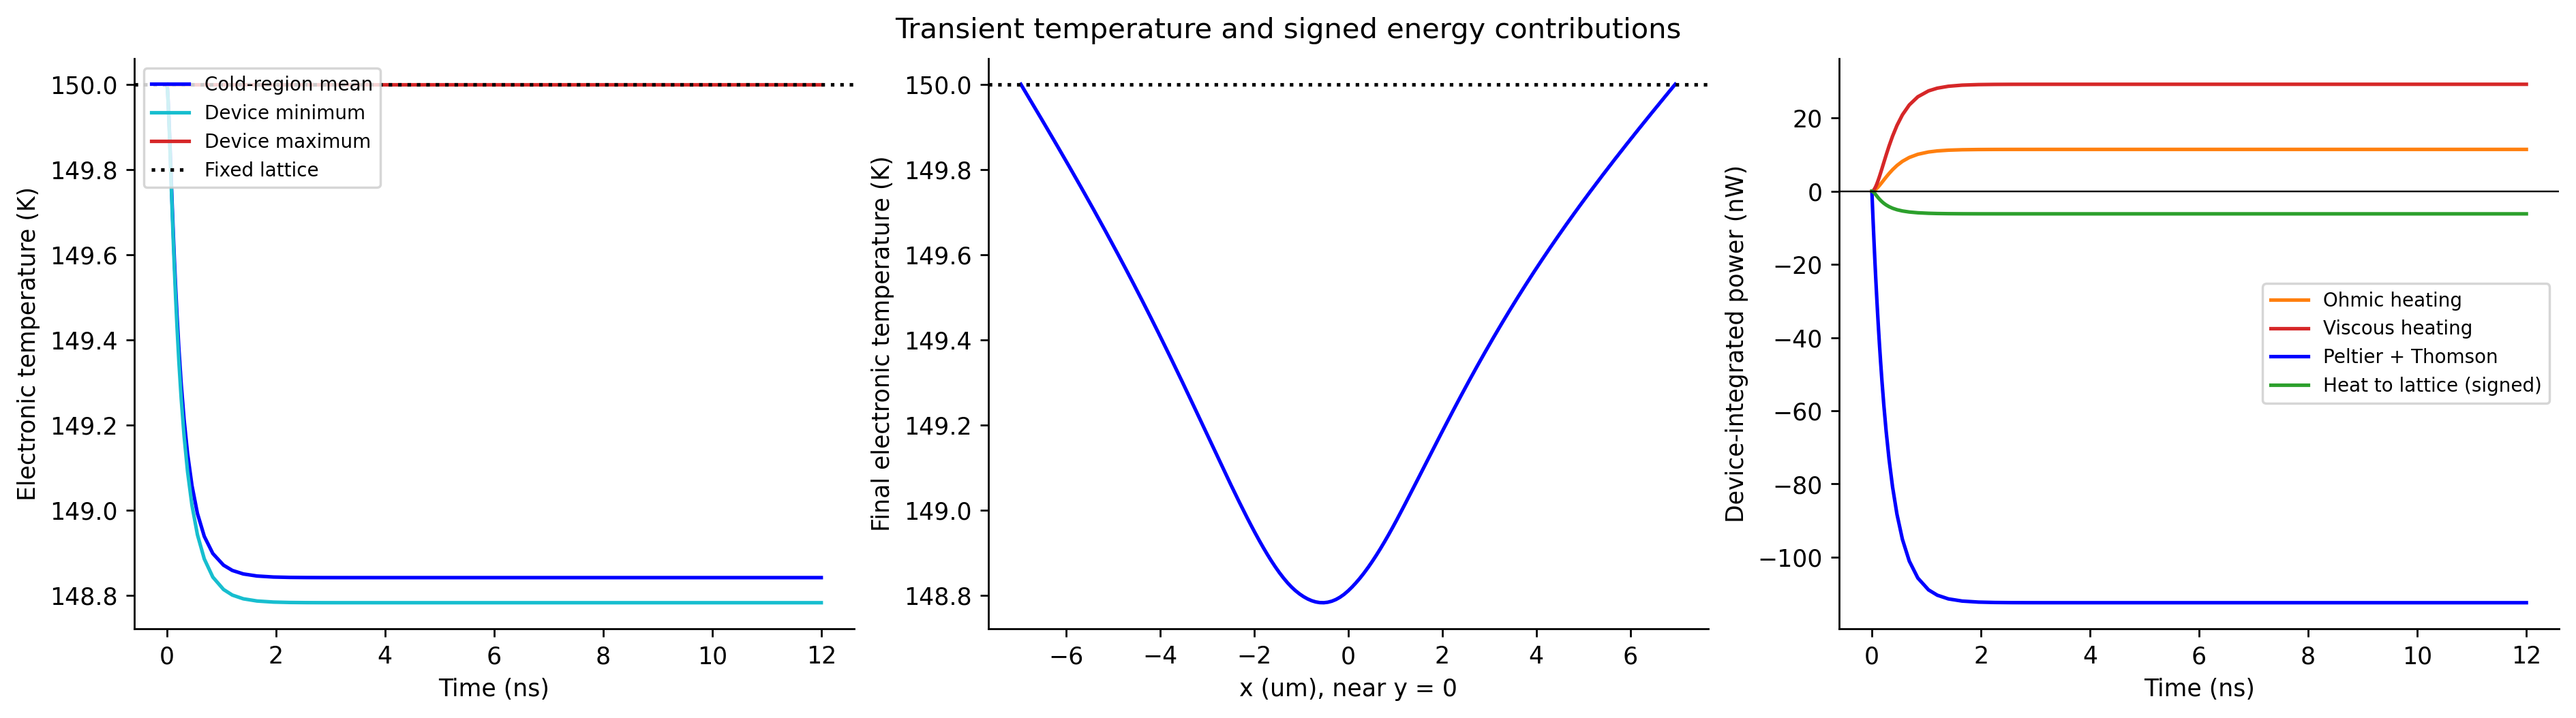

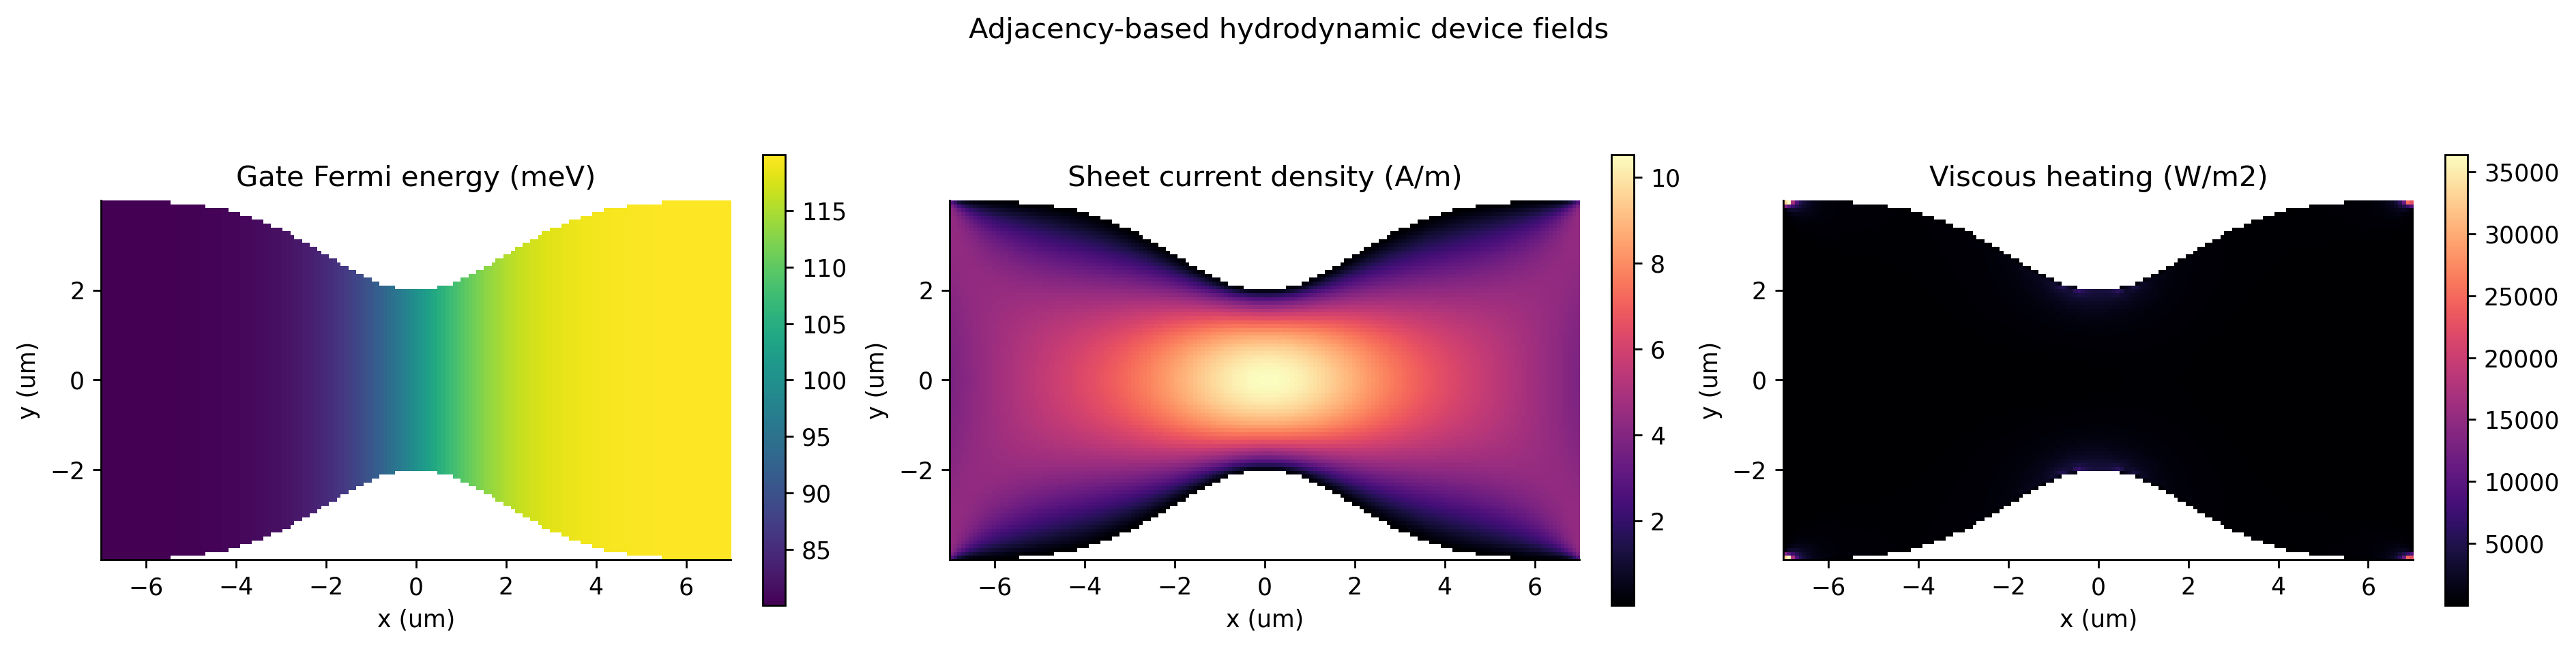

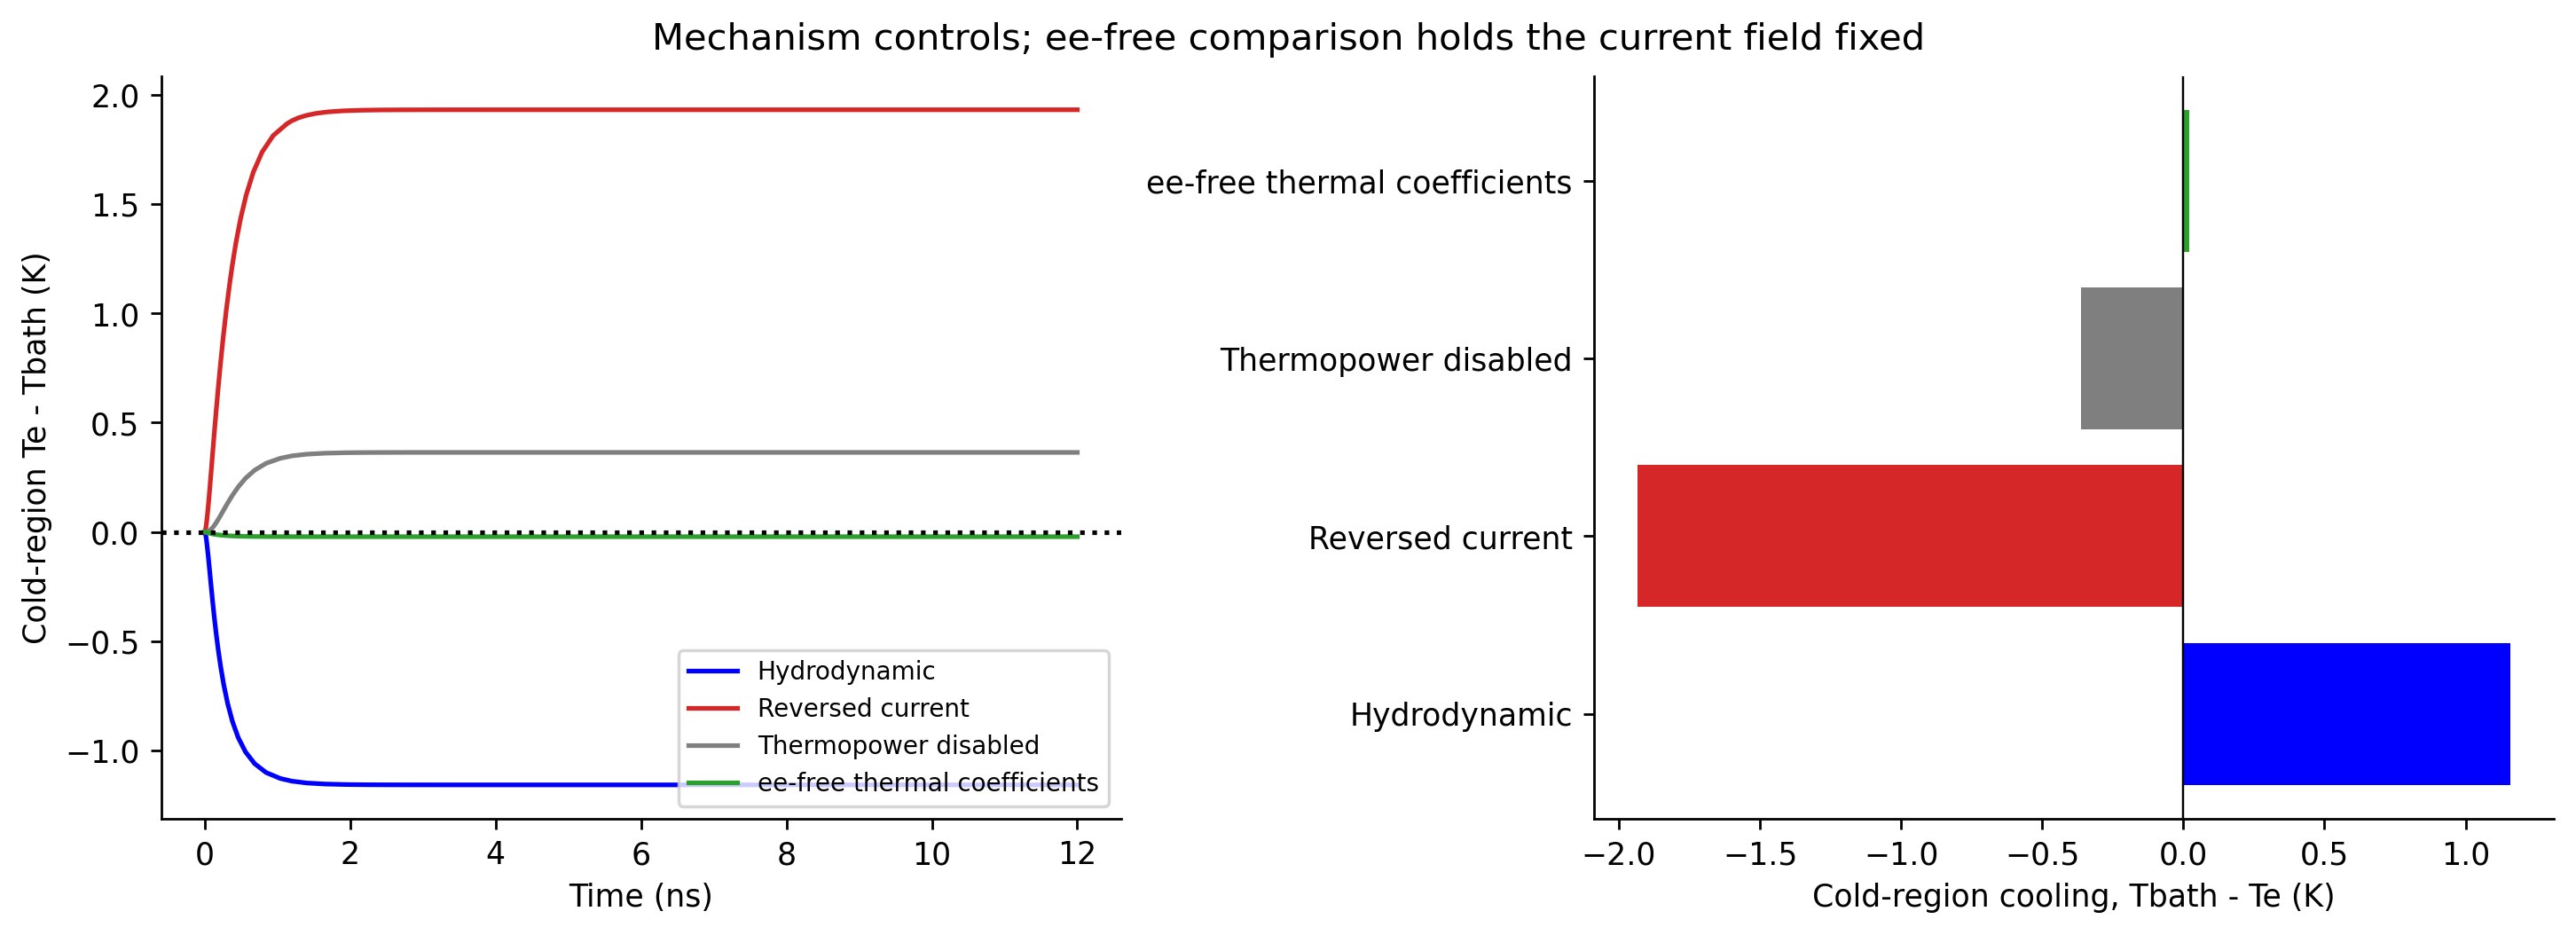

/content/electron_hydrodynamic_results/electron_hydrodynamic_results.zip

In [6]:
"""Predict electronic refrigeration using resolved graphene binary collisions.

The collision calculation requires a CUDA GPU such as the Colab NVIDIA L4.
--cpu selects a CPU calculation; --quick selects a coarse preview;
--kwant adds the independent coherent reference; --validate-only runs checks.
Edit CONFIG below to change the physical parameters and numerical controls.

Microscopic model
-----------------
A linearized semiclassical Boltzmann collision integral resolves intraband
2 -> 2 electron-electron scattering in electron-doped graphene. Scrambled
Sobol quadrature integrates incoming energies and continuous scattering
angles. Outgoing momenta follow an exact energy-conserving ellipse, with
momentum conservation enforced algebraically. Fermi factors implement Pauli
blocking and detailed balance. Positive collision quadratic forms determine
energy-resolved current/heat (angular harmonic l=1) and shear (l=2) response.
The electron-electron momentum null mode is preserved by the radial linear
basis, without a fitted electron-electron relaxation time or BGK closure.

The screened direct Born matrix element contains graphene chirality overlaps
and a doped, long-wavelength dynamical polarization approximation, evaluated
across the sampled momentum transfers. Spin and valley degeneracy are both
included, for g=4. An elastic angular-relaxation operator represents disorder
with a specified tau_mr. Electron-phonon energy loss remains a specified
Sigma*(Te**p-Tbath**p) heat-leak law. These modelinputs require material
and experimental calibration.

Kinetic transport coefficients sigma, S, kappa, and eta are calculated from
the collision operators and interpolated over chemical potential and electron
temperature. Independent scrambles, a refined radial basis, a smaller numerical
screening regulator, and an off-grid table probe measure numerical sensitivity.

Device model
------------
Local kinetic coefficients drive a reduced 2D finite-volume electronic
refrigeration geometry. A positive Brinkman dissipation functional produces a
charge-conserving viscous current field. Flow coefficients are frozen at the
bath temperature; thermoelectric feedback on this current field is neglected.
Uniform end-face current injection and no-slip side walls omit detailed contact
boundary layers. This kinetic-plus-hydrodynamic reduction is appropriate only
when calculated scattering lengths are shorter than device-gradient scales.

The nonlinear electronic energy equation includes conduction, Ohmic and
viscous heating, Kelvin-consistent Peltier/Thomson terms, electron-phonon
exchange, and an optional thermal load. Density and heat capacity retain
leading degenerate, single-carrier approximations; chemical potentials are
held at their gate-defined values. Electron-electron collisions redistribute
energy and are never an energy sink. End reservoirs and lattice stay at the
bath temperature. Only the electron temperature is refrigerated. Lattice
cooling, Joule-Thomson expansion, charge-neutral Dirac-fluid transport,
millikelvin operation, and microscopic gold-contact filtering are excluded.

Resources and outputs
---------------------
CuPy evaluates binary collision samples in VRAM-limited float64 batches;
only small radial collision matrices are retained. No quartic collision tensor
or full device phase-space matrix is allocated. Resource-limited adjacency
meshes, sparse CPU flow solves, benchmark-selected thermal CPU/GPU solves,
and adaptive implicit time steps control the macroscopic workload. Plots are
rendered in memory at 250 DPI. The output archive includes collision matrices,
kinetic spectra, transport tables, temperature maps, 1D traces, conservation
checks, mechanism controls, and a JSON report.

References
----------
[1] Briskot et al., Phys. Rev. B 92, 115426 (2015), Appendix A.
    https://doi.org/10.1103/PhysRevB.92.115426
    https://arxiv.org/html/1507.08946v1
[2] Xie and Foster, Phys. Rev. B 93, 195103 (2016).
    https://doi.org/10.1103/PhysRevB.93.195103
[3] Brida et al., Nature Communications 4, 1987 (2013), Figure 4.
    https://doi.org/10.1038/ncomms2987
[4] Andersen, Smith, and Principi, Phys. Rev. Lett. 122, 166802 (2019).
    https://doi.org/10.1103/PhysRevLett.122.166802
[5] Vera-Marun et al., Nature Communications 7, 11525 (2016).
    https://doi.org/10.1038/ncomms11525
[6] Groth et al., New J. Phys. 16, 063065 (2014).
    https://doi.org/10.1088/1367-2630/16/6/063065
[7] https://docs.cupy.dev/en/stable/install.html

"""

from __future__ import annotations

import argparse
import ast
import builtins
from collections import deque
from dataclasses import asdict, dataclass, replace
import hashlib
import importlib.metadata
import inspect
import io
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys
import tarfile
import tempfile
import threading
import time
import urllib.request
import warnings
import zipfile

# -----------------------------------------------------------------------------
# Control knobs - geometry and graphene material parameters
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class Config:
    """Store physical parameters, solver limits, and output controls."""

    length_um: float = 14.0
    lead_width_um: float = 8.0
    neck_width_um: float = 4.0
    constriction_scale_um: float = 2.0
    gate_transition_um: float = 2.0
    mu_left_ev: float = 0.080
    mu_right_ev: float = 0.120
    bath_t_k: float = 150.0
    fermi_velocity_m_s: float = 1.0e6
    momentum_relaxation_ps: float = 20.0
    current_ua: float = 30.0
    phonon_sigma_w_m2_kp: float = 0.002
    phonon_power: int = 3
    external_load_nw: float = 0.0
    load_radius_um: float = 0.75
    roi_half_length_um: float = 0.75
    roi_half_width_um: float = 1.0

    # Control knobs - resolved, intraband two-electron collision integral.
    dielectric_relative: float = 4.5
    spin_valley_degeneracy: int = 4
    collision_energy_nodes: int = 25
    collision_thermal_window: float = 12.0
    collision_samples_log2: int = 18
    collision_max_samples_log2: int = 20
    collision_replicates: int = 2
    collision_batch_size: int = 32768
    collision_seed: int = 1729
    collision_relative_tolerance: float = 0.02
    collision_screening_broadening: float = 1.0e-5
    collision_mu_points: int = 5
    collision_temperature_points: int = 5
    collision_temperature_min_k: float = 100.0
    collision_temperature_max_k: float = 200.0
    collision_gpu_required: bool = True
    collision_run_resolution_probe: bool = True
    collision_cache: bool = True

    # Control knobs - automatic global mesh and resource limits.
    initial_cell_nm: float = 120.0
    refinement_ratio: float = 1.4
    max_refinement_levels: int = 2
    mesh_temperature_tolerance_k: float = 0.15
    max_cells: int = 18000
    ram_fraction: float = 0.25
    gpu_memory_fraction: float = 0.30
    flow_direct_max_unknowns: int = 60000
    flow_rtol: float = 1.0e-10
    thermal_rtol: float = 2.0e-10
    krylov_maxiter: int = 3500
    gpu_mode: str = "on"  # "auto", "on", or "off".
    gpu_required: bool = True
    gpu_min_speedup: float = 1.15

    # Control knobs - quasistatic-current ramp and electronic transients.
    duration_ns: float = 12.0
    current_ramp_ns: float = 0.30
    snapshots: int = 8
    initial_step_ps: float = 2.0
    min_step_ps: float = 0.01
    max_step_ps: float = 300.0
    max_temperature_step_k: float = 0.35
    nonlinear_tolerance_k: float = 2.0e-6
    nonlinear_maxiter: int = 28
    nonlinear_relaxation: float = 0.80
    energy_balance_rtol: float = 2.0e-5
    max_temperature_k: float = 200.0
    min_temperature_k: float = 100.0
    max_steps: int = 8000
    run_controls: bool = True

    # Control knobs - independent, smaller coherent Kwant reference.
    run_kwant: bool = False
    kwant_geometry_scale: float = 0.014
    kwant_lattice_nm: float = 2.0
    kwant_max_sites: int = 18000
    kwant_energy_points: int = 25
    kwant_thermal_window: float = 6.0
    kwant_max_band_fraction: float = 0.65

    # Control knobs - in-memory plotting and reproducible output files.
    dpi: int = 250
    display_figures: bool = True
    save_figures: bool = True
    output_directory: str = "electron_hydrodynamic_results"


CONFIG = Config()

# -----------------------------------------------------------------------------
# Control knobs - automatic dependency setup and private runtime cache
# -----------------------------------------------------------------------------

RUNTIME_CACHE = (
    Path(
        os.environ.get(
            "ELECTRON_HYDRO_RUNTIME_DIR",
            str(
                Path("/content/.electron_hydro_runtime")
                if Path("/content").exists()
                else Path(tempfile.gettempdir()) / "electron_hydro_runtime"
            ),
        )
    )
    .expanduser()
    .resolve()
)
SETUP_PROGRESS_SECONDS = 20.0
DOWNLOAD_TIMEOUT_SECONDS = 60.0
AUTO_PACKAGES = (
    "python=3.11",
    "numpy=1.26.*",
    "scipy>=1.13,<1.16",
    "kwant=1.5.*",
    "matplotlib>=3.8,<3.11",
    "psutil",
    "pillow",
    "threadpoolctl",
    "cupy=13.6.*",
    "cuda-version=12.4",
    "cuda-cudart-dev=12.4.*",
)
# A notebook may retain __file__ from an earlier execution. Use the current
# compiled code's filename to distinguish a file from a newly pasted cell.
_SCRIPT_CODE_FILENAME = sys._getframe().f_code.co_filename
_RUNNING_FROM_FILE = Path(_SCRIPT_CODE_FILENAME).is_file()
_SCRIPT_ARGUMENTS = sys.argv[1:] if _RUNNING_FROM_FILE else []


def runtime_environment(prefix: Path) -> dict[str, str]:
    """Return an isolated child-process environment for the numerical stack."""
    environment = os.environ.copy()
    environment.pop("PYTHONPATH", None)
    environment.pop("PYTHONHOME", None)
    environment.pop("CUDA_PATH", None)
    for toolkit_root in (prefix, prefix / "targets" / "x86_64-linux"):
        if (toolkit_root / "include" / "cuda_runtime.h").exists():
            environment["CUDA_PATH"] = str(toolkit_root)
            break
    environment["PYTHONNOUSERSITE"] = "1"
    environment["MPLBACKEND"] = "Agg"
    environment["OPENBLAS_NUM_THREADS"] = "2"
    environment["OMP_NUM_THREADS"] = "2"
    environment["CONDA_PREFIX"] = str(prefix)
    environment["PATH"] = os.pathsep.join(
        [str(prefix / "bin"), environment.get("PATH", "")]
    )
    environment["LD_LIBRARY_PATH"] = os.pathsep.join(
        [
            str(prefix / "lib"),
            str(prefix / "targets" / "x86_64-linux" / "lib"),
            environment.get("LD_LIBRARY_PATH", ""),
        ]
    )
    return environment


def run_automatic_command(
    command: list[str],
    label: str,
    environment: dict[str, str],
    quiet: bool = False,
) -> None:
    """Run a subprocess with periodic progress and readable failure details."""
    started = time.monotonic()
    recent_lines = deque(maxlen=40)
    process = subprocess.Popen(
        command,
        env=environment,
        stdin=subprocess.DEVNULL,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    def relay_output() -> None:
        """Drain the child pipe while retaining the latest diagnostic lines."""
        for line in process.stdout:
            recent_lines.append(line.rstrip())
            if not quiet:
                print(line, end="", flush=True)

    relay = threading.Thread(target=relay_output, daemon=True)
    relay.start()
    try:
        while True:
            try:
                return_code = process.wait(timeout=SETUP_PROGRESS_SECONDS)
                break
            except subprocess.TimeoutExpired:
                elapsed = time.monotonic() - started
                print(f"{label}: {elapsed:.0f} s elapsed...", flush=True)
    except BaseException:
        process.terminate()
        try:
            process.wait(timeout=5.0)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait()
        raise
    finally:
        relay.join(timeout=5.0)
    if return_code != 0:
        details = "\n".join(recent_lines)
        raise RuntimeError(
            f"{label} failed with exit code {return_code}.\n{details}"
        )


def automatic_micromamba(cache: Path) -> Path:
    """Fetch a standalone Linux executable using standard-library tools."""
    executable = cache / "bin" / "micromamba"
    if executable.exists() and os.access(executable, os.X_OK):
        return executable
    if sys.platform != "linux" or platform.machine() not in {
        "x86_64",
        "amd64",
    }:
        raise RuntimeError(
            "Automatic setup targets Colab's Linux x86_64 host."
        )
    executable.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://micro.mamba.pm/api/micromamba/linux-64/latest",
        "https://github.com/mamba-org/micromamba-releases/"
        "releases/latest/download/micromamba-linux-64",
    )
    errors = []
    for url in urls:
        try:
            request = urllib.request.Request(
                url, headers={"User-Agent": "electron-hydro-colab/1.0"}
            )
            data = io.BytesIO()
            last_progress = time.monotonic()
            with urllib.request.urlopen(
                request, timeout=DOWNLOAD_TIMEOUT_SECONDS
            ) as response:
                while chunk := response.read(1024 * 1024):
                    data.write(chunk)
                    if data.tell() > 64 * 1024**2:
                        raise ValueError(
                            "Environment-manager download too large."
                        )
                    if (
                        time.monotonic() - last_progress
                        > SETUP_PROGRESS_SECONDS
                    ):
                        print(
                            "Downloading the automatic installer...",
                            flush=True,
                        )
                        last_progress = time.monotonic()
            data.seek(0)
            if data.read(4) == b"\x7fELF":
                binary = data.getvalue()
            else:
                data.seek(0)
                # Extract only the requested executable, never arbitrary paths.
                with tarfile.open(fileobj=data, mode="r:*") as archive:
                    member = archive.getmember("bin/micromamba")
                    if not member.isfile() or member.size > 64 * 1024**2:
                        raise ValueError("Unexpected installer archive entry.")
                    stream = archive.extractfile(member)
                    if stream is None:
                        raise ValueError("Installer executable is missing.")
                    with stream:
                        binary = stream.read()
            if not binary.startswith(b"\x7fELF"):
                raise ValueError(
                    "Downloaded installer is not a Linux executable."
                )
            temporary = executable.with_suffix(".partial")
            temporary.write_bytes(binary)
            temporary.chmod(0o755)
            temporary.replace(executable)
            return executable
        except (OSError, ValueError, tarfile.TarError) as error:
            errors.append(str(error))
    raise RuntimeError(
        "Automatic installer download failed. Check the runtime's internet "
        "connection and rerun the same cell.\n" + "\n".join(errors)
    )


def resolve_script_source(cache: Path) -> Path:
    """Resolve a file or capture the full Colab cell for child execution."""
    if _RUNNING_FROM_FILE:
        return Path(_SCRIPT_CODE_FILENAME).resolve()
    shell_getter = globals().get("get_ipython") or getattr(
        builtins, "get_ipython", None
    )
    if shell_getter is None:
        raise RuntimeError("Execute the complete script in one Colab cell.")
    shell = shell_getter()
    history = shell.history_manager.input_hist_raw
    if not history:
        raise RuntimeError("The current Colab cell source is unavailable.")
    source = history[-1]
    parsed = ast.parse(source)
    names = {
        node.name
        for node in parsed.body
        if isinstance(node, (ast.FunctionDef, ast.ClassDef))
    }
    if not {"Config", "prepare_environment", "main"}.issubset(names):
        raise RuntimeError("Paste the entire script into one Python cell.")
    path = cache / "electron_hydrodynamic_refrigeration_colab.py"
    path.write_text(source, encoding="utf-8")
    return path


def display_colab_results() -> None:
    """Show child-process figures and the result archive in the notebook."""
    if "--validate-only" in _SCRIPT_ARGUMENTS:
        return
    output = Path(CONFIG.output_directory)
    try:
        from IPython.display import display, FileLink, Image

        for name in [
            "collision_operator.png",
            "temperature_snapshots.png",
            "cooling_traces.png",
            "device_fields.png",
            "control_comparison.png",
            "kwant_coherent_reference.png",
        ]:
            if (output / name).exists():
                display(Image(filename=str(output / name)))
        archive = output / "electron_hydrodynamic_results.zip"
        if archive.exists():
            display(FileLink(str(archive)))
    except ImportError:
        pass


def prepare_environment() -> bool:
    """Prepare dependencies automatically and run a Colab child process."""
    if "--use-current-env" in _SCRIPT_ARGUMENTS:
        return True
    cache = RUNTIME_CACHE
    prefix = cache / "environment"
    python_path = prefix / "bin" / "python"
    if os.environ.get("ELECTRON_HYDRO_RUNTIME_CHILD") == "1":
        if Path(sys.prefix).resolve() != prefix.resolve():
            raise RuntimeError("Child interpreter does not match its runtime.")
        return True
    if "--help" in _SCRIPT_ARGUMENTS or "-h" in _SCRIPT_ARGUMENTS:
        print(__doc__)
        print(
            "Options: --quick --cpu --kwant --no-kwant --validate-only "
            "--bootstrap-only"
        )
        return False
    cache.mkdir(parents=True, exist_ok=True)
    script_path = resolve_script_source(cache)
    environment = runtime_environment(prefix)
    fingerprint = hashlib.sha256(
        json.dumps(
            {"packages": AUTO_PACKAGES, "bootstrap_revision": 1},
            sort_keys=True,
        ).encode()
    ).hexdigest()
    marker = cache / "verified_environment.json"
    ready = False
    if marker.is_file() and python_path.is_file():
        try:
            ready = json.loads(marker.read_text()).get("fingerprint") == (
                fingerprint
            )
        except (OSError, ValueError):
            pass
    probe_code = (
        "import kwant,numpy,scipy,cupy,matplotlib,psutil,PIL,threadpoolctl; "
        "print('Dependencies verified:',kwant.__version__,"
        "numpy.__version__,scipy.__version__,cupy.__version__)"
    )
    if ready:
        probe = subprocess.run(
            [str(python_path), "-c", probe_code],
            env=environment,
            capture_output=True,
            text=True,
            timeout=60.0,
        )
        ready = probe.returncode == 0
    if not ready:
        print(
            "Preparing the private Python/CUDA environment automatically. "
            "The first run may take several minutes.",
            flush=True,
        )
        manager = automatic_micromamba(cache)
        installer_environment = os.environ.copy()
        installer_environment["MAMBA_ROOT_PREFIX"] = str(cache / "mamba")
        # This sets package-resolution compatibility only. GPU availability
        # is checked independently against the actual driver before solving.
        installer_environment["CONDA_OVERRIDE_CUDA"] = "12.4"
        operation = "install" if (prefix / "conda-meta").is_dir() else "create"
        command = [
            str(manager),
            "--no-rc",
            "--root-prefix",
            str(cache / "mamba"),
            operation,
            "--yes",
            "--prefix",
            str(prefix),
            "--override-channels",
            "--channel",
            "conda-forge",
            "--strict-channel-priority",
            *AUTO_PACKAGES,
        ]
        run_automatic_command(
            command,
            "Automatic dependency setup",
            installer_environment,
            quiet=True,
        )
        environment = runtime_environment(prefix)
        run_automatic_command(
            [str(python_path), "-c", probe_code],
            "Dependency verification",
            environment,
        )
        temporary = marker.with_suffix(".partial")
        temporary.write_text(
            json.dumps(
                {"fingerprint": fingerprint, "packages": AUTO_PACKAGES},
                indent=2,
            )
        )
        temporary.replace(marker)
    else:
        print("Using the verified cached numerical environment.", flush=True)
    if "--install" in _SCRIPT_ARGUMENTS or "--bootstrap-only" in (
        _SCRIPT_ARGUMENTS
    ):
        print("Automatic dependency setup is complete.", flush=True)
        return False
    environment["ELECTRON_HYDRO_RUNTIME_CHILD"] = "1"
    command = [str(python_path), str(script_path), *_SCRIPT_ARGUMENTS]
    print("Running the simulation and preparing the figures...", flush=True)
    run_automatic_command(command, "Simulation", environment)
    display_colab_results()
    return False


_EXECUTE_NUMERICS = True
if __name__ == "__main__":
    _EXECUTE_NUMERICS = prepare_environment()

# The parent notebook needs only the standard library and its existing display
# module; numerical imports take place in the prepared child interpreter.
if _EXECUTE_NUMERICS:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    from scipy import constants, sparse
    from scipy import linalg as dense_linalg, special
    from scipy.interpolate import RegularGridInterpolator
    from scipy.sparse import csgraph
    from scipy.sparse import linalg as spla
    from scipy.stats import qmc

    E_CHARGE = constants.elementary_charge
    HBAR = constants.hbar
    K_B = constants.Boltzmann
    H_PLANCK = constants.h
    LORENZ = np.pi**2 * K_B**2 / (3.0 * E_CHARGE**2)


# -----------------------------------------------------------------------------
# Microscopic kinetic calculation - conserving, Pauli-blocked 2 -> 2 scattering
# -----------------------------------------------------------------------------

_COLLISION_TABLE = None
COLLISION_IMPLEMENTATION_VERSION = 1


class CollisionBackend:
    """Evaluate collision quadrature in bounded NumPy or CuPy batches."""

    def __init__(self, cfg: Config):
        """Select the requested device without an implicit GPU fallback."""
        self.xp = np
        self.report = {"device": "CPU", "precision": "float64"}
        self.batch_size = cfg.collision_batch_size
        if cfg.gpu_mode != "off":
            try:
                import cupy as cp

                if cp.cuda.runtime.getDeviceCount() < 1:
                    raise RuntimeError("No CUDA device is visible.")
                cp.cuda.Device(0).use()
                free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
                properties = cp.cuda.runtime.getDeviceProperties(0)
                name = properties["name"]
                if isinstance(name, bytes):
                    name = name.decode()
                # Account for momenta, occupations, two dense basis arrays,
                # BLAS workspace, and temporaries without allocating an N^4
                # collision tensor or a spatial phase-space matrix.
                maximum_nodes = 2 * cfg.collision_energy_nodes - 1
                bytes_per_sample = 8 * (8 * maximum_nodes + 100)
                allowed = int(free_bytes * cfg.gpu_memory_fraction)
                self.batch_size = min(
                    self.batch_size, max(1024, allowed // bytes_per_sample)
                )
                if allowed < bytes_per_sample * 1024:
                    raise MemoryError("Insufficient free GPU memory.")
                self.batch_size = 2 ** int(np.log2(self.batch_size))
                probe = cp.arange(16, dtype=cp.float64)
                if float(cp.sum(probe).get()) != 120.0:
                    raise RuntimeError("CUDA arithmetic verification failed.")
                self.xp = cp
                self.report = {
                    "device": name,
                    "precision": "float64",
                    "free_bytes_at_start": int(free_bytes),
                    "total_bytes": int(total_bytes),
                    "estimated_batch_bytes": int(
                        self.batch_size * bytes_per_sample
                    ),
                    "batch_size": self.batch_size,
                    "cupy_version": cp.__version__,
                }
            except (ImportError, OSError, RuntimeError, MemoryError) as error:
                if cfg.collision_gpu_required:
                    raise RuntimeError(
                        "The collision calculation requires CUDA with this "
                        "configuration. Select the Colab L4 GPU and rerun the "
                        "same cell. --cpu explicitly requests a CPU run. "
                        f"Device check: {error}"
                    ) from error
                self.report["requested_gpu_error"] = str(error)
        elif cfg.collision_gpu_required:
            raise ValueError("CPU mode conflicts with collision_gpu_required.")
        print(
            f"Collision integration: {self.report['device']}, float64, "
            f"at most {self.batch_size:,} sampled quartets per batch.",
            flush=True,
        )

    def to_cpu(self, value):
        """Copy an accumulated small result to host memory."""
        return value if self.xp is np else self.xp.asnumpy(value)


def kinetic_radial_quadrature(mu_j: float, temperature_k: float, cfg: Config):
    """Build exact linear momentum modes and finite-element Fermi moments.

    The dimensionless energy is e = epsilon / mu. Hat basis functions are
    linear between energy knots, so sum_i e_i*b_i(e) = e exactly. This
    identity preserves the momentum invariant of the l=1 angular sector.
    The mass includes all four spin/valley flavours; angular cos^2 averaging
    contributes 1/2. No fitted electron-electron relaxation time is used.
    """
    reduced_t = K_B * temperature_k / mu_j
    low = max(0.0, 1.0 - cfg.collision_thermal_window * reduced_t)
    high = 1.0 + cfg.collision_thermal_window * reduced_t
    nodes = np.linspace(low, high, cfg.collision_energy_nodes)
    roots, weights = np.polynomial.legendre.leggauss(20)
    energies, integration_weights = [], []
    for left, right in zip(nodes[:-1], nodes[1:]):
        energies.extend(0.5 * (right + left + (right - left) * roots))
        integration_weights.extend(0.5 * (right - left) * weights)
    energies = np.asarray(energies)
    integration_weights = np.asarray(integration_weights)
    index = np.clip(np.searchsorted(nodes, energies) - 1, 0, len(nodes) - 2)
    fraction = (energies - nodes[index]) / (nodes[index + 1] - nodes[index])
    basis = np.zeros((len(energies), len(nodes)))
    basis[np.arange(len(energies)), index] = 1.0 - fraction
    basis[np.arange(len(energies)), index + 1] = fraction
    occupation = special.expit((1.0 - energies) / reduced_t)
    variance = occupation * (1.0 - occupation)
    kf = mu_j / (HBAR * cfg.fermi_velocity_m_s)
    angular_measure = cfg.spin_valley_degeneracy * kf**2 / (4.0 * np.pi)
    weighted = angular_measure * energies * variance * integration_weights
    mass = basis.T @ (weighted[:, None] * basis)
    charge_source = cfg.fermi_velocity_m_s * (basis.T @ weighted)
    heat_source = cfg.fermi_velocity_m_s * mu_j * (
        basis.T @ (weighted * (energies - 1.0))
    )
    shear_source = 0.5 * mu_j * (basis.T @ (weighted * energies))
    return {
        "nodes": nodes,
        "reduced_t": reduced_t,
        "mass": mass,
        "charge_source": charge_source,
        "heat_source": heat_source,
        "shear_source": shear_source,
        "kf_m_inv": kf,
    }


def integrate_binary_collisions(
    mu_j: float,
    temperature_k: float,
    cfg: Config,
    backend: CollisionBackend,
    sample_log2: int,
    seed: int,
    histogram: bool = False,
) -> dict:
    """Integrate the linearized Fermi-golden-rule collision quadratic form.

    With delta f = f*(1-f)*h, the symmetric positive collision form is
    g^2/4 * integral_(k1,k2,k3) (2*pi/hbar)*|U|^2*delta(E1+E2-E3-E4)
    * f1*f2*(1-f3)*(1-f4) * Delta(h)^2, where k4=k1+k2-k3.
    Each dk integral uses d^2k/(2*pi)^2. Direct Coulomb scattering is kept;
    exchange interference is omitted as in a leading-flavour approximation.

    For the linear Dirac dispersion, outgoing momenta lie on an ellipse.
    Its energy-shell Jacobian is e3*e4/(2*b), with b the semi-minor axis.
    Global rotational averaging is analytical; the l=1 current/heat and l=2
    shear sectors retain energy resolution and continuous scattering angles.
    Scrambled Sobol quadrature samples both incoming energies, their relative
    direction, and the outgoing ellipse angle. Finite-energy-window events
    are truncated symmetrically in all four particles.

    U uses the doped, long-wavelength dynamical polarization approximation:
    U=(2*pi*alpha*hbar*vF/kF)/(q + g*alpha*[1+i*w/sqrt(q^2-w^2+delta^2)]).
    q and w are dimensionless in kF and mu units. This is an approximation
    to dynamical RPA screening, not its full finite-q, finite-T expression.
    The small delta is a numerical light-cone regulator, tested separately.
    """
    xp = backend.xp
    radial = kinetic_radial_quadrature(mu_j, temperature_k, cfg)
    nodes = xp.asarray(radial["nodes"])
    reduced_t = radial["reduced_t"]
    alpha = E_CHARGE**2 / (
        4.0 * np.pi * constants.epsilon_0 * cfg.dielectric_relative
        * HBAR * cfg.fermi_velocity_m_s
    )
    screening_q = cfg.spin_valley_degeneracy * alpha
    cdf_low = float(special.expit((radial["nodes"][0] - 1.0) / reduced_t))
    cdf_high = float(special.expit((radial["nodes"][-1] - 1.0) / reduced_t))
    cdf_span = cdf_high - cdf_low
    total_samples = 2**sample_log2
    engine = qmc.Sobol(d=4, scramble=True, seed=seed)
    c1 = xp.zeros((len(nodes), len(nodes)), dtype=xp.float64)
    c2 = xp.zeros_like(c1)
    hist = xp.zeros((40, 40), dtype=xp.float64)
    diagnostics = {
        "relative_energy_error": 0.0,
        "relative_momentum_error": 0.0,
        "log_detailed_balance_error": 0.0,
        "accepted_quartets": 0,
        "sampled_quartets": total_samples,
    }
    maximum_weight, sum_weight, sum_weight_squared = 0.0, 0.0, 0.0
    for start in range(0, total_samples, backend.batch_size):
        count = min(backend.batch_size, total_samples - start)
        samples = xp.asarray(engine.random(count), dtype=xp.float64)
        y1 = cdf_low + cdf_span * samples[:, 0]
        y2 = cdf_low + cdf_span * samples[:, 1]
        e1 = 1.0 + reduced_t * (xp.log(y1) - xp.log1p(-y1))
        e2 = 1.0 + reduced_t * (xp.log(y2) - xp.log1p(-y2))
        pdf1 = y1 * (1.0 - y1) / (reduced_t * cdf_span)
        pdf2 = y2 * (1.0 - y2) / (reduced_t * cdf_span)
        angle = 2.0 * np.pi * samples[:, 2]
        phi = 2.0 * np.pi * samples[:, 3]
        p1 = xp.stack((e1, xp.zeros_like(e1)), axis=1)
        p2 = e2[:, None] * xp.stack((xp.cos(angle), xp.sin(angle)), axis=1)
        total_p = p1 + p2
        total_p_norm = xp.linalg.norm(total_p, axis=1)
        direction = total_p / xp.maximum(total_p_norm[:, None], 1.0e-30)
        perpendicular = xp.stack((-direction[:, 1], direction[:, 0]), axis=1)
        a = 0.5 * (e1 + e2)
        c = 0.5 * total_p_norm
        b = xp.sqrt(xp.maximum(a * a - c * c, 1.0e-28))
        p3 = (
            0.5 * total_p + (a * xp.cos(phi))[:, None] * direction
            + (b * xp.sin(phi))[:, None] * perpendicular
        )
        p4 = total_p - p3
        e3 = xp.linalg.norm(p3, axis=1)
        e4 = xp.linalg.norm(p4, axis=1)
        energy_error = xp.max(xp.abs(e1 + e2 - e3 - e4) / (e1 + e2))
        momentum_error = xp.max(
            xp.linalg.norm(p1 + p2 - p3 - p4, axis=1) / (e1 + e2)
        )
        diagnostics["relative_energy_error"] = max(
            diagnostics["relative_energy_error"], float(energy_error)
        )
        diagnostics["relative_momentum_error"] = max(
            diagnostics["relative_momentum_error"], float(momentum_error)
        )
        energies = xp.stack((e1, e2, e3, e4), axis=1)
        valid = xp.all(
            (energies >= nodes[0]) & (energies <= nodes[-1]), axis=1
        )
        z = (energies - 1.0) / reduced_t
        log_f = -xp.logaddexp(0.0, z)
        log_empty = -xp.logaddexp(0.0, -z)
        forward = log_f[:, 0] + log_f[:, 1] + log_empty[:, 2] + log_empty[:, 3]
        reverse = log_f[:, 2] + log_f[:, 3] + log_empty[:, 0] + log_empty[:, 1]
        diagnostics["log_detailed_balance_error"] = max(
            diagnostics["log_detailed_balance_error"],
            float(xp.max(xp.abs(forward - reverse))),
        )
        q = xp.linalg.norm(p1 - p3, axis=1)
        omega = e1 - e3
        light_cone = xp.sqrt(
            xp.maximum(q * q - omega * omega, 0.0)
            + cfg.collision_screening_broadening**2
        )
        denominator = (q + screening_q)**2 + (
            screening_q * omega / light_cone
        )**2
        chirality13 = 0.5 * (
            1.0 + xp.sum(p1 * p3, axis=1) / xp.maximum(e1 * e3, 1.0e-30)
        )
        chirality24 = 0.5 * (
            1.0 + xp.sum(p2 * p4, axis=1) / xp.maximum(e2 * e4, 1.0e-30)
        )
        jacobian = e3 * e4 / (2.0 * b)
        weight = (
            e1 * e2 / (pdf1 * pdf2) * jacobian * xp.exp(forward)
            * xp.clip(chirality13, 0.0, 1.0)
            * xp.clip(chirality24, 0.0, 1.0) / denominator
        )
        weight = xp.where(valid, weight, 0.0)
        if not bool(xp.all(xp.isfinite(weight))):
            raise RuntimeError("Collision integration has a nonfinite weight.")
        diagnostics["accepted_quartets"] += int(xp.count_nonzero(valid))
        maximum_weight = max(maximum_weight, float(xp.max(weight)))
        sum_weight += float(xp.sum(weight))
        sum_weight_squared += float(xp.sum(weight * weight))
        indices = xp.clip(
            xp.searchsorted(nodes, energies) - 1, 0, len(nodes) - 2
        )
        fraction = (energies - nodes[indices]) / (
            nodes[indices + 1] - nodes[indices]
        )
        momenta = xp.stack((p1, p2, p3, p4), axis=1)
        unit_x = momenta[:, :, 0] / xp.maximum(energies, 1.0e-30)
        unit_y = momenta[:, :, 1] / xp.maximum(energies, 1.0e-30)
        rows = xp.arange(count)
        root_weight = xp.sqrt(0.5 * weight / total_samples)[:, None]
        for harmonic, target in ((1, c1), (2, c2)):
            if harmonic == 1:
                cos_h, sin_h = unit_x, unit_y
            else:
                cos_h = unit_x * unit_x - unit_y * unit_y
                sin_h = 2.0 * unit_x * unit_y
            real_delta = xp.zeros((count, len(nodes)), dtype=xp.float64)
            imaginary_delta = xp.zeros_like(real_delta)
            for particle, sign in enumerate((1.0, 1.0, -1.0, -1.0)):
                interpolation_terms = ((0, 1.0 - fraction), (1, fraction))
                for offset, interpolation in interpolation_terms:
                    column = indices[:, particle] + offset
                    amplitude = sign * interpolation[:, particle]
                    xp.add.at(
                        real_delta, (rows, column),
                        amplitude * cos_h[:, particle],
                    )
                    xp.add.at(
                        imaginary_delta, (rows, column),
                        amplitude * sin_h[:, particle],
                    )
            real_delta *= root_weight
            imaginary_delta *= root_weight
            target += (
                real_delta.T @ real_delta
                + imaginary_delta.T @ imaginary_delta
            )
        if histogram:
            energy_index = xp.clip(
                ((omega / reduced_t + 12.0) * (40.0 / 24.0)).astype(
                    xp.int32
                ), 0, 39,
            )
            scatter_angle = xp.arctan2(p3[:, 1], p3[:, 0])
            angle_index = xp.clip(
                ((scatter_angle + np.pi) * (40.0 / (2.0 * np.pi))).astype(
                    xp.int32
                ), 0, 39,
            )
            xp.add.at(
                hist, (angle_index, energy_index), weight / total_samples
            )
    prefactor = (
        cfg.spin_valley_degeneracy**2 * alpha**2 * mu_j
        * radial["kf_m_inv"]**2 / (4.0 * HBAR)
    )
    c1 = backend.to_cpu(c1) * prefactor
    c2 = backend.to_cpu(c2) * prefactor
    c1 = 0.5 * (c1 + c1.T)
    c2 = 0.5 * (c2 + c2.T)
    momentum = radial["nodes"]
    invariant_error = float(
        np.linalg.norm(c1 @ momentum)
        / max(np.linalg.norm(c1) * np.linalg.norm(momentum), 1.0e-300)
    )
    diagnostics["momentum_null_relative_error"] = invariant_error
    diagnostics["largest_weight_fraction"] = maximum_weight / max(
        sum_weight, 1.0e-300
    )
    diagnostics["weight_effective_samples"] = sum_weight**2 / max(
        sum_weight_squared, 1.0e-300
    )
    # These are finite-quadrature conservation checks, not convergence claims.
    if (
        diagnostics["relative_energy_error"] > 1.0e-9
        or diagnostics["relative_momentum_error"] > 1.0e-12
        or diagnostics["log_detailed_balance_error"] > 1.0e-7
        or invariant_error > 1.0e-9
    ):
        raise RuntimeError(
            f"Binary collision conservation failed: {diagnostics}"
        )
    return {
        **radial, "c1": c1, "c2": c2, "alpha": alpha,
        "diagnostics": diagnostics, "histogram": backend.to_cpu(hist),
    }


def kinetic_transport_coefficients(
    kernel: dict, mu_j: float, temperature_k: float, cfg: Config
) -> dict:
    """Solve energy-resolved transport and shear response."""
    mass, c1, c2 = kernel["mass"], kernel["c1"], kernel["c2"]
    tau_mr = cfg.momentum_relaxation_ps * 1.0e-12
    source = np.column_stack((kernel["charge_source"], kernel["heat_source"]))
    response = dense_linalg.solve(c1 + mass / tau_mr, source, assume_a="pos")
    onsager = source.T @ response / (K_B * temperature_k)
    onsager = 0.5 * (onsager + onsager.T)
    l0, l1, l2 = onsager[0, 0], onsager[0, 1], onsager[1, 1]
    sigma = E_CHARGE**2 * l0
    seebeck = -l1 / (E_CHARGE * temperature_k * l0)
    kappa = (l2 - l1 * l1 / l0) / temperature_k
    shear_response = dense_linalg.solve(
        c2 + mass / tau_mr, kernel["shear_source"], assume_a="pos"
    )
    eta = float(
        kernel["shear_source"] @ shear_response / (K_B * temperature_k)
    )
    shear_mode = kernel["nodes"]
    shear_rate = float(
        shear_mode @ c2 @ shear_mode / (shear_mode @ mass @ shear_mode)
    )
    tau_ee = 1.0 / shear_rate
    baseline_response = dense_linalg.solve(
        mass / tau_mr, source, assume_a="pos"
    )
    baseline = source.T @ baseline_response / (K_B * temperature_k)
    sigma_baseline = E_CHARGE**2 * baseline[0, 0]
    s_baseline = -baseline[0, 1] / (E_CHARGE * temperature_k * baseline[0, 0])
    k_baseline = (
        baseline[1, 1] - baseline[0, 1]**2 / baseline[0, 0]
    ) / temperature_k
    eigen1 = dense_linalg.eigvalsh(c1, mass)
    eigen2 = dense_linalg.eigvalsh(c2, mass)
    max_rate = max(float(np.max(eigen1)), float(np.max(eigen2)), 1.0)
    if min(float(np.min(eigen1)), float(np.min(eigen2))) < -1.0e-9 * max_rate:
        raise RuntimeError("Collision entropy production is not positive.")
    if not all(
        np.isfinite(value) and value > 0.0
        for value in (sigma, kappa, eta, tau_ee)
    ):
        raise RuntimeError("Kinetic transport has a nonpositive coefficient.")
    return {
        "sigma": float(sigma), "seebeck": float(seebeck),
        "kappa": float(kappa),
        "eta": eta, "tau_ee": tau_ee,
        "sigma_baseline": float(sigma_baseline),
        "seebeck_baseline": float(s_baseline),
        "kappa_baseline": float(k_baseline),
        "lorenz_ratio": float(kappa / (LORENZ * sigma * temperature_k)),
        "eigen_l1_s_inv": np.maximum(eigen1, 0.0),
        "eigen_l2_s_inv": np.maximum(eigen2, 0.0),
        "electric_response": response[:, 0], "heat_response": response[:, 1],
    }


def calculate_collision_point(
    mu_j: float, temperature_k: float, cfg: Config,
    backend: CollisionBackend,
) -> dict:
    """Refine quadrature until transport agrees or a sample cap is reached."""
    for sample_log2 in range(
        cfg.collision_samples_log2, cfg.collision_max_samples_log2 + 1
    ):
        kernels, coefficients = [], []
        for replicate in range(cfg.collision_replicates):
            kernel = integrate_binary_collisions(
                mu_j, temperature_k, cfg, backend, sample_log2,
                cfg.collision_seed + 104729 * replicate, histogram=True,
            )
            kernels.append(kernel)
            coefficients.append(
                kinetic_transport_coefficients(
                    kernel, mu_j, temperature_k, cfg
                )
            )
        mean_kernel = dict(kernels[0])
        for key in ("c1", "c2", "histogram"):
            mean_kernel[key] = np.mean([item[key] for item in kernels], axis=0)
        mean_coefficients = kinetic_transport_coefficients(
            mean_kernel, mu_j, temperature_k, cfg
        )
        errors = {}
        for key in ("sigma", "seebeck", "kappa", "eta"):
            estimates = np.asarray([item[key] for item in coefficients])
            errors[key] = float(
                np.ptp(estimates)
                / max(abs(mean_coefficients[key]), 1.0e-30)
            )
        agreement = max(errors.values())
        if agreement <= cfg.collision_relative_tolerance:
            break
    return {
        "kernel": mean_kernel, "coefficients": mean_coefficients,
        "report": {
            "mu_ev": mu_j / E_CHARGE, "temperature_k": temperature_k,
            "samples_per_replicate": 2**sample_log2,
            "replicates": cfg.collision_replicates,
            "replicate_relative_ranges": errors,
            "replicate_agreement_satisfied": (
                agreement <= cfg.collision_relative_tolerance
            ),
            "conservation": [item["diagnostics"] for item in kernels],
        },
    }


class CollisionTable:
    """Interpolate kinetic transport over gate potential and temperature."""

    def __init__(self, cfg: Config, output: Path):
        """Build or reuse a collision table and numerical quality probes."""
        self.cfg = cfg
        self.backend = CollisionBackend(cfg)
        self.mu_ev = np.linspace(
            min(cfg.mu_left_ev, cfg.mu_right_ev),
            max(cfg.mu_left_ev, cfg.mu_right_ev), cfg.collision_mu_points,
        )
        if cfg.mu_left_ev == cfg.mu_right_ev:
            self.mu_ev = np.asarray([cfg.mu_left_ev])
        self.temperature_k = np.unique(np.r_[
            np.linspace(cfg.collision_temperature_min_k,
                        cfg.collision_temperature_max_k,
                        cfg.collision_temperature_points), cfg.bath_t_k,
        ])
        fingerprint_config = {
            key: value for key, value in asdict(cfg).items()
            if key.startswith("collision_")
            and key not in {"collision_gpu_required", "collision_cache"}
        }
        fingerprint_config.update({
            "version": COLLISION_IMPLEMENTATION_VERSION,
            "mu_ev": self.mu_ev.tolist(),
            "temperature_k": self.temperature_k.tolist(),
            "vf": cfg.fermi_velocity_m_s,
            "dielectric_relative": cfg.dielectric_relative,
            "degeneracy": cfg.spin_valley_degeneracy,
            "tau_mr_ps": cfg.momentum_relaxation_ps,
        })
        fingerprint = hashlib.sha256(
            json.dumps(fingerprint_config, sort_keys=True).encode()
        ).hexdigest()
        cache = RUNTIME_CACHE / "collision_tables"
        cache.mkdir(parents=True, exist_ok=True)
        cache_file = cache / f"{fingerprint}.npz"
        self.points = []
        self.data = {}
        started = time.perf_counter()
        if cfg.collision_cache and cache_file.exists():
            with np.load(cache_file, allow_pickle=False) as stored:
                self.report = json.loads(str(stored["report_json"]))
                self.data = {
                    key: stored[key].copy() for key in stored.files
                    if key != "report_json"
                }
            self.report["cache_reused"] = True
            self.report["backend"] = self.backend.report
            print("Using the matching cached collision integrals.", flush=True)
        else:
            shape = (len(self.mu_ev), len(self.temperature_k))
            scalar_keys = (
                "sigma", "seebeck", "kappa", "eta", "tau_ee", "sigma_baseline",
                "seebeck_baseline", "kappa_baseline", "lorenz_ratio",
            )
            self.data = {key: np.empty(shape) for key in scalar_keys}
            self.data.update({
                "mass": np.empty(shape + (cfg.collision_energy_nodes,) * 2),
                "c1": np.empty(shape + (cfg.collision_energy_nodes,) * 2),
                "c2": np.empty(shape + (cfg.collision_energy_nodes,) * 2),
                "energy_nodes": np.empty(
                    shape + (cfg.collision_energy_nodes,)
                ),
                "eigen_l1_s_inv": np.empty(
                    shape + (cfg.collision_energy_nodes,)
                ),
                "eigen_l2_s_inv": np.empty(
                    shape + (cfg.collision_energy_nodes,)
                ),
                "histogram": np.empty(shape + (40, 40)),
            })
            for i, mu_ev in enumerate(self.mu_ev):
                for j, temperature_k in enumerate(self.temperature_k):
                    point = calculate_collision_point(
                        mu_ev * E_CHARGE, temperature_k, cfg, self.backend
                    )
                    self.points.append(point["report"])
                    coefficients = point["coefficients"]
                    kernel = point["kernel"]
                    coefficient_keys = scalar_keys + (
                        "eigen_l1_s_inv", "eigen_l2_s_inv"
                    )
                    for key in coefficient_keys:
                        self.data[key][i, j] = coefficients[key]
                    for key in ("mass", "c1", "c2", "histogram"):
                        self.data[key][i, j] = kernel[key]
                    self.data["energy_nodes"][i, j] = kernel["nodes"]
                    point_number = i * len(self.temperature_k) + j + 1
                    replicate_range = max(
                        point["report"]["replicate_relative_ranges"].values()
                    )
                    lorenz_ratio = coefficients["lorenz_ratio"]
                    print(
                        f"Collision table {point_number}/{np.prod(shape)}: "
                        f"mu={mu_ev * 1000:.0f} meV, T={temperature_k:.0f} K; "
                        f"kappa/(L0*sigma*T)={lorenz_ratio:.3f}; "
                        f"replicate range={replicate_range:.1%}.",
                        flush=True,
                    )
            self.report = {
                "implementation_version": COLLISION_IMPLEMENTATION_VERSION,
                "fingerprint": fingerprint,
                "backend": self.backend.report,
                "alpha_graphene": kernel["alpha"],
                "energy_nodes": cfg.collision_energy_nodes,
                "mu_points": len(self.mu_ev),
                "temperature_points": len(self.temperature_k),
                "points": self.points,
                "all_replicate_checks_satisfied": all(
                    item["replicate_agreement_satisfied"]
                    for item in self.points
                ),
                "cache_reused": False,
                "scope": (
                    "Energy/angle-resolved, linearized "
                    "intraband binary ee collisions; "
                    "direct Born scattering, approximate dynamical screening, "
                    "phenomenological elastic disorder "
                    "and electron-phonon leakage. "
                    "Local kinetic coefficients drive "
                    "a reduced 2D hydrodynamic device. "
                    "No nonlinear spatial phase-space BTE "
                    "or atomistic ab initio calculation."
                ),
            }
            self._make_interpolators()
            self.report["resolution_probe"] = (
                self.resolution_probe() if cfg.collision_run_resolution_probe
                else {"status": "not tested"}
            )
            self.report["build_seconds"] = time.perf_counter() - started
            if cfg.collision_cache:
                temporary = cache_file.with_suffix(".partial.npz")
                np.savez_compressed(
                    temporary,
                    report_json=json.dumps(self.report, allow_nan=False),
                    **self.data,
                )
                temporary.replace(cache_file)
        self._make_interpolators()
        self.report["this_run_seconds"] = time.perf_counter() - started
        np.savez_compressed(
            output / "collision_integrals.npz", mu_ev=self.mu_ev,
            temperature_k=self.temperature_k,
            report_json=json.dumps(self.report, allow_nan=False), **self.data,
        )

    def _make_interpolators(self):
        """Interpolate positive coefficients in log space and S linearly."""
        self.interpolators = {}
        for key in (
            "sigma", "seebeck", "kappa", "eta", "tau_ee", "sigma_baseline",
            "seebeck_baseline", "kappa_baseline", "lorenz_ratio",
        ):
            logarithmic = key not in {"seebeck", "seebeck_baseline"}
            values = np.log(self.data[key]) if logarithmic else self.data[key]
            self.interpolators[key] = (
                RegularGridInterpolator(
                    (self.mu_ev, self.temperature_k), values,
                    bounds_error=False, fill_value=None,
                ),
                logarithmic,
            )

    def evaluate(self, key: str, mu_j, temperature_k):
        """Return table coefficients, refusing unphysical extrapolation."""
        mu_j, temperature_k = np.broadcast_arrays(mu_j, temperature_k)
        mu_ev = mu_j / E_CHARGE
        tolerance = 1.0e-9
        if (np.any(mu_ev < self.mu_ev[0] - tolerance)
                or np.any(mu_ev > self.mu_ev[-1] + tolerance)
                or np.any(temperature_k < self.temperature_k[0] - tolerance)
                or np.any(temperature_k > self.temperature_k[-1] + tolerance)):
            raise RuntimeError(
                "Temperature or gate potential left the collision table."
            )
        points = np.column_stack((mu_ev.ravel(), temperature_k.ravel()))
        interpolator, logarithmic = self.interpolators[key]
        result = interpolator(points).reshape(mu_j.shape)
        return np.exp(result) if logarithmic else result

    def resolution_probe(self) -> dict:
        """Probe energy basis, regulator, and interpolation sensitivity."""
        cfg = self.cfg
        mu_ev = float(np.mean(self.mu_ev))
        temperature_k = cfg.bath_t_k
        if len(self.mu_ev) > 1:
            mu_ev = float(0.5 * (self.mu_ev[0] + self.mu_ev[1]))
        if len(self.temperature_k) > 1:
            index = max(
                0, int(np.searchsorted(self.temperature_k, cfg.bath_t_k)) - 1
            )
            temperature_k = float(0.5 * (
                self.temperature_k[index] + self.temperature_k[index + 1]
            ))
        probe_cfg = replace(
            cfg, collision_max_samples_log2=cfg.collision_samples_log2
        )
        base = calculate_collision_point(
            mu_ev * E_CHARGE, temperature_k, probe_cfg, self.backend
        )
        fine_cfg = replace(
            probe_cfg,
            collision_energy_nodes=2 * cfg.collision_energy_nodes - 1,
        )
        fine = calculate_collision_point(
            mu_ev * E_CHARGE, temperature_k, fine_cfg, self.backend
        )
        smaller_delta = calculate_collision_point(
            mu_ev * E_CHARGE, temperature_k,
            replace(
                probe_cfg,
                collision_screening_broadening=(
                    0.5 * cfg.collision_screening_broadening
                ),
            ),
            self.backend,
        )
        basis_errors, regulator_errors, interpolation_errors = {}, {}, {}
        for key in ("sigma", "seebeck", "kappa", "eta"):
            baseline = base["coefficients"][key]
            scale = max(abs(baseline), 1.0e-30)
            basis_errors[key] = abs(
                fine["coefficients"][key] - baseline
            ) / scale
            regulator_errors[key] = abs(
                smaller_delta["coefficients"][key] - baseline
            ) / scale
            interpolated = float(
                self.evaluate(key, mu_ev * E_CHARGE, temperature_k)
            )
            interpolation_errors[key] = abs(interpolated - baseline) / scale
        passing = max(
            *basis_errors.values(), *regulator_errors.values(),
            *interpolation_errors.values(),
        ) <= cfg.collision_relative_tolerance
        passing = (
            passing and base["report"]["replicate_agreement_satisfied"]
            and fine["report"]["replicate_agreement_satisfied"]
            and smaller_delta["report"]["replicate_agreement_satisfied"]
        )
        print(
            f"Kinetic probe: basis {max(basis_errors.values()):.1%}, "
            f"regulator {max(regulator_errors.values()):.1%}, "
            f"table {max(interpolation_errors.values()):.1%}.", flush=True,
        )
        return {
            "status": "probe satisfied" if passing else "unconverged probe",
            "mu_ev": mu_ev, "temperature_k": temperature_k,
            "coarse_energy_nodes": cfg.collision_energy_nodes,
            "fine_energy_nodes": fine_cfg.collision_energy_nodes,
            "basis_relative_changes": basis_errors,
            "regulator_relative_changes": regulator_errors,
            "table_interpolation_relative_changes": interpolation_errors,
            "base_replicate_agreement_satisfied": (
                base["report"]["replicate_agreement_satisfied"]
            ),
            "fine_replicate_agreement_satisfied": (
                fine["report"]["replicate_agreement_satisfied"]
            ),
            "interpretation": (
                "A sensitivity probe and independent scramble agreement "
                "are diagnostics. They do not establish a global uncertainty "
                "bound or validate the screening approximation."
            ),
        }


def plot_collision_results(output: Path, cfg: Config) -> None:
    """Display scattering weights, relaxation modes, and heat transport."""
    table = _COLLISION_TABLE
    i = len(table.mu_ev) // 2
    j = int(np.argmin(abs(table.temperature_k - cfg.bath_t_k)))
    figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    hist = table.data["histogram"][i, j]
    normalized = hist / max(float(np.sum(hist)), 1.0e-300)
    im = axes[0, 0].imshow(
        np.log10(np.maximum(normalized, 1.0e-12)), origin="lower",
        extent=(-12, 12, -180, 180), aspect="auto", cmap="magma",
    )
    axes[0, 0].set(
        xlabel="Transferred energy / (kBT)",
        ylabel="Scattering angle (degrees)",
        title="Pauli-blocked binary scattering weight",
    )
    figure.colorbar(
        im, ax=axes[0, 0], label="log10 normalized quadrature weight"
    )
    for key, label in (("eigen_l1_s_inv", "Current / heat modes (l=1)"),
                       ("eigen_l2_s_inv", "Shear modes (l=2)")):
        rates = table.data[key][i, j] * 1.0e-12
        axes[0, 1].semilogy(
            np.arange(len(rates)), np.maximum(rates, 1.0e-10),
            ".-", label=label,
        )
    axes[0, 1].set(
        xlabel="Sorted kinetic eigenmode",
        ylabel="Relaxation rate (ps$^{-1}$)",
        title="Electron collisions preserve the momentum mode",
    )
    axes[0, 1].legend()
    for index, mu_ev in enumerate(table.mu_ev):
        label = f"{mu_ev * 1000:.0f} meV"
        axes[1, 0].plot(
            table.temperature_k, table.data["lorenz_ratio"][index],
            "o-", label=label,
        )
        axes[1, 1].plot(
            table.temperature_k, table.data["seebeck"][index] * 1.0e6,
            "o-", label=label,
        )
    axes[1, 0].axhline(1.0, color="black", linestyle=":")
    axes[1, 0].set(
        xlabel="Electron temperature (K)", ylabel=r"$\kappa/(L_0\sigma T)$",
        title="Kinetic thermal-conductivity suppression",
    )
    axes[1, 1].set(
        xlabel="Electron temperature (K)",
        ylabel="Seebeck coefficient (uV/K)",
        title="Thermopower from the resolved collision operator",
    )
    axes[1, 1].legend(
        bbox_to_anchor=(1.02, 1.0), loc="upper left",
        title="Chemical potential",
    )
    figure.suptitle("Resolved ee collisions + hydrodynamic refrigeration")
    save_or_show(figure, "collision_operator.png", output, cfg)


# -----------------------------------------------------------------------------
# Adjacency graph - finite-volume geometry and material closures
# -----------------------------------------------------------------------------


def width_profile(x_m: np.ndarray, cfg: Config) -> np.ndarray:
    """Return a smooth bow-tie width, in metres, at longitudinal positions."""
    return 1.0e-6 * (
        cfg.lead_width_um
        - (cfg.lead_width_um - cfg.neck_width_um)
        * np.exp(-0.5 * (x_m / (cfg.constriction_scale_um * 1.0e-6)) ** 2)
    )


def chemical_potential(x_m: np.ndarray, cfg: Config) -> np.ndarray:
    """Return the positive gate-defined Fermi energy, in joules."""
    fraction = 0.5 * (1.0 + np.tanh(x_m / (cfg.gate_transition_um * 1.0e-6)))
    return E_CHARGE * (
        cfg.mu_left_ev + (cfg.mu_right_ev - cfg.mu_left_ev) * fraction
    )


def material_fields(mu_j: np.ndarray, cfg: Config) -> dict:
    """Obtain bath-temperature transport from resolved binary collisions."""
    if _COLLISION_TABLE is None:
        raise RuntimeError("Build the collision table before the device mesh.")
    vf = cfg.fermi_velocity_m_s
    density = mu_j**2 / (np.pi * (HBAR * vf) ** 2)
    tau_mr = cfg.momentum_relaxation_ps * 1.0e-12
    sigma = _COLLISION_TABLE.evaluate("sigma", mu_j, cfg.bath_t_k)
    tau_ee = _COLLISION_TABLE.evaluate("tau_ee", mu_j, cfg.bath_t_k)
    gamma_heat = 2.0 * np.pi * mu_j * K_B**2 / (3.0 * HBAR**2 * vf**2)
    seebeck_per_k = (
        _COLLISION_TABLE.evaluate("seebeck", mu_j, cfg.bath_t_k) / cfg.bath_t_k
    )
    viscosity = _COLLISION_TABLE.evaluate("eta", mu_j, cfg.bath_t_k)
    return {
        "density": density,
        "sigma": sigma,
        "rho": 1.0 / sigma,
        "gamma_heat": gamma_heat,
        "a": seebeck_per_k,
        "eta": viscosity,
        "tau_ee": tau_ee,
        "tau_mr": np.full_like(mu_j, tau_mr),
        "mu": mu_j,
    }


def available_ram_bytes() -> int:
    """Estimate available host memory without requiring psutil locally."""
    try:
        import psutil

        return int(psutil.virtual_memory().available)
    except ImportError:
        try:
            return int(
                os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
            )
        except (ValueError, OSError):
            return 4 * 1024**3


def make_mesh(cell_nm: float, cfg: Config) -> dict:
    """Build square cells, oriented faces, and a CSR incidence matrix."""
    nx = max(24, int(round(cfg.length_um * 1000.0 / cell_nm)))
    h = cfg.length_um * 1.0e-6 / nx
    ny = max(12, int(round(cfg.lead_width_um * 1.0e-6 / h)))
    x = (np.arange(nx) + 0.5) * h - cfg.length_um * 0.5e-6
    y = (np.arange(ny) - 0.5 * (ny - 1)) * h
    xx, yy = np.meshgrid(x, y)
    mask = np.abs(yy) <= 0.5 * width_profile(xx, cfg)
    ids = np.full(mask.shape, -1, dtype=np.int32)
    ids[mask] = np.arange(np.count_nonzero(mask), dtype=np.int32)
    n = int(np.count_nonzero(mask))
    if n > cfg.max_cells:
        raise MemoryError(
            f"Mesh requires {n} cells; configured limit is {cfg.max_cells}."
        )
    # Includes a conservative allowance for 2D sparse flow factorization fill.
    estimated = int(8000 * n + 220 * n**1.5)
    if estimated > available_ram_bytes() * cfg.ram_fraction:
        raise MemoryError(
            "Conservative flow-factorization RAM estimate exceeds budget."
        )
    tails, heads, directions = [], [], []
    face_maps = []
    for direction in (0, 1):
        first = ids[:, :-1] if direction == 0 else ids[:-1, :]
        second = ids[:, 1:] if direction == 0 else ids[1:, :]
        valid = (first >= 0) & (second >= 0)
        face_map = np.full(first.shape, -1, dtype=np.int32)
        start = sum(len(value) for value in tails)
        face_map[valid] = np.arange(start, start + np.count_nonzero(valid))
        tails.append(first[valid])
        heads.append(second[valid])
        directions.append(
            np.full(np.count_nonzero(valid), direction, dtype=np.int8)
        )
        face_maps.append(face_map)
    tail = np.concatenate(tails)
    head = np.concatenate(heads)
    direction = np.concatenate(directions)
    m = len(tail)
    face_ids = np.arange(m, dtype=np.int32)
    incidence = sparse.coo_matrix(
        (
            np.r_[np.ones(m), -np.ones(m)],
            (np.r_[tail, head], np.r_[face_ids, face_ids]),
        ),
        shape=(n, m),
    ).tocsr()
    adjacency = incidence @ incidence.T
    components = csgraph.connected_components(adjacency, directed=False)[0]
    if components != 1:
        raise ValueError("The device graph must be connected.")
    node_x, node_y = xx[mask], yy[mask]
    left = np.flatnonzero(np.isclose(node_x, x[0], rtol=0.0, atol=h * 0.1))
    right = np.flatnonzero(np.isclose(node_x, x[-1], rtol=0.0, atol=h * 0.1))
    source = np.zeros(n)
    source[left] = 1.0 / len(left)
    source[right] = -1.0 / len(right)
    contact = np.r_[left, right]
    free = np.setdiff1d(np.arange(n), contact)
    roi = (np.abs(node_x) < cfg.roi_half_length_um * 1.0e-6) & (
        np.abs(node_y) < cfg.roi_half_width_um * 1.0e-6
    )
    if not np.any(roi):
        raise ValueError(
            "No cells fall inside the cooling measurement region."
        )
    material = material_fields(chemical_potential(node_x, cfg), cfg)
    return {
        "h": h,
        "area": h**2,
        "nx": nx,
        "ny": ny,
        "n": n,
        "m": m,
        "x": node_x,
        "y": node_y,
        "grid_x": x,
        "grid_y": y,
        "mask": mask,
        "ids": ids,
        "tail": tail,
        "head": head,
        "direction": direction,
        "face_maps": face_maps,
        "B": incidence,
        "source": source,
        "contact": contact,
        "free": free,
        "roi": roi,
        "material": material,
        "estimated_ram_bytes": estimated,
    }


def viscous_operator(mesh: dict) -> sparse.csr_matrix:
    """Build weighted face-velocity gradients and no-slip ghost-wall terms."""
    tail, head = mesh["tail"], mesh["head"]
    mat = mesh["material"]
    n_face = 0.5 * (mat["density"][tail] + mat["density"][head])
    eta_face = 0.5 * (mat["eta"][tail] + mat["eta"][head])
    velocity_per_amp = 1.0 / (E_CHARGE * n_face * mesh["h"])
    rows, cols, values = [], [], []
    row = 0
    for face_map in mesh["face_maps"]:
        height, width = face_map.shape
        for iy, ix in np.argwhere(face_map >= 0):
            face = int(face_map[iy, ix])
            for dy, dx in ((0, 1), (1, 0), (0, -1), (-1, 0)):
                jy, jx = iy + dy, ix + dx
                neighbor = (
                    int(face_map[jy, jx])
                    if 0 <= jy < height and 0 <= jx < width
                    else -1
                )
                if neighbor >= 0:
                    if neighbor <= face:
                        continue
                    eta = (
                        2.0
                        * eta_face[face]
                        * eta_face[neighbor]
                        / (eta_face[face] + eta_face[neighbor])
                    )
                    rows.extend((row, row))
                    cols.extend((face, neighbor))
                    values.extend(
                        (
                            np.sqrt(eta) * velocity_per_amp[face],
                            -np.sqrt(eta) * velocity_per_amp[neighbor],
                        )
                    )
                    row += 1
                elif dx and not 0 <= jx < width:
                    # Open reservoir ends have zero normal velocity derivative.
                    continue
                else:
                    rows.append(row)
                    cols.append(face)
                    values.append(
                        np.sqrt(2.0 * eta_face[face]) * velocity_per_amp[face]
                    )
                    row += 1
    return sparse.coo_matrix(
        (values, (rows, cols)),
        shape=(row, mesh["m"]),
    ).tocsr()


def solve_flow(mesh: dict, cfg: Config) -> dict:
    """Minimize positive dissipation subject to current conservation."""
    started = time.perf_counter()
    tail, head = mesh["tail"], mesh["head"]
    rho_face = 0.5 * (
        mesh["material"]["rho"][tail] + mesh["material"]["rho"][head]
    )
    gradient = viscous_operator(mesh)
    resistance = sparse.diags(rho_face) + gradient.T @ gradient
    scale = float(np.median(resistance.diagonal()))
    resistance = resistance.tocsr()
    # Remove one redundant divergence equation to fix the multiplier gauge.
    reduced_b = mesh["B"][:-1]
    matrix = sparse.bmat(
        [[resistance / scale, reduced_b.T], [reduced_b, None]],
        format="csr",
    )
    rhs = np.r_[np.zeros(mesh["m"]), mesh["source"][:-1]]
    count = matrix.shape[0]
    if count <= cfg.flow_direct_max_unknowns:
        order = csgraph.reverse_cuthill_mckee(matrix, symmetric_mode=True)
        lu = spla.splu(matrix[order][:, order].tocsc(), permc_spec="COLAMD")
        ordered_solution = lu.solve(rhs[order])
        solution = np.empty_like(rhs)
        solution[order] = ordered_solution
        method = "CPU sparse LU (RCM plus COLAMD)"
        factor_bytes = int((lu.L.nnz + lu.U.nnz) * 12)
    else:
        diagonal = (resistance / scale).diagonal()
        pressure_diag = np.asarray(
            reduced_b.power(2) @ (1.0 / diagonal)
        ).ravel()
        preconditioner = sparse.diags(
            np.r_[1.0 / diagonal, 1.0 / pressure_diag]
        )
        solution, info = spla.minres(
            matrix,
            rhs,
            M=preconditioner,
            rtol=cfg.flow_rtol,
            maxiter=cfg.krylov_maxiter * 3,
        )
        if info != 0:
            raise RuntimeError(f"Flow MINRES did not converge: info={info}.")
        method, factor_bytes = "CPU block-preconditioned MINRES", 0
    flux = solution[: mesh["m"]]
    continuity = mesh["B"] @ flux - mesh["source"]
    current_error = float(np.linalg.norm(continuity, ord=1))
    kkt_error = float(
        np.linalg.norm(matrix @ solution - rhs) / np.linalg.norm(rhs)
    )
    if current_error > 2.0e-6 or kkt_error > 2.0e-7:
        raise RuntimeError(
            f"Flow residual too large: continuity={current_error:.3e}."
        )
    ohmic_edge = rho_face * flux**2
    ohmic_node = 0.5 * (
        np.bincount(tail, weights=ohmic_edge, minlength=mesh["n"])
        + np.bincount(head, weights=ohmic_edge, minlength=mesh["n"])
    )
    viscous_rows = np.asarray(gradient @ flux) ** 2
    row_degree = np.diff(gradient.indptr)
    row_ids = np.repeat(np.arange(gradient.shape[0]), row_degree)
    face_power = np.bincount(
        gradient.indices,
        weights=viscous_rows[row_ids] / row_degree[row_ids],
        minlength=mesh["m"],
    )
    viscous_node = 0.5 * (
        np.bincount(tail, weights=face_power, minlength=mesh["n"])
        + np.bincount(head, weights=face_power, minlength=mesh["n"])
    )
    resistance_total = float(flux @ resistance @ flux)
    deposited_total = float(np.sum(ohmic_node + viscous_node))
    if not np.isclose(deposited_total, resistance_total, rtol=1.0e-10):
        raise RuntimeError(
            "Viscous/Ohmic deposition fails the dissipation identity."
        )
    print(
        f"Flow: {mesh['n']:,} cells, {mesh['m']:,} faces, "
        f"R={resistance_total:.3f} ohm, continuity={current_error:.2e}; "
        f"{method}, {time.perf_counter() - started:.1f} s",
        flush=True,
    )
    return {
        "flux_unit": flux,
        "ohmic_unit": ohmic_node,
        "viscous_unit": viscous_node,
        "resistance_ohm": resistance_total,
        "current_residual": current_error,
        "kkt_residual": kkt_error,
        "factor_bytes": factor_bytes,
        "method": method,
    }


# -----------------------------------------------------------------------------
# CPU / L4 GPU - measured selection and residual-checked sparse calculations
# -----------------------------------------------------------------------------


def cg_tolerance_kwargs(cg_solver, relative_tolerance: float) -> dict[str, float]:
    """Select the supported CG tolerance API with zero absolute tolerance.

    Args:
        cg_solver: Conjugate-gradient callable whose signature is inspected.
        relative_tolerance: Requested relative residual tolerance.

    Returns:
        Supported keyword arguments for relative and absolute tolerances.

    Raises:
        RuntimeError: The solver has no supported relative tolerance argument.
    """
    parameters = inspect.signature(cg_solver).parameters
    if "rtol" in parameters:
        keywords = {"rtol": relative_tolerance}
    elif "tol" in parameters:
        keywords = {"tol": relative_tolerance}
    else:
        raise RuntimeError(
            "The CG solver exposes neither rtol nor tol in its signature."
        )
    if "atol" in parameters:
        keywords["atol"] = 0.0
    return keywords


class ThermalBackend:
    """Own optional CuPy data and benchmark CPU/GPU thermal sparse solving."""

    def __init__(self, cfg: Config):
        """Check CUDA health and record float64 device metadata."""
        self.cfg = cfg
        self.cp = None
        self.gpu = False
        self.gpu_cg_tolerances = {}
        self.cpu_method = "cg"
        self.report = {
            "gpu_available": False,
            "selected": "CPU",
            "dtype": "float64",
        }
        if cfg.gpu_mode == "off":
            return
        try:
            installed = [
                item.metadata.get("Name", "").lower()
                for item in importlib.metadata.distributions()
                if item.metadata.get("Name", "").lower().startswith("cupy")
            ]
            if len(installed) > 1:
                raise RuntimeError(
                    f"Conflicting CuPy distributions: {installed}"
                )
            import cupy as cp
            from cupyx.scipy import sparse as gpu_sparse
            from cupyx.scipy.sparse import linalg as gpu_linalg

            self.gpu_cg_tolerances = cg_tolerance_kwargs(
                gpu_linalg.cg, cfg.thermal_rtol
            )
            if cp.cuda.runtime.getDeviceCount() < 1:
                raise RuntimeError("No CUDA device is visible.")
            properties = cp.cuda.runtime.getDeviceProperties(0)
            name = properties["name"]
            if isinstance(name, bytes):
                name = name.decode()
            probe = cp.arange(64, dtype=cp.float64)
            _ = cp.dot(probe, probe).item()
            _ = (gpu_sparse.eye(64, format="csr") @ probe).sum().item()
            cp.cuda.Stream.null.synchronize()
            free_memory, total_memory = cp.cuda.runtime.memGetInfo()
            self.cp, self.gs, self.gl = cp, gpu_sparse, gpu_linalg
            self.report.update(
                {
                    "gpu_available": True,
                    "gpu_name": name,
                    "free_vram_bytes": int(free_memory),
                    "total_vram_bytes": int(total_memory),
                    "cuda_runtime": int(cp.cuda.runtime.runtimeGetVersion()),
                    "cupy": cp.__version__,
                    "gpu_cg_tolerances": self.gpu_cg_tolerances.copy(),
                }
            )
            print(
                f"CUDA verified: {name}, "
                f"free VRAM {free_memory / 1024**3:.1f} GiB."
            )
        except (ImportError, OSError, RuntimeError) as error:
            self.report["gpu_reason"] = str(error)
            if cfg.gpu_required or cfg.gpu_mode == "on":
                raise RuntimeError(
                    "Requested GPU backend failed its health check."
                ) from error
            print(f"Using CPU: {error}", flush=True)

    def benchmark(self, matrix: sparse.csr_matrix) -> None:
        """Benchmark warmed CPU/GPU solves with data-transfer overhead."""
        self.gpu = False
        self.report["selected"] = "CPU"
        rhs = np.random.default_rng(42).normal(size=matrix.shape[0])
        diagonal = sparse.diags(1.0 / matrix.diagonal())
        started = time.perf_counter()
        cpu_solution, info = spla.cg(
            matrix,
            rhs,
            M=diagonal,
            rtol=self.cfg.thermal_rtol,
            maxiter=self.cfg.krylov_maxiter,
        )
        cg_seconds = time.perf_counter() - started
        if info != 0:
            cg_seconds = float("inf")
        started = time.perf_counter()
        direct_solution = spla.spsolve(matrix.tocsc(), rhs)
        direct_seconds = time.perf_counter() - started
        self.cpu_method = "direct" if direct_seconds < cg_seconds else "cg"
        cpu_seconds = min(direct_seconds, cg_seconds)
        self.report.update(
            {
                "cpu_cg_seconds": cg_seconds if info == 0 else None,
                "cpu_direct_seconds": direct_seconds,
                "cpu_method": self.cpu_method,
            }
        )
        if self.cp is None:
            return
        estimate = int(matrix.nnz * 40 + matrix.shape[0] * 160)
        if (
            estimate
            > self.report["free_vram_bytes"] * self.cfg.gpu_memory_fraction
        ):
            if self.cfg.gpu_mode == "on":
                raise MemoryError(
                    "GPU thermal matrix estimate exceeds the VRAM budget."
                )
            self.report["gpu_reason"] = "VRAM budget favors CPU"
            return
        cp = self.cp
        # Warm CUDA kernels before timing data transfer and sparse solving.
        gpu_matrix = self.gs.csr_matrix(matrix)
        gpu_rhs = cp.asarray(rhs)
        preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
        _, info = self.gl.cg(
            gpu_matrix,
            gpu_rhs,
            M=preconditioner,
            maxiter=self.cfg.krylov_maxiter,
            **self.gpu_cg_tolerances,
        )
        cp.cuda.Stream.null.synchronize()
        started = time.perf_counter()
        gpu_matrix = self.gs.csr_matrix(matrix)
        gpu_rhs = cp.asarray(rhs)
        preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
        gpu_solution, info = self.gl.cg(
            gpu_matrix,
            gpu_rhs,
            M=preconditioner,
            maxiter=self.cfg.krylov_maxiter,
            **self.gpu_cg_tolerances,
        )
        cpu_gpu_solution = cp.asnumpy(gpu_solution)
        cp.cuda.Stream.null.synchronize()
        gpu_seconds = time.perf_counter() - started
        residual = np.linalg.norm(
            matrix @ cpu_gpu_solution - rhs
        ) / np.linalg.norm(rhs)
        comparison = np.linalg.norm(
            cpu_gpu_solution - direct_solution
        ) / np.linalg.norm(direct_solution)
        self.report.update(
            {
                "gpu_seconds": gpu_seconds,
                "gpu_cpu_solution_error": float(comparison),
                "gpu_residual": float(residual),
                "estimated_vram_bytes": estimate,
            }
        )
        valid = info == 0 and residual < 1.0e-7 and comparison < 1.0e-6
        if self.cfg.gpu_mode == "on" and not valid:
            raise RuntimeError(
                "GPU benchmark failed residual/agreement checks."
            )
        self.gpu = valid and (
            self.cfg.gpu_mode == "on"
            or gpu_seconds * self.cfg.gpu_min_speedup < cpu_seconds
        )
        self.report["selected"] = "CuPy GPU" if self.gpu else "CPU"
        print(
            f"Thermal benchmark: CPU {cpu_seconds:.4f} s, "
            f"GPU {gpu_seconds:.4f} s; "
            f"selected {self.report['selected']}.",
            flush=True,
        )

    def solve(
        self, matrix: sparse.csr_matrix, rhs: np.ndarray, guess: np.ndarray
    ) -> np.ndarray:
        """Solve an SPD thermal system and verify its true residual."""
        # Normalize small physical entries to prevent atol artifacts.
        scale = float(np.median(matrix.diagonal()))
        matrix = (matrix / scale).tocsr()
        rhs = rhs / scale
        if self.gpu:
            cp = self.cp
            gpu_matrix = self.gs.csr_matrix(matrix)
            preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
            solution, info = self.gl.cg(
                gpu_matrix,
                cp.asarray(rhs),
                x0=cp.asarray(guess),
                M=preconditioner,
                maxiter=self.cfg.krylov_maxiter,
                **self.gpu_cg_tolerances,
            )
            solution = cp.asnumpy(solution)
        elif self.cpu_method == "direct":
            solution, info = spla.spsolve(matrix.tocsc(), rhs), 0
        else:
            preconditioner = sparse.diags(1.0 / matrix.diagonal())
            solution, info = spla.cg(
                matrix,
                rhs,
                x0=guess,
                M=preconditioner,
                rtol=self.cfg.thermal_rtol,
                maxiter=self.cfg.krylov_maxiter,
            )
        residual = np.linalg.norm(matrix @ solution - rhs) / max(
            np.linalg.norm(rhs), 1.0e-30
        )
        if info != 0 or residual > 1.0e-7 or not np.all(np.isfinite(solution)):
            raise RuntimeError(
                f"Thermal solve failed: info={info}, "
                f"residual={residual:.2e}."
            )
        return solution


# -----------------------------------------------------------------------------
# Conservative electronic heat equation - no prescribed refrigeration sink
# -----------------------------------------------------------------------------


def thermal_conductivity(
    temperature: np.ndarray, mesh: dict, cfg: Config, mode: str
) -> np.ndarray:
    """Return the collision-derived sheet thermal conductivity, in W/K."""
    mat = mesh["material"]
    key = "kappa_baseline" if mode == "wf" else "kappa"
    return _COLLISION_TABLE.evaluate(key, mat["mu"], temperature)


def heat_operator(
    temperature: np.ndarray, mesh: dict, cfg: Config, mode: str
) -> sparse.csr_matrix:
    """Construct conservative harmonic-face thermal diffusion in CSR form."""
    kappa = thermal_conductivity(temperature, mesh, cfg, mode)
    first, second = kappa[mesh["tail"]], kappa[mesh["head"]]
    conductance = 2.0 * first * second / (first + second)
    incidence = mesh["B"]
    return (incidence @ sparse.diags(conductance) @ incidence.T).tocsr()


def thermoelectric_heat(
    temperature: np.ndarray, flux: np.ndarray, mesh: dict, mode: str
) -> tuple[np.ndarray, float, float]:
    """Return Kelvin-consistent node heat and reversible work/heat diagnostics.

    Edge heat deposited equally into its two cells is
    -F*T_average*(S_head-S_tail)/2. This is the conservative discrete identity
    -div(Pi*j) + S*j.grad(T), including the external end-face Peltier flux;
    Pi = T*S and div(j)=0; the central product identity is edgewise exact.
    """
    key = "seebeck_baseline" if mode == "wf" else "seebeck"
    seebeck = _COLLISION_TABLE.evaluate(
        key, mesh["material"]["mu"], temperature
    )
    if mode == "no_te":
        seebeck = np.zeros_like(seebeck)
    tail, head = mesh["tail"], mesh["head"]
    average_t = 0.5 * (temperature[tail] + temperature[head])
    edge_heat = -flux * average_t * (seebeck[head] - seebeck[tail])
    node_heat = 0.5 * (
        np.bincount(tail, weights=edge_heat, minlength=mesh["n"])
        + np.bincount(head, weights=edge_heat, minlength=mesh["n"])
    )
    work = float(
        np.sum(
            flux
            * 0.5
            * (seebeck[tail] + seebeck[head])
            * (temperature[head] - temperature[tail])
        )
    )
    peltier_out = -float(np.dot(temperature * seebeck, mesh["B"] @ flux))
    if (
        abs(np.sum(node_heat) - work + peltier_out)
        > 1.0e-17 + abs(work) * 1.0e-8
    ):
        raise RuntimeError("Discrete thermoelectric energy identity failed.")
    return node_heat, work, peltier_out


def phonon_secant(
    temperature: np.ndarray, mesh: dict, cfg: Config
) -> np.ndarray:
    """Return the positive exact secant of Sigma*(T**p-Tbath**p), in W/K."""
    bath = cfg.bath_t_k
    secant = np.zeros_like(temperature)
    for index in range(cfg.phonon_power):
        secant += temperature**index * bath ** (cfg.phonon_power - 1 - index)
    return cfg.phonon_sigma_w_m2_kp * mesh["area"] * secant


def current_amplitude(time_s: float, cfg: Config) -> float:
    """Return a current ramp slower than momentum equilibration."""
    ramp = max(cfg.current_ramp_ns * 1.0e-9, 1.0e-30)
    return cfg.current_ua * 1.0e-6 * (1.0 - np.exp(-time_s / ramp))


def external_load(mesh: dict, cfg: Config) -> np.ndarray:
    """Distribute a positive Gaussian thermal load over the junction."""
    radius = cfg.load_radius_um * 1.0e-6
    weights = np.exp(-0.5 * (mesh["x"] ** 2 + mesh["y"] ** 2) / radius**2)
    weights[mesh["contact"]] = 0.0
    return cfg.external_load_nw * 1.0e-9 * weights / np.sum(weights)


def advance_temperature(
    old: np.ndarray,
    dt: float,
    time_s: float,
    mesh: dict,
    flow: dict,
    backend: ThermalBackend,
    cfg: Config,
    mode: str,
) -> tuple[np.ndarray, dict]:
    """Advance nonlinear enthalpy using an implicit Picard solve."""
    bath, free, contact = cfg.bath_t_k, mesh["free"], mesh["contact"]
    amplitude = current_amplitude(time_s, cfg)
    flux = amplitude * flow["flux_unit"]
    dissipation = amplitude**2 * (flow["ohmic_unit"] + flow["viscous_unit"])
    load = external_load(mesh, cfg)
    guess = old.copy()
    gamma_area = mesh["material"]["gamma_heat"] * mesh["area"]
    for iteration in range(cfg.nonlinear_maxiter):
        operator = heat_operator(guess, mesh, cfg, mode)
        mass = 0.5 * gamma_area * (old + guess) / dt
        phonon_g = phonon_secant(guess, mesh, cfg)
        te_heat, _, _ = thermoelectric_heat(guess, flux, mesh, mode)
        full_matrix = operator + sparse.diags(mass + phonon_g)
        # Solve for T - Tbath so equilibrium does not require subtracting two
        # large mass*T terms to resolve a sub-microkelvin temperature change.
        rhs = mass * (old - bath) + dissipation + load + te_heat
        reduced_matrix = full_matrix[free][:, free].tocsr()
        reduced_rhs = rhs[free]
        solved = guess.copy()
        solved[free] = bath + backend.solve(
            reduced_matrix, reduced_rhs, guess[free] - bath
        )
        solved[contact] = bath
        if (
            np.min(solved) < cfg.min_temperature_k
            or np.max(solved) > cfg.max_temperature_k
        ):
            raise RuntimeError(
                "Temperature left the configured model-validity range."
            )
        change = float(np.max(np.abs(solved - guess)))
        guess = (
            cfg.nonlinear_relaxation * solved
            + (1.0 - cfg.nonlinear_relaxation) * guess
        )
        guess[contact] = bath
        if change < cfg.nonlinear_tolerance_k:
            break
    else:
        raise RuntimeError("Thermal Picard iteration did not converge.")
    new = solved
    operator = heat_operator(new, mesh, cfg, mode)
    te_heat, seebeck_work, peltier_out = thermoelectric_heat(
        new, flux, mesh, mode
    )
    phonon_heat = phonon_secant(new, mesh, cfg) * (new - bath)
    storage = 0.5 * gamma_area * (new + old) * (new - old) / dt
    sources = dissipation + load + te_heat - phonon_heat
    thermal_rhs = sources - operator @ (new - bath)
    # A 1 pW reference prevents roundoff from dominating equilibrium checks.
    scale = max(float(np.sum(np.abs(sources))), 1.0e-12)
    residual = storage - thermal_rhs
    local_error = float(np.sum(np.abs(residual[free])) / scale)
    contact_out = float(np.sum(thermal_rhs[contact]))
    energy_error = (
        abs(float(np.sum(storage) - np.sum(sources) + contact_out)) / scale
    )
    if max(local_error, energy_error) > cfg.energy_balance_rtol:
        raise RuntimeError(
            f"Thermal energy residual exceeds tolerance: {local_error:.3e}."
        )
    electrical_power = float(np.sum(dissipation)) + seebeck_work
    total_reservoir_out = contact_out + peltier_out
    # Positive lattice power removes electron heat; negative power adds it.
    diagnostics = {
        "storage_w": float(np.sum(storage)),
        "ohmic_w": float(amplitude**2 * np.sum(flow["ohmic_unit"])),
        "viscous_w": float(amplitude**2 * np.sum(flow["viscous_unit"])),
        "te_heat_w": float(np.sum(te_heat)),
        "seebeck_work_w": seebeck_work,
        "electrical_power_w": electrical_power,
        "peltier_out_w": peltier_out,
        "contact_clamp_out_w": contact_out,
        "reservoir_out_w": total_reservoir_out,
        "phonon_out_w": float(np.sum(phonon_heat)),
        "load_w": float(np.sum(load)),
        "energy_relative_error": energy_error,
        "local_energy_error": local_error,
        "nonlinear_iterations": iteration + 1,
        "temperature_step_k": float(np.max(np.abs(new - old))),
        "current_a": amplitude,
    }
    return new, diagnostics


def run_transient(
    mesh: dict,
    flow: dict,
    backend: ThermalBackend,
    cfg: Config,
    mode: str = "hydro",
    label: str = "main",
) -> dict:
    """Integrate requested snapshots with adaptive time steps."""
    started = time.perf_counter()
    end = cfg.duration_ns * 1.0e-9
    targets = np.r_[
        0.0, np.geomspace(max(0.01e-9, end * 1.0e-3), end, cfg.snapshots - 1)
    ]
    temperature = np.full(mesh["n"], cfg.bath_t_k)
    snapshots = [temperature.copy()]
    times, means, minimums, maximums = (
        [0.0],
        [cfg.bath_t_k],
        [cfg.bath_t_k],
        [cfg.bath_t_k],
    )
    rows, accepted, rejected = [], 0, 0
    now, step = 0.0, cfg.initial_step_ps * 1.0e-12
    last_progress = time.monotonic()
    for target in targets[1:]:
        while now < target * (1.0 - 1.0e-13):
            dt = min(step, target - now)
            try:
                new, diagnostics = advance_temperature(
                    temperature,
                    dt,
                    now + dt,
                    mesh,
                    flow,
                    backend,
                    cfg,
                    mode,
                )
                if (
                    diagnostics["temperature_step_k"]
                    > cfg.max_temperature_step_k
                ):
                    raise RuntimeError(
                        "Adaptive temperature-step limit exceeded."
                    )
            except RuntimeError as error:
                rejected += 1
                step = dt * 0.5
                if step < cfg.min_step_ps * 1.0e-12:
                    raise RuntimeError(
                        f"Time-step floor reached: {error}"
                    ) from error
                continue
            now += dt
            temperature = new
            accepted += 1
            if accepted + rejected > cfg.max_steps:
                raise RuntimeError(
                    "Time-step budget exhausted before final time."
                )
            mean_roi = float(np.mean(temperature[mesh["roi"]]))
            times.append(now)
            means.append(mean_roi)
            minimums.append(float(np.min(temperature)))
            maximums.append(float(np.max(temperature)))
            rows.append(
                {"time_s": now, "dt_s": dt, "roi_t_k": mean_roi, **diagnostics}
            )
            small_change = (
                diagnostics["temperature_step_k"]
                < cfg.max_temperature_step_k / 3.0
            )
            multiplier = 1.25 if small_change else 1.05
            step = min(dt * multiplier, cfg.max_step_ps * 1.0e-12)
            if time.monotonic() - last_progress > 30.0:
                print(
                    f"{label}: t={now * 1.0e9:.3f} ns, ROI={mean_roi:.3f} K, "
                    f"{accepted} accepted steps.",
                    flush=True,
                )
                last_progress = time.monotonic()
        snapshots.append(temperature.copy())
    slope = abs(means[-1] - means[-2]) / max(times[-1] - times[-2], 1.0e-30)
    result = {
        "label": label,
        "mode": mode,
        "snapshot_times_s": targets,
        "snapshots": np.asarray(snapshots),
        "times_s": np.asarray(times),
        "roi_t_k": np.asarray(means),
        "min_t_k": np.asarray(minimums),
        "max_t_k": np.asarray(maximums),
        "diagnostics": rows,
        "final_roi_t_k": means[-1],
        "cooling_k": cfg.bath_t_k - means[-1],
        "final_slope_k_ns": float(slope * 1.0e-9),
        "accepted_steps": accepted,
        "rejected_steps": rejected,
        "seconds": time.perf_counter() - started,
    }
    print(
        f"{label}: ROI={means[-1]:.4f} K, "
        f"cooling={result['cooling_k']:.4f} K, "
        f"{accepted} accepted/{rejected} rejected steps, "
        f"{result['seconds']:.1f} s.",
        flush=True,
    )
    return result


# -----------------------------------------------------------------------------
# Coherent Kwant reference - independent smaller honeycomb device
# -----------------------------------------------------------------------------


def run_kwant_reference(cfg: Config) -> dict:
    """Compute coherent graphene transport and Landauer moments on CPU."""
    try:
        import kwant
    except ImportError as error:
        raise RuntimeError(
            "Kwant is required unless --no-kwant is explicitly selected."
        ) from error
    scale = cfg.kwant_geometry_scale
    lattice_nm = cfg.kwant_lattice_nm
    hopping_ev = (
        2.0
        * HBAR
        * cfg.fermi_velocity_m_s
        / (np.sqrt(3.0) * lattice_nm * 1.0e-9 * E_CHARGE)
    )
    thermal_ev = K_B * cfg.bath_t_k / E_CHARGE
    window = cfg.kwant_thermal_window * thermal_ev
    band_fraction = (
        max(cfg.mu_left_ev, cfg.mu_right_ev) + window
    ) / hopping_ev
    if band_fraction > cfg.kwant_max_band_fraction:
        raise ValueError(
            "The scaled graphene lattice is too coarse for the energy window."
        )
    length_nm = cfg.length_um * 1000.0 * scale
    lead_width_nm = cfg.lead_width_um * 1000.0 * scale
    estimated_sites = int(2.4 * length_nm * lead_width_nm / lattice_nm**2)
    if estimated_sites > cfg.kwant_max_sites:
        raise MemoryError(
            "Kwant reference exceeds its site budget; reduce geometry scale."
        )
    lattice = kwant.lattice.honeycomb(a=lattice_nm, norbs=1)
    device = kwant.Builder()

    def shape(position):
        """Select scaled bow-tie positions in nanometres."""
        x_nm, y_nm = position
        physical_x = x_nm * 1.0e-9 / scale
        return abs(x_nm) < length_nm / 2.0 and abs(y_nm) < (
            width_profile(np.asarray(physical_x), cfg) * 1.0e9 * scale / 2.0
        )

    def onsite(site):
        """Convert the gate Fermi energy into an onsite shift."""
        return (
            -float(
                chemical_potential(
                    np.asarray(site.pos[0] * 1.0e-9 / scale),
                    cfg,
                )
            )
            / E_CHARGE
        )

    device[lattice.shape(shape, (0.0, 0.0))] = onsite
    device[lattice.neighbors()] = -hopping_ev
    symmetry = kwant.TranslationalSymmetry(lattice.vec((-1, 0)))
    # Use a transverse vector with zero x component. The honeycomb default
    # fundamental domain otherwise produces oblique reservoir interfaces.
    for family in lattice.sublattices:
        symmetry.add_site_family(family, other_vectors=[(-1, 2)])
    lead = kwant.Builder(symmetry)
    lead[
        lattice.shape(lambda pos: abs(pos[1]) < lead_width_nm / 2.0, (0, 0))
    ] = -cfg.mu_left_ev
    lead[lattice.neighbors()] = -hopping_ev
    device.attach_lead(lead)
    right_lead = lead.reversed()
    for site in list(right_lead.sites()):
        right_lead[site] = -cfg.mu_right_ev
    device.attach_lead(right_lead)
    system = device.finalized()
    if system.graph.num_nodes > cfg.kwant_max_sites:
        raise MemoryError(
            f"Kwant has {system.graph.num_nodes} sites after lead attachment; "
            f"budget is {cfg.kwant_max_sites}. Reduce kwant_geometry_scale."
        )
    energies_ev = np.linspace(-window, window, cfg.kwant_energy_points)
    transmission = np.empty_like(energies_ev)
    unitarity_errors = []
    start = time.perf_counter()
    for index, energy in enumerate(energies_ev):
        scattering = kwant.smatrix(system, float(energy))
        transmission[index] = scattering.transmission(1, 0)
        scattering_data = scattering.data
        unitarity = scattering_data.conj().T @ scattering_data - np.eye(
            scattering_data.shape[1]
        )
        unitarity_error = (
            float(np.max(np.abs(unitarity))) if unitarity.size else 0.0
        )
        unitarity_errors.append(unitarity_error)
        if unitarity_error > 1.0e-7:
            raise RuntimeError(
                "Kwant scattering matrix fails numerical unitarity."
            )
        if index % 5 == 0:
            print(
                f"Kwant: {index + 1}/{len(energies_ev)} energies, "
                f"{system.graph.num_nodes:,} sites.",
                flush=True,
            )
    energies_j = energies_ev * E_CHARGE
    fermi_derivative = (
        1.0
        / (4.0 * K_B * cfg.bath_t_k)
        / np.cosh(energies_j / (2.0 * K_B * cfg.bath_t_k)) ** 2
    )
    moments = np.array(
        [
            2.0
            / H_PLANCK
            * np.trapz(
                transmission * energies_j**power * fermi_derivative,
                energies_j,
            )
            for power in range(3)
        ]
    )
    if moments[0] <= 0.0:
        raise RuntimeError("No conducting modes in the Kwant thermal window.")
    conductance = E_CHARGE**2 * moments[0]
    seebeck = -moments[1] / (E_CHARGE * cfg.bath_t_k * moments[0])
    kappa = (moments[2] - moments[1] ** 2 / moments[0]) / cfg.bath_t_k
    ldos = kwant.ldos(system, energy=0.0)
    positions = np.asarray([site.pos for site in system.sites])
    result = {
        "energies_ev": energies_ev,
        "transmission": transmission,
        "positions_nm": positions,
        "ldos_per_ev": np.asarray(ldos),
        "sites": system.graph.num_nodes,
        "lattice_nm": lattice_nm,
        "length_nm": length_nm,
        "hopping_ev": hopping_ev,
        "max_band_fraction": band_fraction,
        "conductance_s": float(conductance),
        "seebeck_v_k": float(seebeck),
        "thermal_conductance_w_k": float(kappa),
        "geometry_scale": scale,
        "kwant_version": kwant.__version__,
        "energy_points": cfg.kwant_energy_points,
        "max_unitarity_error": max(unitarity_errors),
        "thermal_window_kbt": cfg.kwant_thermal_window,
        "seconds": time.perf_counter() - start,
        "interpretation": (
            "Independent smaller coarse-lattice coherent reference; "
            "coarse energy quadrature, not hydrodynamic data."
        ),
    }
    print(
        f"Kwant coherent reference: G={conductance * 1.0e6:.2f} uS, "
        f"S={seebeck * 1.0e6:.2f} uV/K, {result['seconds']:.1f} s.",
        flush=True,
    )
    return result


# -----------------------------------------------------------------------------
# In-memory plots - shared snapshot scale and saved 1D traces
# -----------------------------------------------------------------------------


def raster(values: np.ndarray, mesh: dict) -> np.ndarray:
    """Map active cell values into a NaN-masked two-dimensional heat map."""
    image = np.full(mesh["mask"].shape, np.nan)
    image[mesh["mask"]] = values
    return image


def save_or_show(figure, name: str, output: Path, cfg: Config) -> None:
    """Render a Matplotlib figure in memory and optionally save/show it."""
    if cfg.save_figures:
        figure.savefig(output / name, dpi=cfg.dpi, bbox_inches="tight")
    if cfg.display_figures:
        plt.show()
    plt.close(figure)


def plot_results(
    mesh: dict,
    flow: dict,
    result: dict,
    controls: dict,
    kwant_result: dict | None,
    report: dict,
    output: Path,
    cfg: Config,
) -> None:
    """Create snapshots, traces, device fields, and control plots."""
    plt.rcParams.update(
        {
            "figure.dpi": cfg.dpi,
            "savefig.dpi": cfg.dpi,
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )
    extent = [
        mesh["grid_x"][0] * 1.0e6 - mesh["h"] * 0.5e6,
        mesh["grid_x"][-1] * 1.0e6 + mesh["h"] * 0.5e6,
        mesh["grid_y"][0] * 1.0e6 - mesh["h"] * 0.5e6,
        mesh["grid_y"][-1] * 1.0e6 + mesh["h"] * 0.5e6,
    ]
    delta = result["snapshots"] - cfg.bath_t_k
    bound = max(float(np.max(np.abs(delta))), 0.01)
    norm = TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)
    columns = 4 if cfg.snapshots >= 7 else 3
    rows = int(np.ceil(cfg.snapshots / columns))
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(15, 3.2 * rows),
        sharex=True,
        sharey=True,
        layout="constrained",
    )
    for index, axis in enumerate(np.asarray(axes).ravel()):
        if index >= cfg.snapshots:
            axis.set_visible(False)
            continue
        image = axis.imshow(
            raster(delta[index], mesh),
            origin="lower",
            extent=extent,
            cmap="RdBu_r",
            norm=norm,
            interpolation="nearest",
            aspect="equal",
        )
        axis.set_title(
            f"t = {result['snapshot_times_s'][index] * 1.0e9:.3g} ns"
        )
        axis.set_xlabel("x (um)")
        axis.set_ylabel("y (um)")
    figure.colorbar(
        image,
        ax=list(np.asarray(axes).ravel()),
        shrink=0.88,
        label="Electronic temperature change, Te - Tbath (K)",
    )
    figure.suptitle(
        f"Gated graphene: {cfg.current_ua:g} uA, Tbath = {cfg.bath_t_k:g} K\n"
        "Hydrodynamic thermoelectric model; "
        "material parameters require calibration"
    )
    save_or_show(figure, "temperature_snapshots.png", output, cfg)

    figure, axes = plt.subplots(1, 3, figsize=(15, 4.1), layout="constrained")
    times = result["times_s"] * 1.0e9
    axes[0].plot(
        times, result["roi_t_k"], color="blue", label="Cold-region mean"
    )
    axes[0].plot(
        times, result["min_t_k"], color="tab:cyan", label="Device minimum"
    )
    axes[0].plot(
        times, result["max_t_k"], color="tab:red", label="Device maximum"
    )
    axes[0].axhline(
        cfg.bath_t_k, color="black", linestyle=":", label="Fixed lattice"
    )
    axes[0].set(xlabel="Time (ns)", ylabel="Electronic temperature (K)")
    axes[0].legend(loc="upper left", fontsize=8)
    final_grid = raster(result["snapshots"][-1], mesh)
    center_row = int(np.argmin(np.abs(mesh["grid_y"])))
    axes[1].plot(mesh["grid_x"] * 1.0e6, final_grid[center_row], color="blue")
    axes[1].axhline(cfg.bath_t_k, color="black", linestyle=":")
    axes[1].set(
        xlabel="x (um), near y = 0", ylabel="Final electronic temperature (K)"
    )
    diagnostics = result["diagnostics"]
    for key, text, color in [
        ("ohmic_w", "Ohmic heating", "tab:orange"),
        ("viscous_w", "Viscous heating", "tab:red"),
        ("te_heat_w", "Peltier + Thomson", "blue"),
        ("phonon_out_w", "Heat to lattice (signed)", "tab:green"),
    ]:
        axes[2].plot(
            times[1:],
            [row[key] * 1.0e9 for row in diagnostics],
            label=text,
            color=color,
        )
    axes[2].axhline(0.0, color="black", linewidth=0.7)
    axes[2].set(xlabel="Time (ns)", ylabel="Device-integrated power (nW)")
    axes[2].legend(loc="best", fontsize=8)
    figure.suptitle("Transient temperature and signed energy contributions")
    save_or_show(figure, "cooling_traces.png", output, cfg)

    amplitude = cfg.current_ua * 1.0e-6
    current = amplitude * flow["flux_unit"] / mesh["h"]
    node_j = np.zeros((mesh["n"], 2))
    for direction in (0, 1):
        select = mesh["direction"] == direction
        count = np.bincount(
            np.r_[mesh["tail"][select], mesh["head"][select]],
            minlength=mesh["n"],
        )
        total = np.bincount(
            np.r_[mesh["tail"][select], mesh["head"][select]],
            weights=np.r_[current[select], current[select]],
            minlength=mesh["n"],
        )
        node_j[:, direction] = total / np.maximum(count, 1)
    fields = [
        (
            mesh["material"]["mu"] / E_CHARGE * 1000.0,
            "Gate Fermi energy (meV)",
            "viridis",
        ),
        (
            np.linalg.norm(node_j, axis=1),
            "Sheet current density (A/m)",
            "magma",
        ),
        (
            amplitude**2 * flow["viscous_unit"] / mesh["area"],
            "Viscous heating (W/m2)",
            "magma",
        ),
    ]
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.1), layout="constrained")
    for axis, (values, title, cmap) in zip(axes, fields):
        image = axis.imshow(
            raster(values, mesh),
            origin="lower",
            extent=extent,
            cmap=cmap,
            aspect="equal",
            interpolation="nearest",
        )
        axis.set(xlabel="x (um)", ylabel="y (um)", title=title)
        figure.colorbar(image, ax=axis, shrink=0.7)
    figure.suptitle("Adjacency-based hydrodynamic device fields")
    save_or_show(figure, "device_fields.png", output, cfg)

    if controls:
        figure, axes = plt.subplots(
            1, 2, figsize=(11.5, 4.1), layout="constrained"
        )
        all_results = {"Hydrodynamic": result, **controls}
        colors = ["blue", "tab:red", "tab:gray", "tab:green"]
        for (label, case), color in zip(all_results.items(), colors):
            axes[0].plot(
                case["times_s"] * 1.0e9,
                case["roi_t_k"] - cfg.bath_t_k,
                label=label,
                color=color,
            )
        axes[0].axhline(0.0, color="black", linestyle=":")
        axes[0].set(xlabel="Time (ns)", ylabel="Cold-region Te - Tbath (K)")
        axes[0].legend(fontsize=8)
        axes[1].barh(
            list(all_results),
            [case["cooling_k"] for case in all_results.values()],
            color=colors,
        )
        axes[1].axvline(0.0, color="black", linewidth=0.7)
        axes[1].set_xlabel("Cold-region cooling, Tbath - Te (K)")
        figure.suptitle(
        "Mechanism controls; ee-free comparison holds the current field fixed"
        )
        save_or_show(figure, "control_comparison.png", output, cfg)

    if kwant_result is not None:
        figure, axes = plt.subplots(
            1, 2, figsize=(11.5, 4.2), layout="constrained"
        )
        axes[0].plot(
            kwant_result["energies_ev"] * 1000.0,
            kwant_result["transmission"],
            color="blue",
        )
        axes[0].set(
            xlabel="Energy relative to electrochemical potential (meV)",
            ylabel="Coherent transmission, spin excluded",
        )
        positions = kwant_result["positions_nm"]
        points = axes[1].scatter(
            positions[:, 0],
            positions[:, 1],
            s=2,
            c=kwant_result["ldos_per_ev"],
            cmap="magma",
            rasterized=True,
        )
        axes[1].set(xlabel="x (nm)", ylabel="y (nm)", aspect="equal")
        figure.colorbar(
            points, ax=axes[1], label="Coherent LDOS at E = 0 (1/eV/site)"
        )
        figure.suptitle(
            "Independent smaller Kwant reference; "
            "hydrodynamic coefficients are separate"
        )
        save_or_show(figure, "kwant_coherent_reference.png", output, cfg)


# -----------------------------------------------------------------------------
# Validation, parameter checks, reproducible exports, and command-line entry
# -----------------------------------------------------------------------------


def validate_config(cfg: Config) -> None:
    """Reject inconsistent controls before assembling numerical systems."""
    if not (0 < cfg.neck_width_um <= cfg.lead_width_um and cfg.length_um > 0):
        raise ValueError(
            "Require positive length and 0 < neck width <= lead width."
        )
    positive = [
        cfg.gate_transition_um,
        cfg.bath_t_k,
        cfg.fermi_velocity_m_s,
        cfg.momentum_relaxation_ps,
        cfg.initial_cell_nm,
        cfg.duration_ns,
        cfg.roi_half_length_um,
        cfg.roi_half_width_um,
        cfg.load_radius_um,
    ]
    if any(value <= 0 for value in positive):
        raise ValueError(
            "Geometric, material, and temporal scales must be positive."
        )
    if min(cfg.mu_left_ev, cfg.mu_right_ev) <= 0:
        raise ValueError(
            "This model supports unipolar electron-doped graphene only."
        )
    if not 5 <= cfg.snapshots <= 10:
        raise ValueError("Choose 5-10 snapshots.")
    if cfg.phonon_power < 1 or not isinstance(cfg.phonon_power, int):
        raise ValueError("The phonon power must be a positive integer.")
    if cfg.phonon_sigma_w_m2_kp < 0 or cfg.external_load_nw < 0:
        raise ValueError(
            "Phonon conductance and external heat load must be nonnegative."
        )
    if cfg.gpu_mode not in {"auto", "on", "off"}:
        raise ValueError("gpu_mode must be auto, on, or off.")
    if cfg.refinement_ratio <= 1 or cfg.max_refinement_levels < 1:
        raise ValueError(
            "Require refinement_ratio > 1 and at least one mesh level."
        )
    if cfg.current_ramp_ns * 1000.0 < 5.0 * cfg.momentum_relaxation_ps:
        raise ValueError(
            "The current ramp must exceed five momentum-relaxation times."
        )
    if cfg.spin_valley_degeneracy != 4 or cfg.dielectric_relative <= 0:
        raise ValueError(
            "Graphene requires degeneracy four and positive permittivity."
        )
    if cfg.collision_energy_nodes < 9:
        raise ValueError("Use at least nine radial energy nodes.")
    if not (
        10 <= cfg.collision_samples_log2
        <= cfg.collision_max_samples_log2 <= 24
    ):
        raise ValueError(
            "Collision exponents must satisfy 10 <= initial <= cap <= 24."
        )
    if cfg.collision_replicates < 2 or cfg.collision_batch_size < 1024:
        raise ValueError(
            "Use at least two independent scrambles and batch size 1024."
        )
    if cfg.collision_mu_points < 2 or cfg.collision_temperature_points < 2:
        raise ValueError("Use two or more points on each collision axis.")
    if not 0 < cfg.collision_relative_tolerance < 1:
        raise ValueError("Collision tolerance must lie between zero and one.")
    if (
        cfg.collision_screening_broadening <= 0
        or cfg.collision_thermal_window < 8
    ):
        raise ValueError(
            "Use positive screening broadening and a thermal window >= 8."
        )
    if not (
        0 < cfg.collision_temperature_min_k
        <= cfg.min_temperature_k < cfg.bath_t_k
        < cfg.max_temperature_k <= cfg.collision_temperature_max_k
    ):
        raise ValueError(
            "The collision table must cover the allowed thermal range."
        )


def model_validity(mesh: dict, result: dict, cfg: Config) -> dict:
    """Report degeneracy and hydrodynamic scattering-length criteria."""
    mat = mesh["material"]
    low, high = float(np.min(result["snapshots"])), float(
        np.max(result["snapshots"])
    )
    max_lee = (
        cfg.fermi_velocity_m_s
        * _COLLISION_TABLE.evaluate("tau_ee", mat["mu"], low)
    )
    widths = width_profile(mesh["x"], cfg)
    degeneracy = float(np.min(mat["mu"]) / (K_B * high))
    lee_width = float(np.max(max_lee / widths))
    lee_lmr = float(
        np.max(
            _COLLISION_TABLE.evaluate("tau_ee", mat["mu"], low)
            / mat["tau_mr"]
        )
    )
    lmr_width = float(np.min(cfg.fermi_velocity_m_s * mat["tau_mr"] / widths))
    passing = degeneracy >= 5.0 and lee_width < 0.3 and lee_lmr < 0.1
    notes = [
        "Energy/angle-resolved intraband collision transport "
        "near local equilibrium.",
        "Screening, disorder, and electron-phonon inputs require calibration.",
        "Scattering-length screens use a shear-mode Rayleigh rate, "
        "rather than a quasiparticle lifetime.",
        "Full finite-q screening, exchange interference, "
        "and spatial kinetic boundary layers are omitted.",
        "The Kwant reference has smaller dimensions and coherent transport.",
        "The fixed lattice and reservoirs support electronic refrigeration.",
        "No-slip walls and uniform injection omit contact boundary layers.",
        "Brinkman velocity-gradient closure uses fixed bath-temperature flow.",
        "Thermoelectric feedback on the 2D current distribution is neglected.",
    ]
    if not passing:
        notes.append(
            "The configured hydrodynamic/degenerate screening criteria "
            "are not all satisfied."
        )
        warnings.warn(notes[-1])
    return {
        "min_mu_over_kbt": degeneracy,
        "max_lee_over_local_width": lee_width,
        "max_lee_over_lmr": lee_lmr,
        "min_lmr_over_width": lmr_width,
        "max_lee_over_gate_transition": float(
            np.max(max_lee) / (cfg.gate_transition_um * 1.0e-6)
        ),
        "screening_criteria_satisfied": passing,
        "criteria": (
            "mu/kBT >= 5, lee/W < 0.3, lee/lmr < 0.1; "
            "heuristic screens, not proof of hydrodynamics"
        ),
        "notes": notes,
    }


def validate_kinetic_limits(cfg: Config) -> dict:
    """Compare independent degenerate Drude and Sommerfeld transport limits."""
    table = _COLLISION_TABLE
    mu_j = float(table.mu_ev[-1] * E_CHARGE)
    temperature_k = float(table.temperature_k[0])
    reduced_t = K_B * temperature_k / mu_j
    if reduced_t > 0.1:
        return {"status": "asymptotic check skipped: mu/kBT < 10"}
    tau = cfg.momentum_relaxation_ps * 1.0e-12
    expected_sigma = (
        cfg.spin_valley_degeneracy * E_CHARGE**2 * mu_j * tau
        / (4.0 * np.pi * HBAR**2)
    )
    expected_s = -np.pi**2 * K_B**2 * temperature_k / (
        3.0 * E_CHARGE * mu_j
    )
    expected_kappa = LORENZ * expected_sigma * temperature_k * (
        1.0 - np.pi**2 * reduced_t**2 / 3.0
    )
    expected_momentum_s = 2.0 * expected_s / (
        1.0 + np.pi**2 * reduced_t**2 / 3.0
    )
    radial = kinetic_radial_quadrature(mu_j, temperature_k, cfg)
    momentum_s = -float(radial["nodes"] @ radial["heat_source"]) / (
        E_CHARGE * temperature_k
        * float(radial["nodes"] @ radial["charge_source"])
    )
    checks = {}
    for key, expected in (
        ("sigma_baseline", expected_sigma),
        ("seebeck_baseline", expected_s),
        ("kappa_baseline", expected_kappa),
    ):
        measured = float(table.evaluate(key, mu_j, temperature_k))
        checks[key + "_relative_error"] = abs(measured / expected - 1.0)
    checks["momentum_thermopower_relative_error"] = abs(
        momentum_s / expected_momentum_s - 1.0
    )
    if max(checks.values()) > 0.005:
        raise AssertionError(f"Kinetic analytical limit failed: {checks}")
    return {
        "status": "passed", "mu_ev": mu_j / E_CHARGE,
        "temperature_k": temperature_k, "relative_errors": checks,
        "tolerance": 0.005,
    }


def validation_checks(cfg: Config) -> dict:
    """Verify current, energy, and thermoelectric sign identities."""
    tiny_cfg = replace(
        cfg,
        initial_cell_nm=650.0,
        max_cells=3000,
        gpu_mode="off",
        display_figures=False,
    )
    mesh = make_mesh(650.0, tiny_cfg)
    flow = solve_flow(mesh, tiny_cfg)
    backend = ThermalBackend(tiny_cfg)
    backend.cpu_method = "direct"
    temperature = np.full(mesh["n"], cfg.bath_t_k)
    flux = cfg.current_ua * 1.0e-6 * flow["flux_unit"]
    heat, work, peltier = thermoelectric_heat(temperature, flux, mesh, "hydro")
    reversed_heat = thermoelectric_heat(temperature, -flux, mesh, "hydro")[0]
    uniform_mesh = {
        **mesh,
        "material": {
            **mesh["material"],
            "mu": np.full(mesh["n"], np.mean(mesh["material"]["mu"])),
        },
    }
    uniform_heat = thermoelectric_heat(
        temperature, flux, uniform_mesh, "hydro"
    )[0]
    zero_cfg = replace(tiny_cfg, current_ua=0.0, external_load_nw=0.0)
    zero_t, zero_diag = advance_temperature(
        temperature,
        1.0e-10,
        1.0e-9,
        mesh,
        flow,
        backend,
        zero_cfg,
        "hydro",
    )
    operator = heat_operator(temperature, mesh, cfg, "hydro")
    checks = {
        "continuity_l1_relative": flow["current_residual"],
        "zero_current_max_temperature_error_k": float(
            np.max(np.abs(zero_t - temperature))
        ),
        "current_reversal_heat_error_w": float(
            np.max(np.abs(heat + reversed_heat))
        ),
        "uniform_isothermal_thermopower_heat_w": float(
            np.sum(np.abs(uniform_heat))
        ),
        "thermal_laplacian_row_sum_relative": float(
            np.max(np.abs(operator @ np.ones(mesh["n"])))
            / np.max(operator.diagonal())
        ),
        "te_product_identity_error_w": abs(
            float(np.sum(heat)) - work + peltier
        ),
        "zero_bias_energy_relative_error": zero_diag["energy_relative_error"],
    }
    limits = {
        "continuity_l1_relative": 2.0e-6,
        "zero_current_max_temperature_error_k": 1.0e-8,
        "current_reversal_heat_error_w": 1.0e-20,
        "uniform_isothermal_thermopower_heat_w": 1.0e-20,
        "thermal_laplacian_row_sum_relative": 1.0e-12,
        "te_product_identity_error_w": 1.0e-17,
        "zero_bias_energy_relative_error": cfg.energy_balance_rtol,
    }
    for name, value in checks.items():
        if value > limits[name]:
            raise AssertionError(f"Validation failed: {name}={value:.3e}")
    print(
        "Conservation, zero-bias, and thermoelectric sign checks passed.",
        flush=True,
    )
    checks["kinetic_analytical_limits"] = validate_kinetic_limits(cfg)
    return checks


def summarize_case(result: dict) -> dict:
    """Return scalar transient diagnostics suitable for JSON reports."""
    final = result["diagnostics"][-1]
    return {
        "final_roi_t_k": result["final_roi_t_k"],
        "cooling_k": result["cooling_k"],
        "min_final_t_k": float(result["min_t_k"][-1]),
        "max_final_t_k": float(result["max_t_k"][-1]),
        "final_slope_k_ns": result["final_slope_k_ns"],
        "accepted_steps": result["accepted_steps"],
        "rejected_steps": result["rejected_steps"],
        "max_energy_relative_error": max(
            row["energy_relative_error"] for row in result["diagnostics"]
        ),
        "final_energy_terms": final,
        "seconds": result["seconds"],
    }


def export_results(
    mesh: dict,
    flow: dict,
    main_result: dict,
    controls: dict,
    kwant_result: dict | None,
    report: dict,
    output: Path,
    cfg: Config,
) -> None:
    """Save arrays, diagnostic tables, parameters, and a result archive."""
    arrays = {
        "x_m": mesh["x"],
        "y_m": mesh["y"],
        "mask": mesh["mask"],
        "tail": mesh["tail"],
        "head": mesh["head"],
        "direction": mesh["direction"],
        "roi_mask": mesh["roi"],
        "contact_nodes": mesh["contact"],
        "source_per_amp": mesh["source"],
        "mu_j": mesh["material"]["mu"],
        "density_m2": mesh["material"]["density"],
        "snapshot_times_s": main_result["snapshot_times_s"],
        "temperature_snapshots_k": main_result["snapshots"],
        "times_s": main_result["times_s"],
        "roi_t_k": main_result["roi_t_k"],
        "face_flux_per_amp": flow["flux_unit"],
        "ohmic_node_w_per_a2": flow["ohmic_unit"],
        "viscous_node_w_per_a2": flow["viscous_unit"],
    }
    for index, case in enumerate(controls.values()):
        arrays[f"control_{index}_snapshots_k"] = case["snapshots"]
        arrays[f"control_{index}_times_s"] = case["times_s"]
        arrays[f"control_{index}_roi_t_k"] = case["roi_t_k"]
    if kwant_result is not None:
        for key in [
            "energies_ev",
            "transmission",
            "positions_nm",
            "ldos_per_ev",
        ]:
            arrays[f"kwant_{key}"] = kwant_result[key]
    np.savez_compressed(output / "simulation_arrays.npz", **arrays)
    keys = list(main_result["diagnostics"][0])
    data = np.array(
        [[row[key] for key in keys] for row in main_result["diagnostics"]]
    )
    np.savetxt(
        output / "thermal_diagnostics.csv",
        data,
        delimiter=",",
        header=",".join(keys),
        comments="",
    )
    (output / "simulation_report.json").write_text(
        json.dumps(report, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    readme = (
        "Collision-resolved electronic thermoelectric refrigeration\n"
        "===================================================\n\n"
        "Read simulation_report.json for parameters, conservation errors, "
        "model "
        "validity, mesh comparisons, backend selection, and signed powers.\n"
        "A positive cooling_k means the cold-region mean is below the "
        "fixed lattice temperature. The fixed lattice itself is not cooled.\n"
        "Temperature snapshots share one scale. Negative Te - Tbath indicates "
        "electron cooling. Negative phonon_out_w means lattice reheating.\n"
        "simulation_arrays.npz contains graph connectivity, temperatures, "
        "currents, and independent coherent Kwant data when enabled. "
        "SI units appear in key names.\n"
        "thermal_diagnostics.csv contains accepted main-case time steps.\n"
        "Current reversal and disabled thermopower test refrigeration. "
        "The ee-free case substitutes disorder-only kinetic S and kappa while "
        "holding the viscous current field fixed. It tests the coefficients, "
        "not a separate ballistic device calculation.\n"
        "collision_integrals.npz contains energy knots, Fermi mass matrices, "
        "resolved l=1/l=2 matrices, eigenrates, and transport tables. "
        "Normalization uses g=4 and SI units. Scattering histograms show "
        "equilibrium weighted binary events, not a quasiparticle lifetime.\n"
        "Kinetic coefficients are calculated from a Pauli-blocked Born "
        "collision integral with approximate dynamical screening. Disorder "
        "and electron-phonon leakage remain specified model inputs. The 2D "
        "device retains a local hydrodynamic reduction and bath-frozen flow.\n"
        "This model does not establish an experimentally achievable "
        "temperature or refrigeration of a quantum processor.\n"
    )
    (output / "README.txt").write_text(readme, encoding="utf-8")
    script = Path(__file__).resolve()
    if script.exists() and script.parent != output.resolve():
        shutil.copy2(script, output / script.name)
    archive = output / "electron_hydrodynamic_results.zip"
    with zipfile.ZipFile(
        archive, "w", compression=zipfile.ZIP_DEFLATED
    ) as zipped:
        for path in sorted(output.iterdir()):
            if path.is_file() and path != archive:
                zipped.write(path, arcname=path.name)
    print(f"Results and archive saved in {output.resolve()}", flush=True)


def main() -> None:
    """Resolve binary collisions, validate, and predict refrigeration."""
    global _COLLISION_TABLE
    parser = argparse.ArgumentParser(
        description=__doc__,
        formatter_class=argparse.RawDescriptionHelpFormatter,
    )
    parser.add_argument("--install", action="store_true")
    parser.add_argument("--bootstrap-only", action="store_true")
    parser.add_argument("--use-current-env", action="store_true")
    parser.add_argument("--cpu", action="store_true")
    parser.add_argument("--no-kwant", action="store_true")
    parser.add_argument("--kwant", action="store_true")
    parser.add_argument("--quick", action="store_true")
    parser.add_argument("--validate-only", action="store_true")
    args = parser.parse_args(_SCRIPT_ARGUMENTS)
    cfg = CONFIG
    if args.cpu:
        cfg = replace(
            cfg, gpu_mode="off", gpu_required=False,
            collision_gpu_required=False,
        )
    if args.kwant:
        cfg = replace(cfg, run_kwant=True)
    if args.no_kwant:
        cfg = replace(cfg, run_kwant=False)
    if args.quick:
        cfg = replace(
            cfg,
            initial_cell_nm=250.0,
            max_refinement_levels=1,
            kwant_geometry_scale=0.010,
            kwant_energy_points=13,
            collision_energy_nodes=17,
            collision_samples_log2=14,
            collision_max_samples_log2=16,
            collision_mu_points=3,
            collision_temperature_points=3,
        )
    validate_config(cfg)
    output = Path(cfg.output_directory)
    output.mkdir(parents=True, exist_ok=True)
    started = time.perf_counter()
    try:
        from threadpoolctl import threadpool_limits

        threadpool_limits(limits=2)
    except ImportError:
        pass
    plt.rcParams.update({"figure.dpi": cfg.dpi, "savefig.dpi": cfg.dpi})
    _COLLISION_TABLE = CollisionTable(cfg, output)
    checks = validation_checks(cfg)
    checks["collision_replicate_agreement"] = (
        _COLLISION_TABLE.report["all_replicate_checks_satisfied"]
    )
    if args.validate_only:
        print(json.dumps(checks, indent=2))
        return
    # Remove only this program's known outputs, so a skipped branch leaves no
    # stale plot or data in the next archive or Colab display.
    output_names = [
        "temperature_snapshots.png",
        "cooling_traces.png",
        "device_fields.png",
        "control_comparison.png",
        "kwant_coherent_reference.png",
        "collision_operator.png",
        "simulation_arrays.npz",
        "simulation_report.json",
        "thermal_diagnostics.csv",
        "README.txt",
        "electron_hydrodynamic_results.zip",
        Path(__file__).name,
    ]
    for name in output_names:
        path = output / name
        if path.resolve() != Path(__file__).resolve():
            path.unlink(missing_ok=True)
    print(
        "Model: resolved binary collisions "
        "+ hydrodynamic electronic refrigeration."
    )
    backend = ThermalBackend(cfg)
    convergence, main_result, mesh, flow = [], None, None, None
    previous_temperature = None
    refinement_converged = False
    for level in range(cfg.max_refinement_levels):
        cell_nm = cfg.initial_cell_nm / cfg.refinement_ratio**level
        try:
            candidate = make_mesh(cell_nm, cfg)
        except MemoryError as error:
            if main_result is None:
                # Enlarge the first mesh within a finite search budget.
                for attempt in range(8):
                    cell_nm *= 1.25
                    try:
                        candidate = make_mesh(cell_nm, cfg)
                        break
                    except MemoryError:
                        continue
                else:
                    raise MemoryError(
                        "No mesh fits the configured host-memory budget."
                    ) from error
            else:
                print(f"Refinement stopped by resources: {error}", flush=True)
                break
        candidate_flow = solve_flow(candidate, cfg)
        bath_field = np.full(candidate["n"], cfg.bath_t_k)
        representative = heat_operator(bath_field, candidate, cfg, "hydro")
        mass = (
            candidate["material"]["gamma_heat"]
            * cfg.bath_t_k
            * candidate["area"]
            / (cfg.max_step_ps * 1.0e-12)
        )
        representative += sparse.diags(
            mass + phonon_secant(bath_field, candidate, cfg)
        )
        representative = representative[candidate["free"]][
            :, candidate["free"]
        ].tocsr()
        backend.benchmark(representative)
        candidate_result = run_transient(
            candidate,
            candidate_flow,
            backend,
            cfg,
            label=f"hydro mesh {level + 1}",
        )
        difference = (
            None
            if previous_temperature is None
            else abs(candidate_result["final_roi_t_k"] - previous_temperature)
        )
        convergence.append(
            {
                "level": level,
                "cell_nm": candidate["h"] * 1.0e9,
                "cells": candidate["n"],
                "final_roi_t_k": candidate_result["final_roi_t_k"],
                "difference_from_previous_k": difference,
                "resistance_ohm": candidate_flow["resistance_ohm"],
            }
        )
        mesh, flow, main_result = candidate, candidate_flow, candidate_result
        previous_temperature = candidate_result["final_roi_t_k"]
        if (
            difference is not None
            and difference < cfg.mesh_temperature_tolerance_k
        ):
            refinement_converged = True
            break
    controls = {}
    if cfg.run_controls:
        controls["Reversed current"] = run_transient(
            mesh,
            flow,
            backend,
            replace(cfg, current_ua=-cfg.current_ua),
            label="reversed current",
        )
        controls["Thermopower disabled"] = run_transient(
            mesh,
            flow,
            backend,
            cfg,
            mode="no_te",
            label="thermopower disabled",
        )
        controls["ee-free thermal coefficients"] = run_transient(
            mesh,
            flow,
            backend,
            cfg,
            mode="wf",
            label="ee-free thermal coefficients",
        )
    kwant_result = run_kwant_reference(cfg) if cfg.run_kwant else None
    report = {
        "config": asdict(cfg),
        "validation": checks,
        "collision_integral": _COLLISION_TABLE.report,
        "backend": backend.report,
        "mesh_levels": convergence,
        "mesh_converged": refinement_converged,
        "mesh_tolerance_k": cfg.mesh_temperature_tolerance_k,
        "mesh_status": (
            "two-grid ROI criterion satisfied"
            if refinement_converged
            else "unconverged or untested"
        ),
        "flow": {
            key: value
            for key, value in flow.items()
            if not isinstance(value, np.ndarray)
        },
        "main": summarize_case(main_result),
        "controls": {
            key: summarize_case(value) for key, value in controls.items()
        },
        "model_validity": model_validity(mesh, main_result, cfg),
        "kwant": (
            None
            if kwant_result is None
            else {
                key: value
                for key, value in kwant_result.items()
                if not isinstance(value, np.ndarray)
            }
        ),
        "versions": {
            "python": sys.version.split()[0],
            "numpy": np.__version__,
            "scipy": importlib.metadata.version("scipy"),
            "matplotlib": importlib.metadata.version("matplotlib"),
        },
        "runtime_seconds": time.perf_counter() - started,
    }
    plot_results(
        mesh, flow, main_result, controls, kwant_result, report, output, cfg
    )
    plot_collision_results(output, cfg)
    export_results(
        mesh, flow, main_result, controls, kwant_result, report, output, cfg
    )
    kinetic_status = (
        "configured kinetic checks satisfied"
        if _COLLISION_TABLE.report["all_replicate_checks_satisfied"]
        and _COLLISION_TABLE.report["resolution_probe"]["status"]
        == "probe satisfied"
        else "kinetic resolution unconverged or untested"
    )
    print(
        f"Predicted cold-region cooling: {main_result['cooling_k']:.4f} K; "
        f"mesh status: {report['mesh_status']}; final slope "
        f"{main_result['final_slope_k_ns']:.3e} K/ns."
    )
    print(f"Collision integration status: {kinetic_status}.")
    print(
        "Model result depends on specified transport and heat-leak parameters."
    )


if __name__ == "__main__" and _EXECUTE_NUMERICS:
    main()

NVIDIA driver initialized: 1 GPU(s); CUDA driver API 13000.
Preparing private Python 3.11; cuda_12.8.2 dependencies.
Using CPython 3.11.16
Creating virtual environment at: .atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3
Activate with: source .atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3/bin/activate
CUDA driver API: 13000; runtime: 12080
CUDA standard and generalized eigensolvers verified.
H2 GPU DFT SCF converged; verifying the final eigensystem.
CUDA kernels, complex solves, and GPU DFT startup verified.
Loaded CUDA libraries: ["/content/.atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3/lib/python3.11/site-packages/nvidia/cublas/lib/libcublas.so.12", "/content/.atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3/lib/python3.11/site-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.12", "/content/.atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3/lib/python3.11/site-packages/nvidia/cuda_runtime/lib/libcudart.so.12", "/content/.atomistic_gpu_runtime/python_3.11_cuda_12.8.2_r3/lib/python3.11

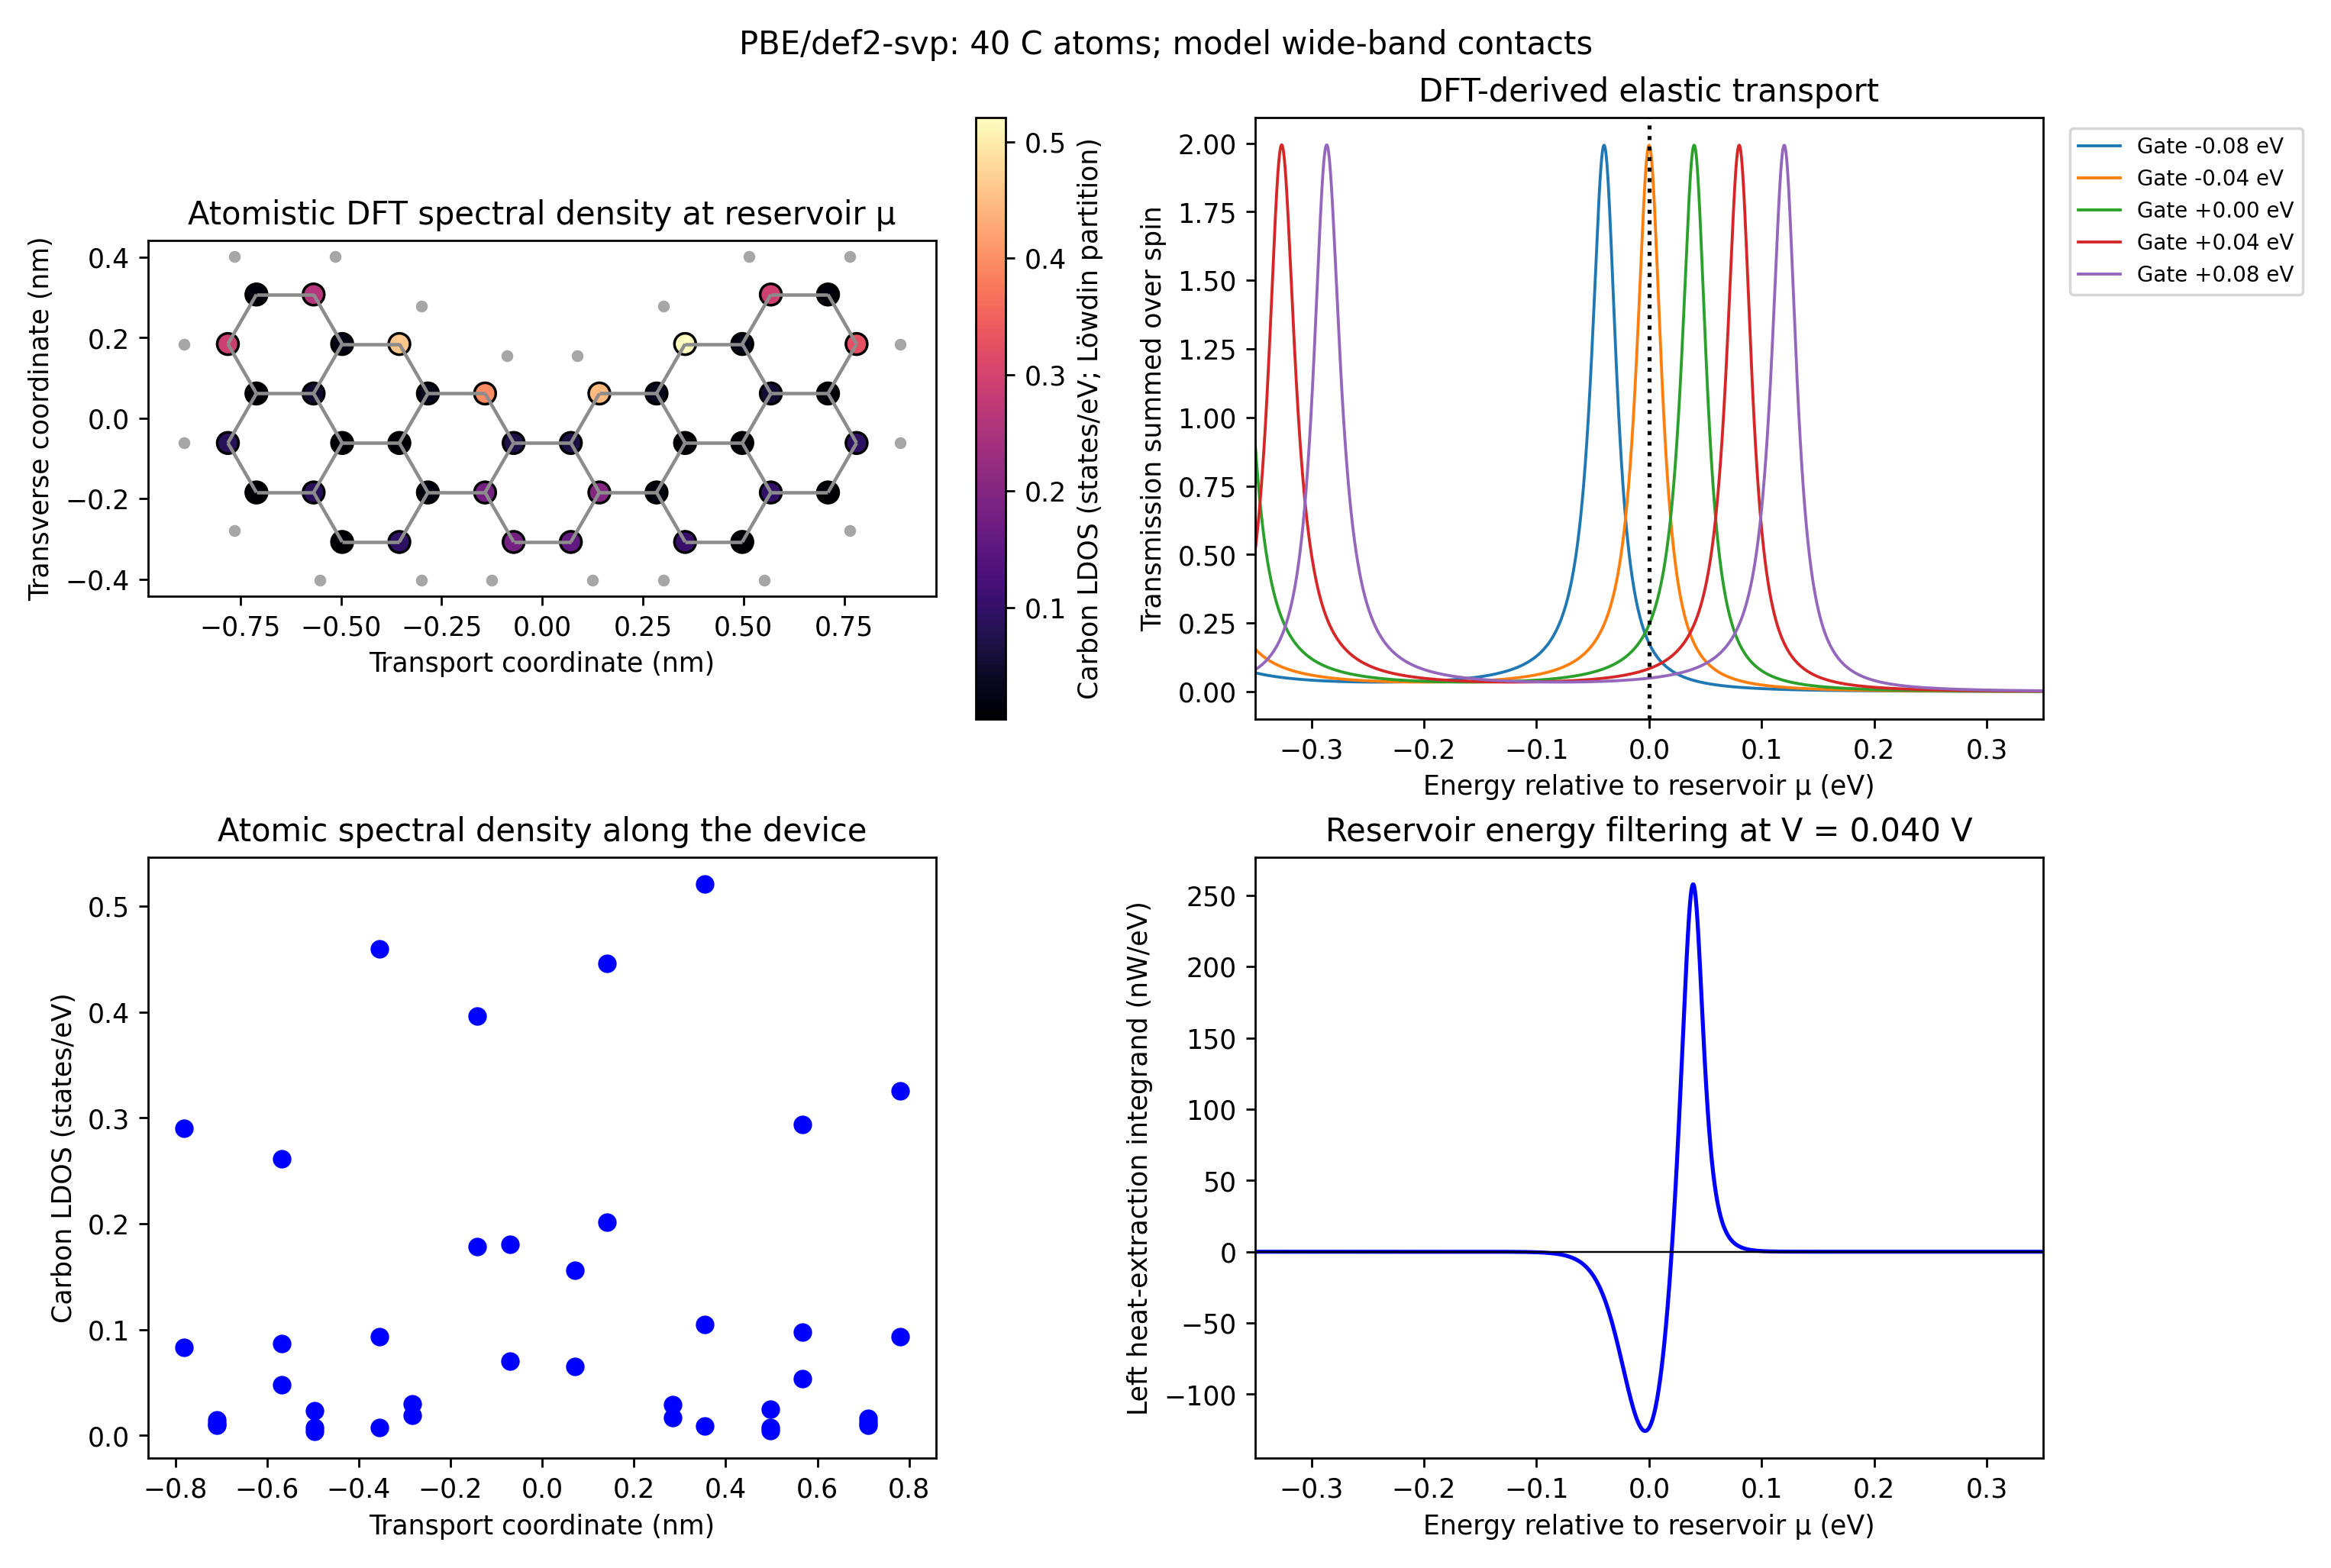

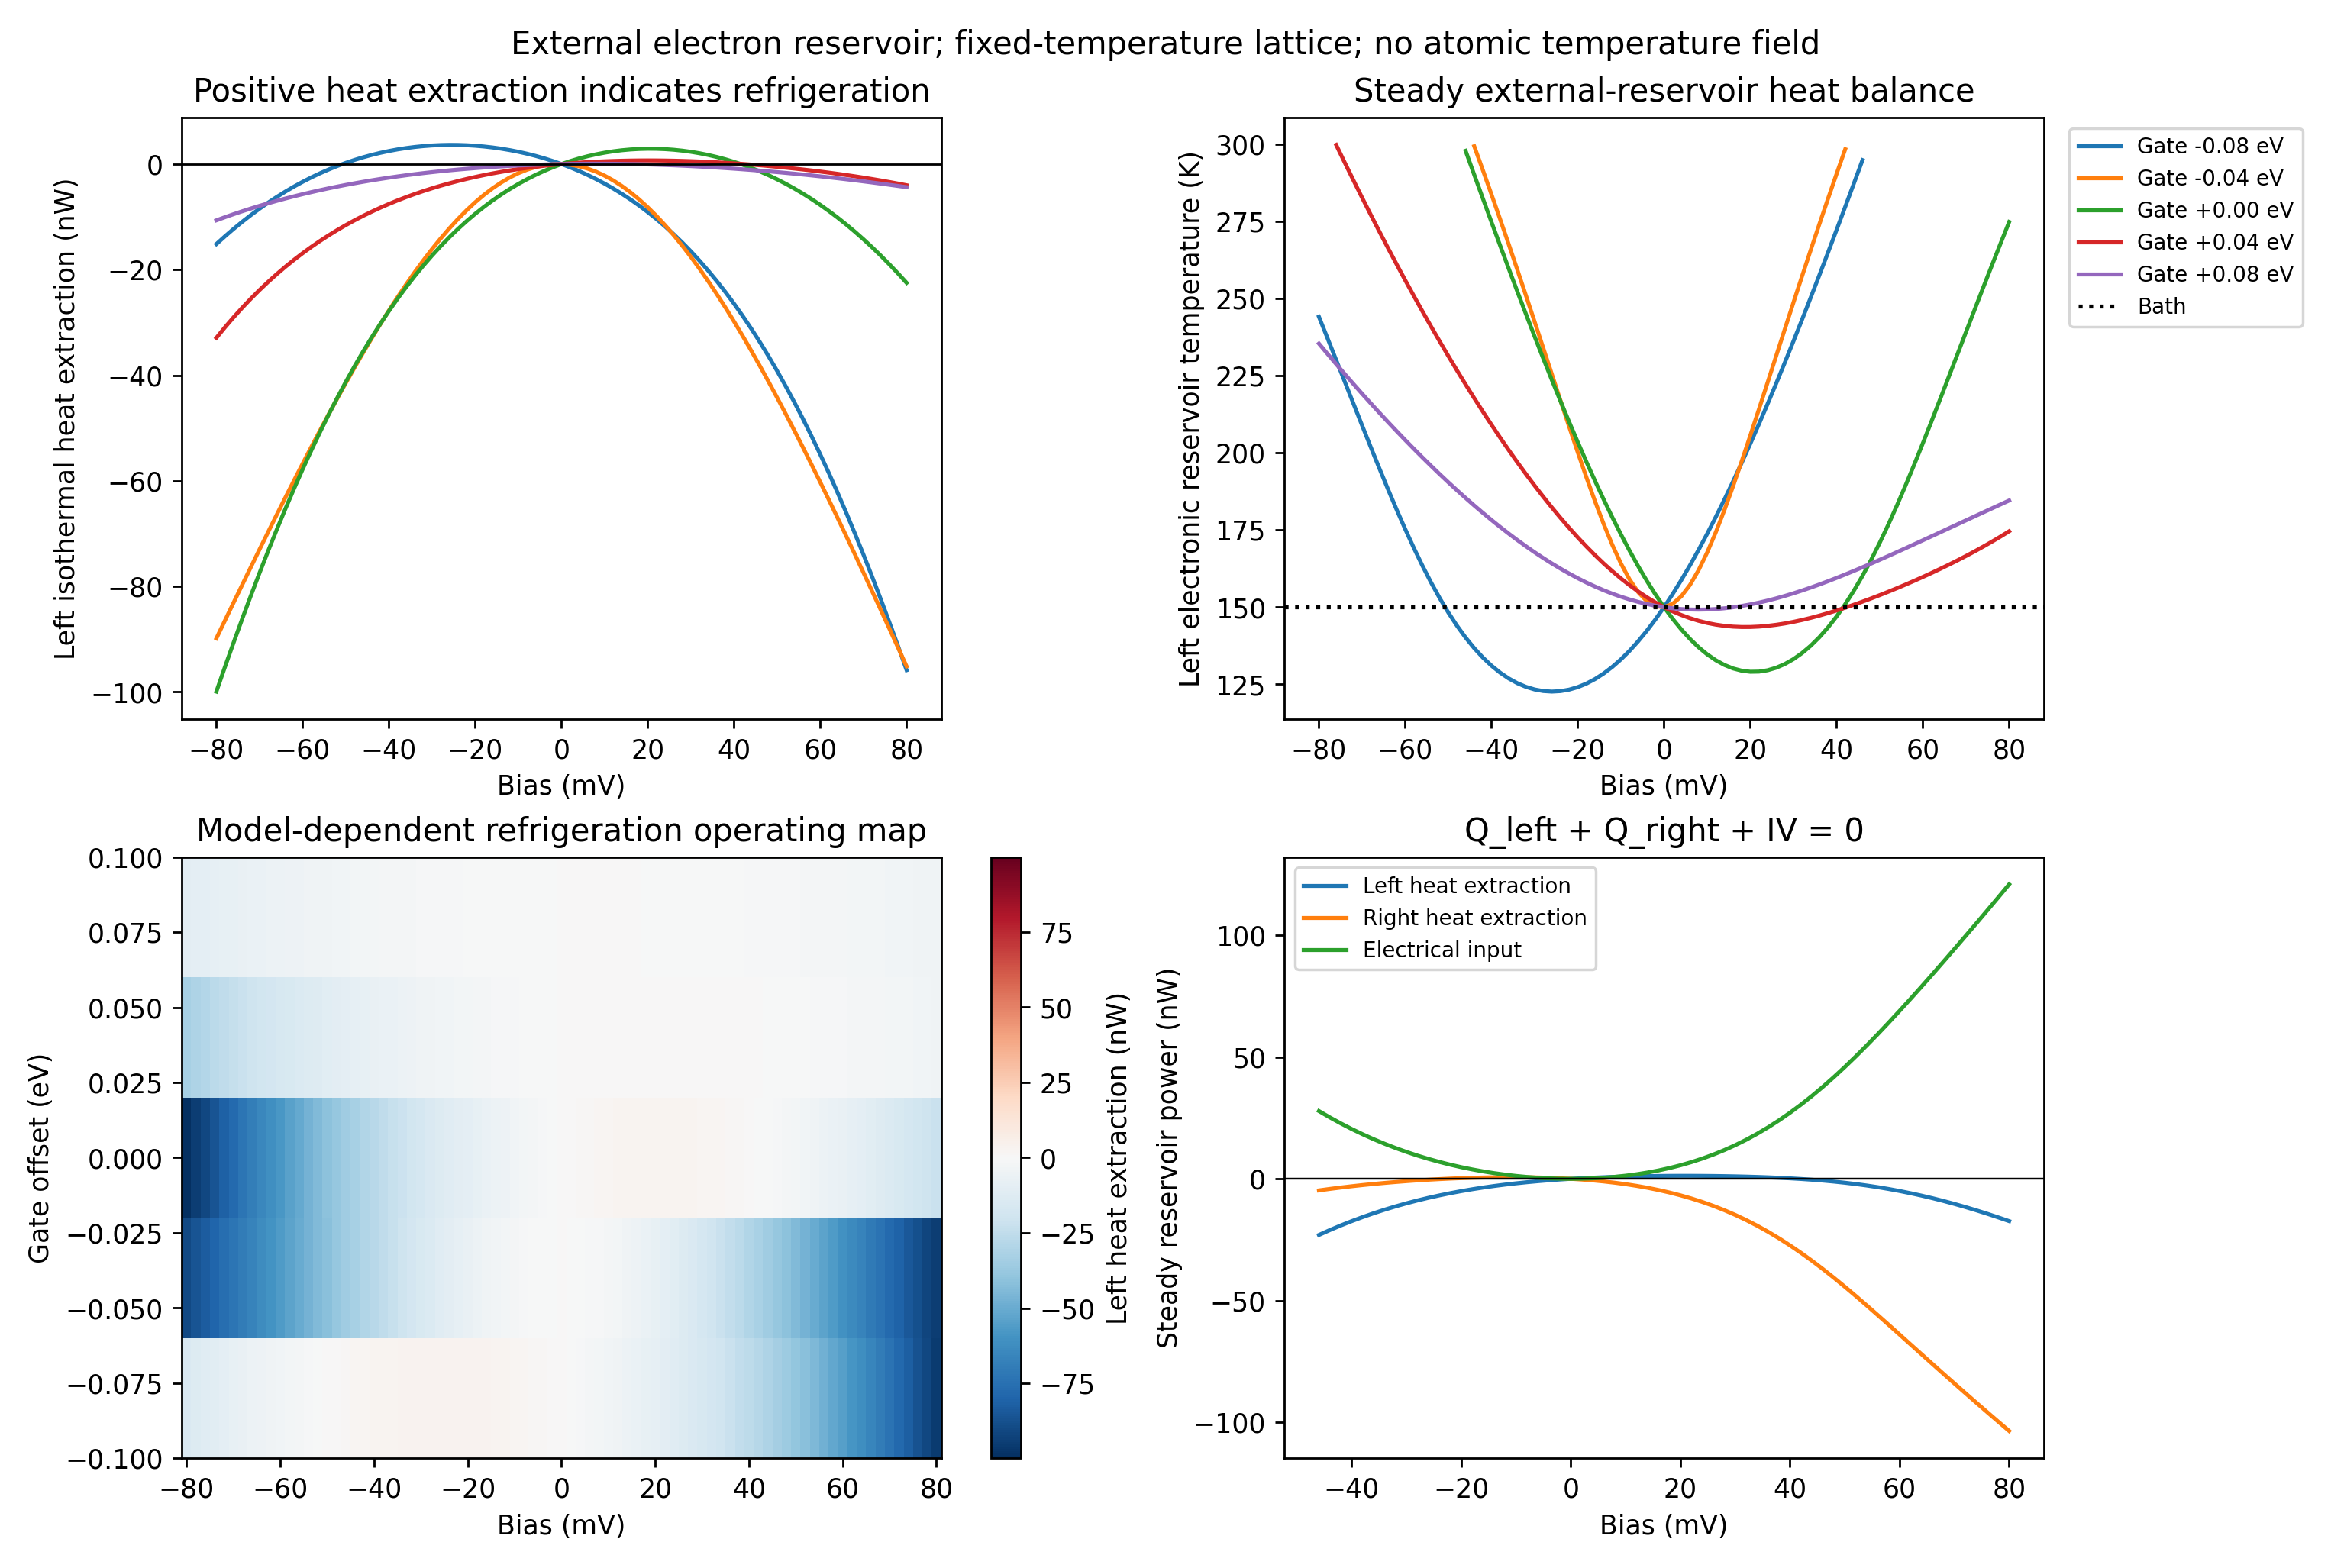

/content/electron_atomistic_ab_initio_results/electron_atomistic_ab_initio_results.zip

In [10]:
"""Calculate atomistic graphene DFT and reservoir refrigeration on a GPU.

The initialized host driver selects a compatible CUDA runtime. CUDA kernels,
the eigensolver, and a small GPU DFT calculation are checked before the device
calculation. Edit CONFIG below; --quick selects a smaller atomistic device.
Generalized SCF and final eigenproblems use CuPy Cholesky reduction and eigh;
startup and final checks verify eigenpair residuals and AO-metric normalization.
--validate-only checks geometry, Green functions, units, and conservation
without requiring a GPU. --use-current-env bypasses automatic installation.

Physical calculation
--------------------
GPU4PySCF calculates all-electron, density-fitted Kohn-Sham DFT for a
hydrogen-passivated graphene nanoconstriction. Carbon and hydrogen nuclear
coordinates, Gaussian atomic basis functions, Coulomb interactions, and the
chosen exchange-correlation functional determine the electronic Hamiltonian.
No fitted graphene hopping, Fermi velocity, collision time, or continuum
collision operator determines that Hamiltonian. The default uses PBE/def2-SVP
and a restricted singlet at prescribed nuclear coordinates. Optional GPU DFT
geometry optimization and collinear unrestricted spin calculations are exposed.

CuPy diagonalizes the full orthogonalized Hamiltonian and evaluates elastic
Landauer charge and heat transport through its resolvent. A contact-space Dyson
solve retains every DFT orbital, without constructing a quartic tensor or
inverting the full atomic-orbital matrix separately at every energy. Spin
degeneracy is counted once; valley structure is already in the atomistic DFT.
Positive Q_left means heat extraction from the left electronic reservoir.
The steady cold-reservoir temperature solves:
    Q_left(V, T_left, T_bath)
        = load + Sigma*A*(T_bath**p - T_left**p).
The right electronic reservoir and both reservoir lattices remain at T_bath.

Scope and approximations
------------------------
The DFT electronic structure is first principles within the stated functional,
basis, density-fitting, spin, and geometry approximations. Wide-band contact
self-energies, screened gate offsets in the orthogonal AO basis, the reservoir
chemical-potential alignment, and the electron-phonon heat leak are supplied
model inputs, not first-principles electrode or phonon calculations. Gates and
bias do not trigger a nonequilibrium DFT/Poisson update; transport uses the
frozen
ground-state Hamiltonian. The default atomic coordinates are not relaxed, and a
restricted singlet does not establish the magnetic ground state of zigzag
edges.
Kohn-Sham level positions are not quasiparticle excitation energies.

This nanometre-scale calculation predicts coherent energy-filtering
refrigeration of an external electronic reservoir. It does not predict an
atomic temperature field, lattice refrigeration, or the viscous refrigeration
of a micrometre-scale hydrodynamic device. Mean-field electron interactions
in DFT do not supply inelastic electron-electron or electron-phonon collision
rates. A zero or negative cooling power is retained as a physical result.
Numerical transport refinement is not evidence of DFT basis, functional,
contact, or geometry convergence.

Outputs
-------
Atomic XYZ coordinates, DFT AO overlap/Fock/density matrices, orbital energies,
spin-resolved transmission, atom-resolved spectral density, transport CSV
tables, reservoir heat/temperature plots, checks, and a JSON report are archived.
Production DFT and transport require CUDA. Wall time depends on SCF
convergence, basis size, requested refinement, and available CPU/GPU memory.

References
----------
https://pyscf.org/user/gpu.html
https://github.com/pyscf/gpu4pyscf
https://arxiv.org/abs/2404.09452
https://arxiv.org/abs/1307.8336
https://doi.org/10.1103/PhysRevB.80.115427
https://docs.cupy.dev/en/v13.4.1/install.html
https://docs.nvidia.com/deploy/cuda-compatibility/latest/
https://docs.astral.sh/uv/reference/cli/

"""

import argparse
import ast
import builtins
import ctypes.util
import hashlib
import importlib.metadata
import io
import json
import os
import platform
import re
import shutil
import subprocess
import sys
import tempfile
import threading
import time
import zipfile
from collections import deque
from dataclasses import asdict, dataclass, replace
from pathlib import Path

# -----------------------------------------------------------------------------
# Control knobs - atomistic geometry, DFT, contacts, and refrigeration
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class Config:
    """Store physical assumptions, numerical limits, and output controls."""

    # Hexagons share real C-C bonds; dimensions are atomic, not micrometres.
    hex_columns: int = 7
    lead_hex_rows: int = 2
    neck_hex_rows: int = 1
    neck_columns: int = 3
    cc_bond_angstrom: float = 1.42
    ch_bond_angstrom: float = 1.09
    max_atoms: int = 140

    # All-electron DFT; charge is an integer electron deficit, spin = Nalpha-
    # Nbeta.
    basis: str = "def2-svp"
    auxiliary_basis: str = "def2-universal-jkfit"
    xc: str = "pbe"
    charge: int = 0
    spin: int = 0
    unrestricted: bool = False
    dft_grid_level: int = 3
    scf_tolerance_hartree: float = 1.0e-8
    scf_gradient_tolerance: float = 1.0e-6
    scf_max_cycles: int = 160
    dft_cpu_memory_mb: int = 6000
    max_atomic_orbitals: int = 2400
    optimize_geometry: bool = False
    geometry_max_steps: int = 60
    dft_cache: bool = True
    cpu_threads: int = 2

    # Electrode coupling to carbon p_z Löwdin AOs is an explicit wide-band
    # model.
    contact_depth_angstrom: float = 2.2
    gamma_left_ev: float = 0.080
    gamma_right_ev: float = 0.080
    reference_level: str = "lumo"  # "lumo", "homo", or "midgap".
    chemical_potential_offset_ev: float = -0.040
    gate_offsets_ev: tuple[float, ...] = (-0.080, -0.040, 0.0, 0.040, 0.080)
    gate_contrast_ev: float = 0.040
    gate_transition_angstrom: float = 3.0
    bias_max_v: float = 0.080
    bias_points: int = 81
    bath_temperature_k: float = 150.0
    green_eta_ev: float = 1.0e-9  # Numerical retarded regulator, not relaxation.
    overlap_eigenvalue_floor: float = 1.0e-8

    # Energy quadrature resolves reservoir windows and coupled molecular poles.
    energy_points: int = 1401
    energy_max_refinements: int = 4
    thermal_window_kbt: float = 22.0
    resonance_window_ev: float = 0.35
    resonance_nodes: int = 41
    integration_rtol: float = 0.015
    current_atol_a: float = 1.0e-13
    heat_atol_w: float = 1.0e-15
    energy_batch_size: int = 96
    gpu_memory_fraction: float = 0.45
    enforce_quadrature_convergence: bool = True

    # External reservoir heat balance; these are calibrated model inputs.
    cold_reservoir_area_um2: float = 0.50
    phonon_sigma_w_m2_kp: float = 0.002
    phonon_power: int = 3
    external_load_nw: float = 0.0
    minimum_reservoir_temperature_k: float = 5.0
    maximum_reservoir_temperature_k: float = 300.0
    temperature_root_samples: int = 41
    thermal_root_tolerance_k: float = 1.0e-6

    dpi: int = 250
    display_figures: bool = True
    output_directory: str = "electron_atomistic_ab_initio_results"


CONFIG = Config()


# -----------------------------------------------------------------------------
# Control knobs - private dependency setup and CUDA compatibility
# -----------------------------------------------------------------------------

RUNTIME_CACHE = Path(
    os.environ.get(
        "ATOMISTIC_GPU_RUNTIME_DIR",
        str(
            Path("/content/.atomistic_gpu_runtime")
            if Path("/content").exists()
            else Path(tempfile.gettempdir()) / "atomistic_gpu_runtime"
        ),
    )
)
AUTO_PACKAGES = (
    "numpy==2.2.6",
    "scipy==1.15.3",
    "matplotlib==3.10.3",
    "pyscf==2.14.0",
    "gpu4pyscf-cuda12x==1.8.1",
    "gpu4pyscf-libxc-cuda12x==0.8.1",
    "cupy-cuda12x==13.4.1",
    "cutensor-cu12==2.2.0",
    "geometric==1.1.0",
    "h5py>=3.11,<4",
    "psutil>=6,<8",
    "pillow>=10,<13",
)
BOOTSTRAP_PYTHON = "3.11"
BOOTSTRAP_REVISION = 3
# CUDA-13 drivers support this CUDA-12 package family by backward compatibility.
# Keep the CuPy/cuTENSOR pair above together; do not mix CUDA-12/13 wheels.
CUDA_TOOLKIT_PROFILES = (
    (13000, "12.8.2"),
    (12080, "12.8.2"),
    (12060, "12.6.3"),
    (12040, "12.4.1"),
    (12020, "12.2.2"),
    (12000, "12.0.1"),
)
CUDA_TOOLKIT_EXTRAS = (
    "cudart,nvrtc,cccl,cublas,cusolver,cusparse,cufft,curand,nvjitlink"
)
NVIDIA_DRIVER_DIRECTORIES = (
    "/usr/lib64-nvidia",
    "/usr/local/nvidia/lib64",
    "/usr/local/nvidia/lib",
    "/usr/lib/x86_64-linux-gnu/nvidia/current",
    "/usr/lib/x86_64-linux-gnu",
    "/usr/lib64",
    "/usr/lib/wsl/lib",
)
# Preload one private solver stack so ctypes and CuPy resolve the same libraries.
CUDA_PRELOAD_COMPONENTS = (
    ("cuda_runtime", "libcudart.so.12"),
    ("cuda_nvrtc", "libnvrtc.so.12"),
    ("nvjitlink", "libnvJitLink.so.12"),
    ("cublas", "libcublasLt.so.12"),
    ("cublas", "libcublas.so.12"),
    ("cusparse", "libcusparse.so.12"),
    ("cusolver", "libcusolver.so.11"),
    ("cufft", "libcufft.so.11"),
    ("curand", "libcurand.so.10"),
)


def gpu_hermitian_matrix(matrix, name="matrix"):
    """Validate a finite Hermitian matrix or batch and remove roundoff skew."""
    import cupy as cp

    array = cp.asarray(matrix)
    if array.ndim not in (2, 3) or array.shape[-2] != array.shape[-1]:
        raise ValueError(f"{name} must contain square matrices.")
    if array.shape[-1] < 1:
        raise ValueError(f"{name} must contain at least one orbital.")
    dtype = cp.complex128 if cp.iscomplexobj(array) else cp.float64
    array = array.astype(dtype, copy=False)
    if not bool(cp.all(cp.isfinite(array))):
        raise ValueError(f"{name} contains nonfinite entries.")
    adjoint = array.conj().swapaxes(-1, -2)
    scale = max(1.0, float(cp.max(cp.abs(array))))
    skew = float(cp.max(cp.abs(array - adjoint))) / scale
    if skew > 1.0e-10:
        raise ValueError(f"{name} is not Hermitian: relative skew {skew:.3e}.")
    return cp.ascontiguousarray(0.5 * (array + adjoint))


def gpu_generalized_eigh(h, s=None, x=None, overlap_floor=1.0e-8, check=False):
    """Solve H C = S C E on CUDA using Cholesky reduction and CuPy eigh.

    Cholesky factors satisfy S = L L^H. Triangular solves construct
    L^-1 H L^-H and restore C = L^-H U without forming a matrix inverse.
    A supplied orthogonalizer x retains GPU4PySCF's SCF projection behavior.
    No CPU eigensolver, discarded overlap mode, or diagonal jitter is used.
    """
    import cupy as cp
    from cupyx import errstate
    from cupyx.scipy.linalg import solve_triangular

    h = gpu_hermitian_matrix(h, "Fock matrix")
    if h.ndim != 2:
        raise ValueError("Each generalized eigenproblem requires a 2D Fock matrix.")
    if overlap_floor <= 0:
        raise ValueError("The overlap eigenvalue floor must be positive.")
    metric = None
    with errstate(linalg="raise"):
        if x is None:
            metric = gpu_hermitian_matrix(s, "AO overlap matrix")
            if metric.shape != h.shape:
                raise ValueError("Fock and AO overlap matrices must match.")
            dtype = cp.result_type(h.dtype, metric.dtype)
            h = h.astype(dtype, copy=False)
            metric = metric.astype(dtype, copy=False)
            minimum = float(cp.linalg.eigvalsh(metric)[0])
            if minimum < overlap_floor:
                raise RuntimeError(
                    f"Minimum overlap eigenvalue {minimum:.3e} is below "
                    f"{overlap_floor:.3e}; choose a less diffuse basis."
                )
            factor = cp.linalg.cholesky(metric)
            left = solve_triangular(factor, h, lower=True)
            reduced = solve_triangular(factor, left.conj().T, lower=True).conj().T
        else:
            x = cp.asarray(x)
            if x.ndim != 2 or x.shape[0] != h.shape[0] or x.shape[1] < 1:
                raise ValueError("The AO orthogonalizer has an invalid shape.")
            if not bool(cp.all(cp.isfinite(x))):
                raise ValueError("The AO orthogonalizer contains nonfinite entries.")
            reduced = x.conj().T @ h @ x
            if check:
                metric = gpu_hermitian_matrix(s, "AO overlap matrix")
                if metric.shape != h.shape:
                    raise ValueError("Fock and AO overlap matrices must match.")
        reduced = gpu_hermitian_matrix(reduced, "Orthogonal Fock matrix")
        levels, vectors = cp.linalg.eigh(reduced)
        if x is None:
            orbitals = solve_triangular(factor.conj().T, vectors, lower=False)
        else:
            orbitals = x @ vectors
        if not bool(cp.all(cp.isfinite(levels))):
            raise RuntimeError("The GPU eigensolver returned nonfinite energies.")
        if not bool(cp.all(cp.isfinite(orbitals))):
            raise RuntimeError("The GPU eigensolver returned nonfinite orbitals.")
        if check:
            residual = h @ orbitals - (metric @ orbitals) * levels[None, :]
            # A rectangular x defines a projected, rather than full, eigenproblem.
            if x is not None and x.shape[1] < x.shape[0]:
                residual = x.conj().T @ residual
            scale = max(
                1.0,
                float(cp.linalg.norm(h) * cp.linalg.norm(orbitals)),
                float(
                    cp.linalg.norm(metric)
                    * cp.linalg.norm(orbitals)
                    * cp.max(cp.abs(levels))
                ),
            )
            residual_error = float(cp.linalg.norm(residual)) / scale
            identity = cp.eye(orbitals.shape[1], dtype=orbitals.dtype)
            metric_error = float(
                cp.max(cp.abs(orbitals.conj().T @ metric @ orbitals - identity))
            )
            if residual_error > 1.0e-8 or metric_error > 1.0e-7:
                raise RuntimeError(
                    "GPU generalized eigensystem verification failed: "
                    f"relative residual {residual_error:.3e}; "
                    f"overlap metric error {metric_error:.3e}."
                )
    return levels, orbitals


def gpu_scf_eigh(self, h, s, overwrite=False, x=None):
    """Provide the single-spin GPU4PySCF eigensolver calling convention."""
    return gpu_generalized_eigh(h, s, x=x, overlap_floor=self._atomistic_overlap_floor)


def gpu_scf_eig(self, h, s, overwrite=False, x=None):
    """Handle restricted and unrestricted Fock matrices with the CUDA solver."""
    import cupy as cp

    h = cp.asarray(h)
    if h.ndim == 2:
        return gpu_scf_eigh(self, h, s, overwrite=overwrite, x=x)
    if h.ndim != 3 or h.shape[0] != 2:
        raise ValueError("Expected one Fock matrix or two spin Fock matrices.")
    answers = []
    for spin in range(2):
        spin_x = x[spin] if x is not None and cp.asarray(x).ndim == 3 else x
        answers.append(gpu_scf_eigh(self, h[spin], s, x=spin_x))
    return (
        cp.stack([answer[0] for answer in answers]),
        cp.stack([answer[1] for answer in answers]),
    )


def bind_gpu_eigensolver(method, overlap_floor=1.0e-8):
    """Bind the CuPy generalized solver to one SCF object before its kernel."""
    from types import MethodType

    method._atomistic_overlap_floor = overlap_floor
    method.eig = MethodType(gpu_scf_eig, method)
    method._eigh = MethodType(gpu_scf_eigh, method)
    method._keys = set(method._keys) | {"eig", "_eigh", "_atomistic_overlap_floor"}
    return method


def gpu_eigensolver_source(source):
    """Extract the same solver implementation for the fresh-process GPU probe."""
    text = source.read_text(encoding="utf-8")
    wanted = {
        "gpu_hermitian_matrix",
        "gpu_generalized_eigh",
        "gpu_scf_eigh",
        "gpu_scf_eig",
        "bind_gpu_eigensolver",
    }
    functions = [
        node
        for node in ast.parse(text).body
        if isinstance(node, ast.FunctionDef) and node.name in wanted
    ]
    if {node.name for node in functions} != wanted:
        raise RuntimeError("The GPU probe solver source is incomplete.")
    return "\n\n".join(ast.get_source_segment(text, node) for node in functions)


DRIVER_PROBE_CODE = """
import ctypes
import json
import sys

result = {"library": sys.argv[1]}
try:
    driver = ctypes.CDLL(sys.argv[1], mode=ctypes.RTLD_GLOBAL)
    driver.cuInit.argtypes = [ctypes.c_uint]
    driver.cuInit.restype = ctypes.c_int
    driver.cuDriverGetVersion.argtypes = [ctypes.POINTER(ctypes.c_int)]
    driver.cuDriverGetVersion.restype = ctypes.c_int
    driver.cuDeviceGetCount.argtypes = [ctypes.POINTER(ctypes.c_int)]
    driver.cuDeviceGetCount.restype = ctypes.c_int
    version = ctypes.c_int()
    count = ctypes.c_int()
    result["version_status"] = driver.cuDriverGetVersion(ctypes.byref(version))
    result["driver_api_version"] = version.value
    result["init_status"] = driver.cuInit(0)
    if result["init_status"] == 0:
        result["count_status"] = driver.cuDeviceGetCount(ctypes.byref(count))
        result["device_count"] = count.value
    else:
        result["device_count"] = 0
except (OSError, AttributeError) as error:
    result["error"] = str(error)
print(json.dumps(result))
"""
GPU_PROBE_CODE = """
import atexit
import ctypes
import json
import os
from pathlib import Path

def report_cuda_libraries():
    paths = []
    try:
        for line in Path("/proc/self/maps").read_text().splitlines():
            fields = line.split()
            if len(fields) < 6:
                continue
            path = fields[-1]
            name = Path(path).name
            if name.startswith(("libcuda.", "libcudart.", "libcusolver.",
                                "libcublas.", "libnvJitLink.", "libnvrtc.")):
                paths.append(path)
        print("Loaded CUDA libraries: " + json.dumps(sorted(set(paths))),
              flush=True)
    except OSError:
        pass

atexit.register(report_cuda_libraries)

ctypes.CDLL(os.environ["ATOMISTIC_GPU_DRIVER"], mode=ctypes.RTLD_GLOBAL)
import cupy as cp
from cupyx import errstate

count = cp.cuda.runtime.getDeviceCount()
if count < 1:
    raise RuntimeError("No NVIDIA GPU is visible to the private interpreter.")
cp.cuda.Device(0).use()
driver_version = cp.cuda.runtime.driverGetVersion()
runtime_version = cp.cuda.runtime.runtimeGetVersion()
print(f"CUDA driver API: {driver_version}; runtime: {runtime_version}",
      flush=True)
if runtime_version > driver_version:
    raise RuntimeError("Installed CUDA runtime exceeds the driver API.")
with errstate(linalg="raise"):
    values = cp.arange(16, dtype=cp.float64)
    if float(cp.sum(values * values)) != 1240.0:
        raise RuntimeError("CUDA kernel compilation/execution failed.")
    standard = cp.asarray([[2.0, 0.3], [0.3, 3.0]], dtype=cp.float64)
    eigenvalues, eigenvectors = cp.linalg.eigh(standard)
    if not bool(cp.allclose(standard @ eigenvectors,
                            eigenvectors * eigenvalues[None, :])):
        raise RuntimeError("CUDA eigensolver validation failed.")
    matrices = cp.asarray(
        [[[2, 1j], [-1j, 3]], [[3, 0.5j], [-0.5j, 2]]],
        dtype=cp.complex128,
    )
    right_hand_sides = cp.ones((2, 2, 2), dtype=cp.complex128)
    solutions = cp.linalg.solve(matrices, right_hand_sides)
    if not bool(cp.allclose(matrices @ solutions, right_hand_sides)):
        raise RuntimeError("CUDA batched complex solve validation failed.")
    metric = cp.asarray([[1.0, 0.2], [0.2, 1.4]], dtype=cp.float64)
    for hamiltonian in (standard, matrices[0]):
        levels, orbitals = gpu_generalized_eigh(
            hamiltonian, metric, check=True
        )
cp.cuda.Stream.null.synchronize()
print("CUDA standard and generalized eigensolvers verified.", flush=True)

import numpy
import scipy
import matplotlib
from pyscf import gto, lib
from gpu4pyscf.dft import rks

lib.num_threads(int(os.environ.get("OMP_NUM_THREADS", "2")))
molecule = gto.M(atom="H 0 0 0; H 0 0 0.74", basis="sto-3g", verbose=0)
method = rks.RKS(molecule).density_fit(auxbasis="def2-universal-jkfit")
bind_gpu_eigensolver(method)
method.xc = "pbe"
method.grids.level = 0
method.conv_tol = 1.0e-7
method.max_cycle = 60
energy = method.kernel()
if not method.converged or not numpy.isfinite(float(energy)):
    raise RuntimeError("The GPU4PySCF startup calculation did not converge.")
if not isinstance(method.mo_coeff, cp.ndarray):
    raise RuntimeError("The DFT startup did not retain GPU orbitals.")
print("H2 GPU DFT SCF converged; verifying the final eigensystem.", flush=True)
with errstate(linalg="raise"):
    fock = gpu_hermitian_matrix(method.get_fock(), "Probe Fock matrix")
    overlap = gpu_hermitian_matrix(method.get_ovlp(), "Probe overlap matrix")
    density = cp.asarray(method.make_rdm1())
    levels, orbitals = gpu_generalized_eigh(fock, overlap, check=True)
    residual = fock @ orbitals - (overlap @ orbitals) * levels[None]
    if float(cp.max(cp.abs(residual))) > 1.0e-6:
        raise RuntimeError("The final GPU DFT eigensystem check failed.")
    electron_count = cp.einsum("ij,ji->", density, overlap).real
    if abs(float(electron_count) - molecule.nelectron) > 1.0e-6:
        raise RuntimeError("The GPU DFT density check failed.")
    # Test the unrestricted eigensolver calling convention without changing H2.
    spin_levels, spin_orbitals = method.eig(cp.stack((fock, fock)), overlap)
    if not bool(cp.allclose(spin_levels, levels[None, :])):
        raise RuntimeError("The GPU spin eigensolver validation failed.")
cp.cuda.Stream.null.synchronize()
print("CUDA kernels, complex solves, and GPU DFT startup verified.",
      flush=True)
"""
_SOURCE_NAME = sys._getframe().f_code.co_filename
_FROM_FILE = Path(_SOURCE_NAME).is_file()
_ARGUMENTS = sys.argv[1:] if _FROM_FILE else []


def run_command(command, environment, label, quiet=False):
    """Stream a subprocess, emit progress, and preserve failure diagnostics."""
    started = time.monotonic()
    recent = deque(maxlen=40)
    process = subprocess.Popen(
        command,
        env=environment,
        stdin=subprocess.DEVNULL,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    def relay():
        """Drain child output without blocking periodic progress messages."""
        for line in process.stdout:
            recent.append(line.rstrip())
            if not quiet:
                print(line, end="", flush=True)

    thread = threading.Thread(target=relay, daemon=True)
    thread.start()
    try:
        while True:
            try:
                code = process.wait(timeout=30)
                break
            except subprocess.TimeoutExpired:
                print(f"{label}: {time.monotonic() - started:.0f} s", flush=True)
    except BaseException:
        process.terminate()
        try:
            process.wait(timeout=5)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait()
        raise
    finally:
        thread.join(timeout=5)
        process.stdout.close()
    if code:
        raise RuntimeError(f"{label} failed ({code}).\n" + "\n".join(recent))


def script_source(cache):
    """Resolve a file or capture the complete current notebook cell."""
    if _FROM_FILE:
        return Path(_SOURCE_NAME).resolve()
    getter = globals().get("get_ipython") or getattr(builtins, "get_ipython", None)
    if getter is None:
        raise RuntimeError("Execute the file or paste its complete code into Colab.")
    history = getter().history_manager.input_hist_raw
    source = history[-1] if history else ""
    names = {
        node.name
        for node in ast.parse(source).body
        if isinstance(node, (ast.FunctionDef, ast.ClassDef))
    }
    if not {"Config", "prepare_environment", "main"}.issubset(names):
        raise RuntimeError("Paste the complete script into one Python cell.")
    path = cache / "electron_atomistic_ab_initio_gpu.py"
    path.write_text(source, encoding="utf-8")
    return path


def clean_process_environment(environment=None):
    """Remove Python, installer, and CUDA overrides from previous processes."""
    result = dict(os.environ if environment is None else environment)
    for name in (
        "PYTHONPATH",
        "PYTHONHOME",
        "CUDA_PATH",
        "CUDA_HOME",
        "LD_LIBRARY_PATH",
        "LD_PRELOAD",
        "VIRTUAL_ENV",
        "CONDA_PREFIX",
        "CONDA_DEFAULT_ENV",
        "ATOMISTIC_GPU_CHILD",
        "ATOMISTIC_GPU_PREFIX",
        "ATOMISTIC_GPU_BOOTSTRAP_REVISION",
        "ATOMISTIC_GPU_DRIVER",
        "ATOMISTIC_GPU_TOOLKIT",
        "ELECTRON_HYDRO_RUNTIME_CHILD",
        "UV_SYSTEM_PYTHON",
        "UV_PYTHON",
        "UV_MANAGED_PYTHON",
        "UV_NO_MANAGED_PYTHON",
        "UV_PYTHON_DOWNLOADS",
        "UV_PYTHON_PREFERENCE",
        "UV_PROJECT_ENVIRONMENT",
        "UV_CONSTRAINT",
        "UV_OVERRIDE",
        "UV_CONFIG_FILE",
        "UV_NATIVE_TLS",
    ):
        result.pop(name, None)
    result["PYTHONNOUSERSITE"] = "1"
    return result


def driver_library_candidates(environment=None):
    """Find actual host driver files while excluding toolkit stub libraries."""
    environment = os.environ if environment is None else environment
    directories = [
        *NVIDIA_DRIVER_DIRECTORIES,
        *environment.get("LD_LIBRARY_PATH", "").split(os.pathsep),
    ]
    candidates = []
    for directory in directories:
        if not directory or "stubs" in Path(directory).parts:
            continue
        path = Path(directory) / "libcuda.so.1"
        if path.is_file():
            resolved = path.resolve()
            if "stubs" not in resolved.parts:
                candidates.append(str(resolved))
    executable = shutil.which("ldconfig")
    if executable:
        try:
            completed = subprocess.run(
                [executable, "-p"],
                capture_output=True,
                text=True,
                timeout=10,
                env=clean_process_environment(environment),
            )
            for line in completed.stdout.splitlines():
                if "libcuda.so.1 " in line and "=>" in line:
                    path = Path(line.split("=>", 1)[1].strip())
                    if path.is_file() and "stubs" not in path.parts:
                        candidates.append(str(path.resolve()))
        except (OSError, subprocess.TimeoutExpired):
            pass
    # The loader may expose a host-mounted driver through its default cache.
    name = ctypes.util.find_library("cuda")
    if name:
        candidates.append(name)
    return list(dict.fromkeys(candidates))


def discover_cuda_driver():
    """Initialize the host driver in a fresh process before installation."""
    candidates = driver_library_candidates()
    failures = []
    for candidate in candidates:
        environment = clean_process_environment()
        directories = [
            *NVIDIA_DRIVER_DIRECTORIES,
            *os.environ.get("LD_LIBRARY_PATH", "").split(os.pathsep),
        ]
        if Path(candidate).is_absolute():
            directories.insert(0, str(Path(candidate).parent))
        directories = [
            str(Path(path))
            for path in directories
            if path and "stubs" not in Path(path).parts and Path(path).is_dir()
        ]
        environment["LD_LIBRARY_PATH"] = os.pathsep.join(dict.fromkeys(directories))
        try:
            completed = subprocess.run(
                [sys.executable, "-c", DRIVER_PROBE_CODE, candidate],
                env=environment,
                capture_output=True,
                text=True,
                timeout=30,
            )
            probe = json.loads(completed.stdout.strip().splitlines()[-1])
        except (
            OSError,
            ValueError,
            IndexError,
            subprocess.TimeoutExpired,
        ) as error:
            failures.append(f"{candidate}: {error}")
            continue
        valid = (
            completed.returncode == 0
            and probe.get("init_status") == 0
            and probe.get("version_status") == 0
            and probe.get("count_status") == 0
            and probe.get("device_count", 0) > 0
        )
        if valid:
            if not Path(candidate).is_absolute():
                # Identify the file mapped by the successful loader probe.
                mapped_probe = (
                    DRIVER_PROBE_CODE + "\nfrom pathlib import Path\n"
                    "mapped_lines = Path('/proc/self/maps').read_text()\n"
                    "for line in mapped_lines.splitlines():\n"
                    "    parts = line.split()\n"
                    "    if len(parts) >= 6 and '/libcuda.so' in parts[-1]:\n"
                    "        print(parts[-1]); break\n"
                )
                mapped = subprocess.run(
                    [sys.executable, "-c", mapped_probe, candidate],
                    env=environment,
                    capture_output=True,
                    text=True,
                    timeout=30,
                )
                lines = mapped.stdout.strip().splitlines()
                if not lines or not Path(lines[-1]).is_absolute():
                    failures.append("The mapped NVIDIA driver file is unavailable.")
                    continue
                candidate = str(Path(lines[-1]).resolve())
            probe["library"] = candidate
            print(
                f"NVIDIA driver initialized: {probe['device_count']} GPU(s); "
                f"CUDA driver API {probe['driver_api_version']}.",
                flush=True,
            )
            return probe
        failures.append(f"{candidate}: {json.dumps(probe, sort_keys=True)}")
    details = "\n".join(failures) or "No host libcuda.so.1 was found."
    raise RuntimeError(
        "The host NVIDIA driver did not initialize in a clean process. "
        "In Colab, select an NVIDIA GPU hardware accelerator and reconnect "
        "the runtime. Python packages do not install the host GPU driver.\n" + details
    )


def select_cuda_toolkit(driver_api_version):
    """Select a CUDA runtime no newer than the initialized driver API."""
    for minimum, version in CUDA_TOOLKIT_PROFILES:
        if driver_api_version >= minimum:
            return version
    raise RuntimeError(
        f"CUDA driver API {driver_api_version} is too old for this CUDA-12 "
        "GPU4PySCF calculation. Use a current Colab NVIDIA GPU runtime."
    )


def runtime_packages(toolkit=None):
    """Return one compatible package manifest without competing CUDA wheels."""
    if toolkit is None:
        return AUTO_PACKAGES[:2]
    return (*AUTO_PACKAGES, f"cuda-toolkit[{CUDA_TOOLKIT_EXTRAS}]=={toolkit}")


def runtime_environment(prefix, driver=None):
    """Load the verified host driver and one coherent private CUDA library set."""
    environment = clean_process_environment()
    sites = sorted(prefix.glob("lib/python*/site-packages"))
    toolkit_libraries = []
    libraries = []
    for site in sites:
        toolkit_libraries.extend(
            str(path) for path in sorted(site.glob("nvidia/*/lib"))
        )
        toolkit_libraries.extend(str(path) for path in site.glob("cutensor/lib"))
        runtime = site / "nvidia/cuda_runtime"
        if (runtime / "include/cuda_runtime.h").exists():
            environment["CUDA_PATH"] = str(runtime)
    preloads = []
    if driver is not None:
        library = str(Path(driver["library"]).resolve())
        environment["ATOMISTIC_GPU_DRIVER"] = library
        preloads.append(library)
        libraries.append(str(Path(library).parent))
        for component, soname in CUDA_PRELOAD_COMPONENTS:
            matches = [site / "nvidia" / component / "lib" / soname for site in sites]
            matches = [path.resolve() for path in matches if path.is_file()]
            if len(matches) != 1:
                raise RuntimeError(
                    f"Expected one private {soname}; found {len(matches)}. "
                    "The CUDA dependency installation is incomplete."
                )
            preloads.append(str(matches[0]))
    # Host libcuda is fixed above. CUDA computation libraries come from the
    # selected toolkit as a set, rather than arbitrary host/wheel combinations.
    libraries.extend(toolkit_libraries)
    libraries.extend(path for path in NVIDIA_DRIVER_DIRECTORIES if Path(path).is_dir())
    for path in os.environ.get("LD_LIBRARY_PATH", "").split(os.pathsep):
        if path and "stubs" not in Path(path).parts:
            if (Path(path) / "libcuda.so.1").is_file():
                libraries.append(path)
    environment["LD_LIBRARY_PATH"] = os.pathsep.join(dict.fromkeys(libraries))
    if preloads:
        environment["LD_PRELOAD"] = os.pathsep.join(preloads)
    environment["PATH"] = os.pathsep.join(
        [str(prefix / "bin"), environment.get("PATH", "")]
    )
    environment["MPLBACKEND"] = "Agg"
    environment["OMP_NUM_THREADS"] = str(CONFIG.cpu_threads)
    environment["OPENBLAS_NUM_THREADS"] = str(CONFIG.cpu_threads)
    environment["CUPY_CACHE_DIR"] = str(RUNTIME_CACHE / "cupy_cache")
    return environment


def display_outputs():
    """Display saved in-memory renders and the result archive in Colab."""
    if "--validate-only" in _ARGUMENTS:
        return
    try:
        from IPython.display import FileLink, Image, display
    except ImportError:
        return
    output = Path(CONFIG.output_directory)
    if CONFIG.display_figures:
        for name in ("atomic_electronic_structure", "reservoir_refrigeration"):
            path = output / f"{name}.png"
            if path.exists():
                display(Image(data=path.read_bytes()))
    archive = output / "electron_atomistic_ab_initio_results.zip"
    if archive.exists():
        display(FileLink(str(archive)))


def prepare_environment():
    """Verify the host driver and install a compatible private GPU runtime."""
    if "--use-current-env" in _ARGUMENTS:
        return True
    if os.environ.get("ATOMISTIC_GPU_CHILD") == "1" and os.environ.get(
        "ATOMISTIC_GPU_BOOTSTRAP_REVISION"
    ) == str(BOOTSTRAP_REVISION):
        prefix_name = os.environ.get("ATOMISTIC_GPU_PREFIX", "")
        if not prefix_name or Path(sys.prefix).resolve() != Path(prefix_name):
            raise RuntimeError("The child interpreter has an unexpected prefix.")
        return True
    if "--help" in _ARGUMENTS or "-h" in _ARGUMENTS:
        print(__doc__)
        print(
            "Options: --quick --fresh-dft --validate-only --bootstrap-only "
            "--use-current-env"
        )
        return False
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("Automatic GPU setup targets Colab/Linux x86_64.")
    validation_only = "--validate-only" in _ARGUMENTS
    driver = None if validation_only else discover_cuda_driver()
    toolkit = (
        None if driver is None else select_cuda_toolkit(driver["driver_api_version"])
    )
    packages = runtime_packages(toolkit)
    profile = "validation" if toolkit is None else f"cuda_{toolkit}"
    flavor = f"python_{BOOTSTRAP_PYTHON}_{profile}_r{BOOTSTRAP_REVISION}"
    prefix = (RUNTIME_CACHE / flavor).resolve()
    python = prefix / "bin/python"
    RUNTIME_CACHE.mkdir(parents=True, exist_ok=True)
    source = script_source(RUNTIME_CACHE)
    specification = {
        "packages": packages,
        "python": BOOTSTRAP_PYTHON,
        "bootstrap_revision": BOOTSTRAP_REVISION,
    }
    fingerprint = hashlib.sha256(
        json.dumps(specification, sort_keys=True).encode()
    ).hexdigest()
    marker = RUNTIME_CACHE / f"verified_{flavor}.json"
    ready = False
    if marker.is_file() and python.is_file():
        try:
            ready = json.loads(marker.read_text()).get("fingerprint") == fingerprint
        except (OSError, ValueError):
            pass
    installer_environment = clean_process_environment()
    installer_environment["UV_PYTHON_DOWNLOADS"] = "automatic"
    installer_environment.setdefault("UV_SYSTEM_CERTS", "true")
    if not ready:
        print(
            f"Preparing private Python {BOOTSTRAP_PYTHON}; {profile} dependencies.",
            flush=True,
        )
        uv = shutil.which("uv")
        if uv:
            try:
                version = subprocess.run(
                    [uv, "--version"],
                    env=installer_environment,
                    capture_output=True,
                    text=True,
                    timeout=10,
                )
                matched = re.search(r"(\d+)\.(\d+)", version.stdout)
                if not matched or tuple(map(int, matched.groups())) < (0, 12):
                    uv = None
            except (OSError, subprocess.TimeoutExpired):
                uv = None
        if uv is None:
            bootstrap = RUNTIME_CACHE / "bootstrap"
            cached_uv = bootstrap / "bin/uv"
            run_command(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    "--quiet",
                    "--target",
                    str(bootstrap),
                    "uv>=0.12,<1",
                    "--upgrade",
                ],
                installer_environment,
                "Automatic installer setup",
                quiet=True,
            )
            uv = str(cached_uv)
        if not python.is_file():
            run_command(
                [
                    uv,
                    "--no-config",
                    "venv",
                    "--managed-python",
                    "--python",
                    BOOTSTRAP_PYTHON,
                    str(prefix),
                ],
                installer_environment,
                "Private Python environment",
            )
        run_command(
            [
                uv,
                "--no-config",
                "pip",
                "install",
                "--python",
                str(python),
                *packages,
            ],
            installer_environment,
            "Automatic package installation",
            quiet=True,
        )
    environment = runtime_environment(prefix, driver)
    if toolkit is not None:
        environment["ATOMISTIC_GPU_TOOLKIT"] = toolkit
    probe = (
        "import numpy,scipy; print('Validation dependencies verified')"
        if validation_only
        else gpu_eigensolver_source(source) + "\n\n" + GPU_PROBE_CODE
    )
    # Repeat the real GPU probe even when packages are cached, since Colab's
    # assigned host driver and GPU may change between notebook sessions.
    run_command(
        [str(python), "-c", probe],
        environment,
        "Validation setup" if validation_only else "CUDA/GPU DFT startup",
    )
    temporary = marker.with_suffix(".partial")
    temporary.write_text(
        json.dumps(
            {
                "fingerprint": fingerprint,
                **specification,
                "driver": driver,
                "toolkit": toolkit,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    temporary.replace(marker)
    if "--bootstrap-only" in _ARGUMENTS:
        return False
    environment["ATOMISTIC_GPU_CHILD"] = "1"
    environment["ATOMISTIC_GPU_PREFIX"] = str(prefix)
    environment["ATOMISTIC_GPU_BOOTSTRAP_REVISION"] = str(BOOTSTRAP_REVISION)
    run_command([str(python), str(source), *_ARGUMENTS], environment, "Calculation")
    display_outputs()
    return False


# Numerical imports are deferred so the parent notebook needs only stdlib.
_EXECUTE_NUMERICS = __name__ != "__main__" or prepare_environment()
if _EXECUTE_NUMERICS:
    import numpy as np
    from scipy import constants
    from scipy.optimize import brentq
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import connected_components

    E_CHARGE = constants.elementary_charge
    H_PLANCK = constants.h
    KB_EV = constants.Boltzmann / E_CHARGE
    HARTREE_EV = constants.physical_constants["Hartree energy in eV"][0]
    CURRENT_PREFACTOR = E_CHARGE**2 / H_PLANCK


# -----------------------------------------------------------------------------
# Geometry - explicit fused carbon hexagons and hydrogen termination
# -----------------------------------------------------------------------------


def validate_config(cfg):
    """Reject inconsistent geometry, thermal ranges, and numerical controls."""
    positive = (
        "cc_bond_angstrom",
        "ch_bond_angstrom",
        "contact_depth_angstrom",
        "gamma_left_ev",
        "gamma_right_ev",
        "gate_transition_angstrom",
        "bath_temperature_k",
        "green_eta_ev",
        "overlap_eigenvalue_floor",
        "integration_rtol",
        "cold_reservoir_area_um2",
        "thermal_window_kbt",
        "scf_tolerance_hartree",
        "scf_gradient_tolerance",
        "thermal_root_tolerance_k",
    )
    for name in positive:
        value = getattr(cfg, name)
        if not np.isfinite(value) or value <= 0:
            raise ValueError(f"{name} must be finite and positive.")
    integer_controls = (
        "hex_columns",
        "lead_hex_rows",
        "neck_hex_rows",
        "neck_columns",
        "max_atoms",
        "scf_max_cycles",
        "max_atomic_orbitals",
        "cpu_threads",
        "energy_points",
        "resonance_nodes",
        "energy_batch_size",
        "bias_points",
        "phonon_power",
        "temperature_root_samples",
        "geometry_max_steps",
    )
    for name in integer_controls:
        value = getattr(cfg, name)
        if isinstance(value, bool) or not isinstance(value, int) or value < 1:
            raise ValueError(f"{name} must be a positive integer.")
    if cfg.hex_columns % 2 != 1 or cfg.neck_columns % 2 != 1:
        raise ValueError("Hexagon columns and neck columns must be odd.")
    if not 1 <= cfg.neck_columns <= cfg.hex_columns:
        raise ValueError("Neck length exceeds the atomistic device.")
    if cfg.neck_hex_rows > cfg.lead_hex_rows:
        raise ValueError("The neck must not exceed the lead width.")
    if not cfg.gate_offsets_ev or not np.all(np.isfinite(cfg.gate_offsets_ev)):
        raise ValueError("Specify finite gate offsets.")
    if cfg.reference_level not in {"homo", "lumo", "midgap"}:
        raise ValueError("Unknown orbital reference level.")
    if cfg.energy_max_refinements < 1:
        raise ValueError("At least one independent energy-grid refinement is required.")
    if min(cfg.energy_points, cfg.bias_points, cfg.temperature_root_samples) < 5:
        raise ValueError(
            "Energy, bias, and thermal grids require at least five points."
        )
    if not 0 < cfg.gpu_memory_fraction < 0.85:
        raise ValueError("GPU memory fraction must lie between 0 and 0.85.")
    if not (
        0
        < cfg.minimum_reservoir_temperature_k
        < cfg.bath_temperature_k
        < cfg.maximum_reservoir_temperature_k
    ):
        raise ValueError("Thermal root range must bracket the bath temperature.")
    if min(cfg.phonon_sigma_w_m2_kp, cfg.external_load_nw, cfg.bias_max_v) < 0:
        raise ValueError(
            "Heat-leak coefficient, load, and bias range must be nonnegative."
        )
    if cfg.spin != 0 and not cfg.unrestricted:
        raise ValueError("Nonzero spin requires unrestricted=True.")


def build_geometry(cfg):
    """Build a connected nanoconstriction from fused graphene hexagons."""
    bond = cfg.cc_bond_angstrom
    vertices = {}
    half = cfg.hex_columns // 2
    for column in range(-half, half + 1):
        rows = (
            cfg.neck_hex_rows
            if abs(column) <= cfg.neck_columns // 2
            else cfg.lead_hex_rows
        )
        for row in range(rows):
            center = np.array(
                [
                    1.5 * bond * column,
                    np.sqrt(3) * bond * (row + 0.5 * (column % 2)),
                    0.0,
                ]
            )
            for angle in np.arange(6) * np.pi / 3:
                point = center + bond * np.array([np.cos(angle), np.sin(angle), 0.0])
                vertices[tuple(np.round(point, 7))] = point
    carbon = np.array(sorted(vertices.values(), key=lambda point: tuple(point)))
    carbon -= (carbon.max(axis=0) + carbon.min(axis=0)) / 2
    distances = np.linalg.norm(carbon[:, None] - carbon[None, :], axis=-1)
    adjacency = (distances > 0.5 * bond) & (distances < 1.1 * bond)
    count, _ = connected_components(csr_matrix(adjacency), directed=False)
    degrees = adjacency.sum(axis=1)
    if count != 1 or not np.all(np.isin(degrees, [2, 3])):
        raise ValueError(
            "Geometry is disconnected or has incorrect carbon coordination."
        )
    hydrogen = []
    for index in np.flatnonzero(degrees == 2):
        inward = (carbon[adjacency[index]] - carbon[index]).sum(axis=0)
        outward = -inward / np.linalg.norm(inward)
        hydrogen.append(carbon[index] + cfg.ch_bond_angstrom * outward)
    hydrogen = np.asarray(hydrogen).reshape(-1, 3)
    positions = np.concatenate([carbon, hydrogen])
    symbols = np.array(["C"] * len(carbon) + ["H"] * len(hydrogen))
    if len(positions) > cfg.max_atoms:
        raise ValueError(f"{len(positions)} atoms exceed max_atoms={cfg.max_atoms}.")
    all_distances = np.linalg.norm(positions[:, None] - positions[None, :], axis=-1)
    np.fill_diagonal(all_distances, np.inf)
    if all_distances.min() < 0.70:
        raise ValueError("Edge termination produces overlapping atoms.")
    electrons = int(6 * len(carbon) + len(hydrogen) - cfg.charge)
    if electrons <= 0 or abs(cfg.spin) > electrons or (electrons - cfg.spin) % 2:
        raise ValueError("Electron count, charge, and spin are inconsistent.")
    bonds = np.argwhere(np.triu(adjacency, k=1))
    return {
        "positions": positions,
        "symbols": symbols,
        "bonds": bonds,
        "carbon_count": len(carbon),
        "electron_count": electrons,
    }


def write_xyz(path, geometry):
    """Save atom coordinates in angstroms for independent reproduction."""
    lines = [
        str(len(geometry["symbols"])),
        "Hydrogen-passivated graphene; angstrom",
    ]
    for symbol, position in zip(
        geometry["symbols"], geometry["positions"], strict=True
    ):
        lines.append(
            f"{symbol} {position[0]:.10f} {position[1]:.10f} {position[2]:.10f}"
        )
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


# -----------------------------------------------------------------------------
# GPU electronic structure - all-electron Kohn-Sham density functional theory
# -----------------------------------------------------------------------------


def gpu_linalg_errors():
    """Raise CUDA solver failures using CuPy's extension error context."""
    from cupyx import errstate

    return errstate(linalg="raise")


def require_gpu(cfg):
    """Verify real CUDA execution without substituting CPU transport or DFT."""
    try:
        import cupy as cp
        import gpu4pyscf

        if not hasattr(gpu4pyscf, "__file__"):
            raise RuntimeError("GPU4PySCF installation is incomplete.")
        if cp.cuda.runtime.getDeviceCount() < 1:
            raise RuntimeError("No CUDA device is available.")
        device = cp.cuda.Device(0)
        device.use()
        if int(device.compute_capability) < 70:
            raise RuntimeError("GPU4PySCF requires compute capability >= 7.0.")
        with gpu_linalg_errors():
            probe = cp.linalg.solve(cp.eye(3), cp.ones(3))
            if not bool(cp.allclose(probe, 1)):
                raise RuntimeError("CUDA linear-algebra probe failed.")
            gpu_generalized_eigh(
                cp.asarray([[2.0, 0.2], [0.2, 1.0]]),
                cp.asarray([[1.0, 0.1], [0.1, 1.3]]),
                overlap_floor=cfg.overlap_eigenvalue_floor,
                check=True,
            )
        cp.cuda.Stream.null.synchronize()
        properties = cp.cuda.runtime.getDeviceProperties(0)
        name = properties["name"]
        if isinstance(name, bytes):
            name = name.decode()
        free, total = cp.cuda.runtime.memGetInfo()
        if free < 2 * 1024**3:
            raise RuntimeError("Less than 2 GiB of free VRAM is available for DFT.")
        print(f"GPU: {name}; free VRAM {free / 1024**3:.2f} GiB", flush=True)
        return cp, {
            "name": name,
            "free_vram_bytes": int(free),
            "total_vram_bytes": int(total),
            "compute_capability": device.compute_capability,
            "driver_version": cp.cuda.runtime.driverGetVersion(),
            "runtime_version": cp.cuda.runtime.runtimeGetVersion(),
            "generalized_eigensolver": "CuPy Cholesky reduction and eigh",
            "selected_cuda_toolkit": os.environ.get("ATOMISTIC_GPU_TOOLKIT"),
        }
    except (ImportError, OSError, RuntimeError) as error:
        raise RuntimeError(
            "The calculation requires a working NVIDIA CUDA GPU and "
            "GPU4PySCF. Select Colab's L4/GPU runtime. "
            "No CPU fallback is used.\n"
            f"{error}"
        ) from error


def host_array(array):
    """Transfer an array to NumPy only when its backend requires it."""
    return array.get() if hasattr(array, "get") else np.asarray(array)


def software_versions():
    """Record installed numerical-package versions for reproducibility."""
    versions = {
        "python": platform.python_version(),
        "bootstrap_revision": BOOTSTRAP_REVISION,
        "generalized_eigensolver": "CuPy Cholesky reduction and eigh",
    }
    for name in (
        "numpy",
        "scipy",
        "pyscf",
        "gpu4pyscf-cuda12x",
        "cupy-cuda12x",
        "cutensor-cu12",
        "gpu4pyscf-libxc-cuda12x",
        "cuda-toolkit",
    ):
        try:
            versions[name] = importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            versions[name] = "not registered"
    return versions


def run_dft(geometry, cfg, cp, output):
    """Calculate or restore a converged GPU DFT Hamiltonian and density."""
    from gpu4pyscf.dft import rks, uks
    from pyscf import df, gto, lib

    lib.num_threads(cfg.cpu_threads)
    settings = {
        key: asdict(cfg)[key]
        for key in (
            "basis",
            "auxiliary_basis",
            "xc",
            "charge",
            "spin",
            "unrestricted",
            "dft_grid_level",
            "scf_tolerance_hartree",
            "scf_gradient_tolerance",
            "scf_max_cycles",
            "optimize_geometry",
            "geometry_max_steps",
        )
    }
    fingerprint = hashlib.sha256(
        json.dumps(
            {
                "settings": settings,
                "positions": geometry["positions"].tolist(),
                "symbols": geometry["symbols"].tolist(),
                "versions": software_versions(),
            },
            sort_keys=True,
        ).encode()
    ).hexdigest()
    cache = output / "dft_cache.npz"
    if cfg.dft_cache and cache.is_file():
        with np.load(cache, allow_pickle=False) as saved:
            if str(saved["fingerprint"]) == fingerprint:
                result = {
                    key: saved[key].copy()
                    for key in saved.files
                    if key != "fingerprint"
                }
                geometry["positions"] = result["positions"].copy()
                print(
                    "Using the cached converged GPU DFT calculation.",
                    flush=True,
                )
                return result
    atoms = list(
        zip(
            geometry["symbols"].tolist(),
            geometry["positions"].tolist(),
            strict=True,
        )
    )
    molecule = gto.M(
        atom=atoms,
        unit="Angstrom",
        basis=cfg.basis,
        charge=cfg.charge,
        spin=cfg.spin,
        verbose=4,
        max_memory=cfg.dft_cpu_memory_mb,
    )
    if molecule.nao_nr() > cfg.max_atomic_orbitals:
        raise ValueError("DFT basis exceeds max_atomic_orbitals.")
    auxiliary = df.addons.make_auxmol(molecule, cfg.auxiliary_basis)
    nao = molecule.nao_nr()
    naux = auxiliary.nao_nr()
    estimated_df_bytes = 8 * naux * nao * (nao + 1) // 2
    available, _ = cp.cuda.runtime.memGetInfo()
    estimated_work_bytes = int(1.5 * estimated_df_bytes + 80 * nao**2)
    if estimated_work_bytes > cfg.gpu_memory_fraction * available:
        raise RuntimeError(
            "The conservative DFT memory estimate exceeds the VRAM budget. "
            "Use --quick, reduce hex_columns/lead_hex_rows, or select a "
            "smaller basis. The geometry was not silently resized."
        )

    def solver(mol):
        """Create a fresh GPU solver whenever nuclear coordinates change."""
        method = uks.UKS(mol) if cfg.unrestricted else rks.RKS(mol)
        method.xc = cfg.xc
        method = method.density_fit(auxbasis=cfg.auxiliary_basis)
        method.grids.level = cfg.dft_grid_level
        method.conv_tol = cfg.scf_tolerance_hartree
        method.conv_tol_grad = cfg.scf_gradient_tolerance
        method.max_cycle = cfg.scf_max_cycles
        method.max_memory = cfg.dft_cpu_memory_mb
        method.chkfile = str((output / "dft_checkpoint.h5").resolve())
        return bind_gpu_eigensolver(method, cfg.overlap_eigenvalue_floor)

    method = solver(molecule)
    started = time.monotonic()
    method.kernel()
    if not method.converged:
        method.damp = 0.25
        method.diis_space = 12
        method.kernel(dm0=method.make_rdm1())
    if not method.converged:
        raise RuntimeError(
            "GPU DFT SCF failed to converge; transport was not evaluated."
        )
    if cfg.optimize_geometry:
        from pyscf.geomopt.geometric_solver import kernel

        converged, molecule = kernel(method, maxsteps=cfg.geometry_max_steps)
        if not converged:
            raise RuntimeError("Geometry optimization did not converge.")
        method = solver(molecule)
        method.kernel()
        if not method.converged:
            raise RuntimeError("DFT did not converge at the optimized coordinates.")
    cp.cuda.Stream.null.synchronize()
    fock_gpu = gpu_hermitian_matrix(method.get_fock(), "Final Fock matrix")
    overlap_gpu = gpu_hermitian_matrix(method.get_ovlp(), "Final AO overlap")
    fock = host_array(fock_gpu)
    density = host_array(method.make_rdm1())
    overlap = host_array(overlap_gpu)
    reported_orbital_energies = host_array(method.mo_energy)
    # Canonicalize the final Fock matrix independently of the last SCF step.
    if fock_gpu.ndim == 2:
        final_energies, _ = gpu_generalized_eigh(
            fock_gpu,
            overlap_gpu,
            overlap_floor=cfg.overlap_eigenvalue_floor,
            check=True,
        )
    else:
        final_energies = cp.stack(
            [
                gpu_generalized_eigh(
                    spin_fock,
                    overlap_gpu,
                    overlap_floor=cfg.overlap_eigenvalue_floor,
                    check=True,
                )[0]
                for spin_fock in fock_gpu
            ]
        )
    orbital_energies = host_array(final_energies)
    occupations = host_array(method.mo_occ)
    if fock.ndim == 2:
        fock = fock[None]
        orbital_energies = orbital_energies[None]
        occupations = occupations[None]
        weights = np.array([2.0])
    else:
        weights = np.array([1.0, 1.0])
    aoslices = molecule.aoslice_by_atom()
    owners = np.empty(molecule.nao_nr(), dtype=int)
    for atom, row in enumerate(aoslices):
        owners[row[2] : row[3]] = atom
    labels = molecule.ao_labels(fmt=False)
    pz = np.array(
        [label[1] == "C" and "p" in label[2] and label[3] == "z" for label in labels]
    )
    positions = molecule.atom_coords(unit="Angstrom")
    geometry["positions"] = positions.copy()
    actual_electrons = (
        np.einsum("ij,ji->", density, overlap).real
        if density.ndim == 2
        else np.einsum("sij,ji->", density, overlap).real
    )
    if abs(actual_electrons - molecule.nelectron) > 1.0e-5:
        raise RuntimeError("DFT density/overlap electron-count check failed.")
    result = {
        "fock_hartree": fock,
        "overlap": overlap,
        "density_ao": density,
        "orbital_energies_hartree": orbital_energies,
        "scf_reported_orbital_energies_hartree": reported_orbital_energies,
        "occupations": occupations,
        "spin_weights": weights,
        "ao_owners": owners,
        "carbon_pz_aos": pz,
        "positions": positions,
        "energy_hartree": np.array(method.e_tot),
        "electron_count": np.array(actual_electrons),
        "auxiliary_functions": np.array(naux),
        "estimated_df_work_bytes": np.array(estimated_work_bytes),
        "spin_square": np.array(method.spin_square()[0] if cfg.unrestricted else 0.0),
        "elapsed_s": np.array(time.monotonic() - started),
    }
    if not np.all(np.isfinite(fock)):
        raise RuntimeError("Nonfinite DFT Hamiltonian.")
    if cfg.dft_cache:
        temporary = cache.with_name("dft_cache.partial.npz")
        np.savez_compressed(temporary, fingerprint=fingerprint, **result)
        temporary.replace(cache)
    return result


def orthogonalize_dft(dft, cfg, cp):
    """Apply full symmetric Löwdin orthogonalization on the GPU."""
    overlap = gpu_hermitian_matrix(dft["overlap"], "Transport AO overlap")
    values, vectors = cp.linalg.eigh(overlap)
    minimum = float(values.min())
    if minimum < cfg.overlap_eigenvalue_floor:
        raise RuntimeError(
            f"Minimum overlap eigenvalue {minimum:.3e} is too small. "
            "Choose a less diffuse basis; no orbitals were silently discarded."
        )
    transform = (vectors / cp.sqrt(values)[None, :]) @ vectors.conj().T
    fock = cp.asarray(dft["fock_hartree"])
    hamiltonians = gpu_hermitian_matrix(
        (transform[None] @ fock @ transform[None]) * HARTREE_EV,
        "Orthogonal transport Hamiltonians",
    )
    homo = []
    lumo = []
    for energies, occupations in zip(
        dft["orbital_energies_hartree"], dft["occupations"], strict=True
    ):
        homo.append(float(energies[occupations > 0.5].max() * HARTREE_EV))
        lumo.append(float(energies[occupations < 0.5].min() * HARTREE_EV))
    homo_ev, lumo_ev = max(homo), min(lumo)
    reference = {
        "homo": homo_ev,
        "lumo": lumo_ev,
        "midgap": (homo_ev + lumo_ev) / 2,
    }[cfg.reference_level]
    mu_ev = reference + cfg.chemical_potential_offset_ev
    hamiltonians -= mu_ev * cp.eye(overlap.shape[0])[None]
    orthogonal_error = float(
        cp.max(
            cp.abs(transform.conj().T @ overlap @ transform - cp.eye(overlap.shape[0]))
        )
    )
    if orthogonal_error > 1.0e-7:
        raise RuntimeError("Löwdin orthogonalization failed its metric check.")
    # Orthogonalized eigenvalues must reproduce the generalized DFT spectrum.
    spectrum_error = 0.0
    for spin, hamiltonian in enumerate(hamiltonians):
        spectrum = host_array(cp.linalg.eigvalsh(hamiltonian)) + mu_ev
        original = np.sort(dft["orbital_energies_hartree"][spin] * HARTREE_EV)
        spectrum_error = max(spectrum_error, float(np.max(np.abs(spectrum - original))))
    if spectrum_error > 2.0e-5:
        raise RuntimeError("Orthogonalized Hamiltonian does not reproduce DFT levels.")
    return hamiltonians, {
        "homo_ev": homo_ev,
        "lumo_ev": lumo_ev,
        "ks_gap_ev": lumo_ev - homo_ev,
        "reservoir_mu_absolute_ev": mu_ev,
        "overlap_minimum_eigenvalue": minimum,
        "orthogonalization_max_error": orthogonal_error,
        "orbital_spectrum_max_error_ev": spectrum_error,
    }


# -----------------------------------------------------------------------------
# Quantum transport - GPU resolvent and low-rank electrode Dyson equation
# -----------------------------------------------------------------------------


class ContactResolvent:
    """Retain all DFT orbitals in a contact-space Dyson calculation."""

    def __init__(self, hamiltonian, left, right, gamma_left, gamma_right, eta, xp):
        """Diagonalize the Hamiltonian and define wide-band channels."""
        self.xp = xp
        self.hamiltonian = xp.asarray(hamiltonian, dtype=xp.complex128)
        self.left = np.asarray(left, dtype=int)
        self.right = np.asarray(right, dtype=int)
        if len(self.left) == 0 or len(self.right) == 0:
            raise ValueError("Each electrode needs at least one selected AO.")
        if np.intersect1d(self.left, self.right).size:
            raise ValueError("Left and right contact AOs overlap.")
        self.eta = eta
        self.levels, self.orbitals = xp.linalg.eigh(self.hamiltonian)
        indices = np.concatenate([self.left, self.right])
        self.w = xp.zeros((len(hamiltonian), len(indices)), dtype=xp.complex128)
        strengths = np.concatenate(
            [
                np.full(len(left), np.sqrt(gamma_left)),
                np.full(len(right), np.sqrt(gamma_right)),
            ]
        )
        self.w[xp.asarray(indices), xp.arange(len(indices))] = xp.asarray(strengths)
        self.wmo = self.orbitals.conj().T @ self.w
        self.identity = xp.eye(len(indices), dtype=xp.complex128)
        self.maximum_unitarity_error = 0.0

    def transmission(self, energies, batch_size):
        """Compute nonnegative Caroli transmission with bounded GPU batches."""
        xp = self.xp
        result = []
        for start in range(0, len(energies), batch_size):
            energy = xp.asarray(energies[start : start + batch_size])
            denominators = 1.0 / (energy[:, None] - self.levels[None] + 1j * self.eta)
            projected = self.wmo.conj().T @ (denominators[:, :, None] * self.wmo[None])
            dressed = xp.linalg.solve(self.identity[None] + 0.5j * projected, projected)
            block = dressed[:, : len(self.left), len(self.left) :]
            values = xp.sum(xp.abs(block) ** 2, axis=(1, 2))
            scattering = self.identity[None] - 1j * dressed
            error = float(
                xp.max(
                    xp.abs(
                        scattering.conj().swapaxes(-1, -2) @ scattering
                        - self.identity[None]
                    )
                )
            )
            self.maximum_unitarity_error = max(self.maximum_unitarity_error, error)
            result.append(host_array(values))
        result = np.concatenate(result)
        if not np.all(np.isfinite(result)) or np.any(result < 0):
            raise RuntimeError("Nonfinite or negative transmission.")
        if result.max() > min(len(self.left), len(self.right)) + 1.0e-5:
            raise RuntimeError("Transmission exceeds the available contact channels.")
        return result

    def local_density(self, energy):
        """Calculate spectral density per orthogonal atomic orbital."""
        xp = self.xp
        isolated = self.orbitals / (energy - self.levels + 1j * self.eta)[None]
        isolated = isolated @ self.orbitals.conj().T
        projected = self.w.conj().T @ isolated @ self.w
        correction = xp.linalg.solve(
            self.identity + 0.5j * projected, self.w.conj().T @ isolated
        )
        diagonal = xp.diag(isolated) - 0.5j * xp.einsum(
            "ij,ji->i",
            isolated @ self.w,
            correction,
        )
        density = host_array(-diagonal.imag / np.pi)
        if density.min() < -1.0e-7:
            raise RuntimeError("Negative retarded spectral density.")
        return np.maximum(density, 0)


def contact_indices(dft, cfg):
    """Select carbon p_z contact AOs using physical endpoint coordinates."""
    positions = dft["positions"]
    owners = dft["ao_owners"]
    pz = dft["carbon_pz_aos"]
    carbon_x = positions[np.unique(owners[pz]), 0]
    left = np.flatnonzero(
        pz & (positions[owners, 0] <= carbon_x.min() + cfg.contact_depth_angstrom)
    )
    right = np.flatnonzero(
        pz & (positions[owners, 0] >= carbon_x.max() - cfg.contact_depth_angstrom)
    )
    return left, right


def quadrature_grid(resolvents, cfg, refinement):
    """Resolve reservoir tails and estimated DFT resonance widths."""
    half_window = (
        cfg.bias_max_v / 2
        + cfg.thermal_window_kbt * KB_EV * cfg.maximum_reservoir_temperature_k
        + cfg.resonance_window_ev
    )
    nodes = [
        np.linspace(
            -half_window,
            half_window,
            (cfg.energy_points - 1) * 2**refinement + 1,
        )
    ]
    for resolvent in resolvents:
        levels = host_array(resolvent.levels)
        widths = host_array(resolvent.xp.sum(abs(resolvent.wmo) ** 2, axis=1))
        for energy, width in zip(levels, widths, strict=True):
            if abs(energy) > half_window or width < 1.0e-9:
                continue
            width = max(float(width), 20 * cfg.green_eta_ev)
            offsets = np.linspace(
                -12 * width,
                12 * width,
                (cfg.resonance_nodes - 1) * 2**refinement + 1,
            )
            # Log-spaced wings resolve a narrow pole and its tails
            # simultaneously.
            wings = width * np.geomspace(0.02, 100, 24 * 2**refinement)
            nodes.extend([energy + offsets, energy + wings, energy - wings])
    grid = np.unique(np.concatenate(nodes))
    return grid[(grid >= -half_window) & (grid <= half_window)]


def fermi(energy, chemical_potential, temperature):
    """Evaluate stable Fermi-Dirac occupations on CPU energy quadratures."""
    argument = (np.asarray(energy) - chemical_potential) / (KB_EV * temperature)
    return np.exp(-np.logaddexp(0.0, argument))


def reservoir_currents(energies, transmission, bias, left_t, right_t):
    """Return signed current and heat extracted from both reservoirs in SI."""
    mu_left, mu_right = bias / 2, -bias / 2
    difference = fermi(energies, mu_left, left_t) - fermi(energies, mu_right, right_t)
    spectral = transmission * difference
    current = CURRENT_PREFACTOR * np.trapezoid(spectral, energies)
    q_left = CURRENT_PREFACTOR * np.trapezoid((energies - mu_left) * spectral, energies)
    q_right = -CURRENT_PREFACTOR * np.trapezoid(
        (energies - mu_right) * spectral, energies
    )
    return float(current), float(q_left), float(q_right)


def linear_coefficients(energies, transmission, temperature):
    """Calculate linear electrical and thermoelectric coefficients."""
    occupation = fermi(energies, 0.0, temperature)
    derivative = occupation * (1 - occupation) / (KB_EV * temperature)
    moments = [
        float(np.trapezoid(transmission * energies**power * derivative, energies))
        for power in range(3)
    ]
    l0, l1, l2 = moments
    if l0 < 1.0e-15:
        return {
            "conductance_s": CURRENT_PREFACTOR * l0,
            "seebeck_v_k": None,
            "electronic_kappa_w_k": None,
        }
    kappa = CURRENT_PREFACTOR * (l2 - l1**2 / l0) / temperature
    if kappa < -1.0e-20:
        raise RuntimeError("Negative open-circuit electronic thermal conductance.")
    return {
        "conductance_s": CURRENT_PREFACTOR * l0,
        "seebeck_v_k": -l1 / (temperature * l0),
        "electronic_kappa_w_k": max(kappa, 0.0),
    }


def transport_signature(energies, transmission, biases, cfg):
    """Sample current and heat integrals across the thermal range."""
    temperatures = (
        cfg.minimum_reservoir_temperature_k,
        cfg.bath_temperature_k,
        cfg.maximum_reservoir_temperature_k,
    )
    return np.array(
        [
            reservoir_currents(
                energies,
                transmission,
                bias,
                temperature,
                cfg.bath_temperature_k,
            )
            for temperature in temperatures
            for bias in biases
        ]
    )


def converged_transmission(resolvents, weights, biases, cfg):
    """Refine charge and heat quadratures to explicit tolerances."""
    previous = None
    history = []
    passed = False
    for refinement in range(cfg.energy_max_refinements + 1):
        energies = quadrature_grid(resolvents, cfg, refinement)
        spin_spectra = np.array(
            [
                resolvent.transmission(energies, cfg.energy_batch_size)
                for resolvent in resolvents
            ]
        )
        total = weights @ spin_spectra
        signature = transport_signature(energies, total, biases, cfg)
        error = None
        if previous is not None:
            scale = np.maximum(np.abs(signature), np.abs(previous))
            tolerance = cfg.integration_rtol * scale
            tolerance[:, 0] += cfg.current_atol_a
            tolerance[:, 1:] += cfg.heat_atol_w
            error = float(np.max(np.abs(signature - previous) / tolerance))
            passed = error <= 1.0
        history.append(
            {
                "refinement": refinement,
                "energy_nodes": len(energies),
                "maximum_tolerance_ratio": error,
            }
        )
        print(
            f"  Energy grid: {len(energies)} nodes; tolerance ratio {error}",
            flush=True,
        )
        if passed:
            break
        previous = signature
    if not passed and cfg.enforce_quadrature_convergence:
        raise RuntimeError(
            "Transport quadrature failed refinement checks. Increase "
            "energy_points, resonance_nodes, or energy_max_refinements. "
            "No converged cooling claim was exported."
        )
    return (
        energies,
        spin_spectra,
        total,
        {"converged": passed, "history": history},
    )


# -----------------------------------------------------------------------------
# Electronic refrigeration - external cold-reservoir steady heat balance
# -----------------------------------------------------------------------------


def reservoir_temperature(energies, transmission, bias, cfg):
    """Find stable thermal roots without clipping absent solutions."""
    area = cfg.cold_reservoir_area_um2 * 1.0e-12
    coefficient = cfg.phonon_sigma_w_m2_kp * area
    load = cfg.external_load_nw * 1.0e-9

    def residual(temperature):
        """Return net power heating the left electron reservoir."""
        _, q_left, _ = reservoir_currents(
            energies,
            transmission,
            bias,
            temperature,
            cfg.bath_temperature_k,
        )
        return (
            load
            + coefficient
            * (cfg.bath_temperature_k**cfg.phonon_power - temperature**cfg.phonon_power)
            - q_left
        )

    samples = np.unique(
        np.r_[
            np.linspace(
                cfg.minimum_reservoir_temperature_k,
                cfg.maximum_reservoir_temperature_k,
                cfg.temperature_root_samples,
            ),
            cfg.bath_temperature_k,
        ]
    )
    powers = np.array([residual(temperature) for temperature in samples])
    roots = []
    for index, temperature in enumerate(samples):
        if powers[index] == 0:
            roots.append(float(temperature))
        if index and powers[index - 1] * powers[index] < 0:
            roots.append(
                brentq(
                    residual,
                    samples[index - 1],
                    temperature,
                    xtol=cfg.thermal_root_tolerance_k,
                )
            )
    stable = []
    for root in sorted(set(roots)):
        delta = max(1.0e-4, root * 1.0e-5)
        derivative = (residual(root + delta) - residual(root - delta)) / (2 * delta)
        if derivative < 0:
            stable.append(root)
    if not stable:
        return {
            "temperature_k": None,
            "stable_roots_k": [],
            "balance_residual_w": None,
            "status": "no_stable_root_in_requested_temperature_range",
        }
    # With fixed transmission and positive heat leak the physical root is
    # unique.
    root = min(stable, key=lambda value: abs(value - cfg.bath_temperature_k))
    return {
        "temperature_k": root,
        "stable_roots_k": stable,
        "balance_residual_w": residual(root),
        "status": "stable",
    }


def evaluate_gate(hamiltonians, dft, geometry, gate, biases, cfg, cp):
    """Evaluate spin-resolved transmission and reservoir refrigeration."""
    left, right = contact_indices(dft, cfg)
    free, _ = cp.cuda.runtime.memGetInfo()
    n = hamiltonians.shape[-1]
    m = len(left) + len(right)
    bytes_per_energy = 16 * (n * m + 10 * m * m + n)
    batch = min(
        cfg.energy_batch_size,
        max(1, int(free * cfg.gpu_memory_fraction / bytes_per_energy)),
    )
    local_cfg = replace(cfg, energy_batch_size=batch)
    atom_x = dft["positions"][dft["ao_owners"], 0]
    potential = gate + cfg.gate_contrast_ev / 2 * np.tanh(
        atom_x / cfg.gate_transition_angstrom
    )
    diagonal = cp.diag(cp.asarray(potential))
    resolvents = [
        ContactResolvent(
            hamiltonian + diagonal,
            left,
            right,
            cfg.gamma_left_ev,
            cfg.gamma_right_ev,
            cfg.green_eta_ev,
            cp,
        )
        for hamiltonian in hamiltonians
    ]
    energies, spin_spectra, total, convergence = converged_transmission(
        resolvents,
        dft["spin_weights"],
        biases,
        local_cfg,
    )
    worst_unitarity = max(item.maximum_unitarity_error for item in resolvents)
    if worst_unitarity > 2.0e-4:
        raise RuntimeError(
            "Contact scattering matrix fails unitarity/regulator checks."
        )
    rows = []
    for bias in biases:
        current, q_left, q_right = reservoir_currents(
            energies,
            total,
            bias,
            cfg.bath_temperature_k,
            cfg.bath_temperature_k,
        )
        thermal = reservoir_temperature(energies, total, bias, cfg)
        cold_t = thermal["temperature_k"]
        if cold_t is not None:
            cold_current, cold_q_left, cold_q_right = reservoir_currents(
                energies,
                total,
                bias,
                cold_t,
                cfg.bath_temperature_k,
            )
            power = cold_current * bias
            cop = cold_q_left / power if cold_q_left > 0 and power > 0 else np.nan
            entropy = -cold_q_left / cold_t - cold_q_right / cfg.bath_temperature_k
            balance = cold_q_left + cold_q_right + power
            if entropy < -1.0e-22:
                raise RuntimeError(
                    "Reservoir heat currents violate entropy production."
                )
        else:
            cold_current = cold_q_left = cold_q_right = power = cop = entropy = np.nan
            balance = np.nan
        rows.append(
            [
                gate,
                bias,
                current,
                q_left,
                q_right,
                q_left + q_right + current * bias,
                np.nan if cold_t is None else cold_t,
                cold_current,
                cold_q_left,
                cold_q_right,
                power,
                cop,
                entropy,
                balance,
                np.nan
                if thermal["balance_residual_w"] is None
                else thermal["balance_residual_w"],
            ]
        )
    rows = np.asarray(rows)
    energy_error = float(np.max(np.abs(rows[:, 5])))
    if energy_error > 1.0e-20 + 1.0e-10 * np.max(np.abs(rows[:, 3:5])):
        raise RuntimeError("Electrical/thermal energy conservation check failed.")
    density = sum(
        weight * item.local_density(0.0)
        for weight, item in zip(dft["spin_weights"], resolvents, strict=True)
    )
    atom_density = np.bincount(
        dft["ao_owners"], weights=density, minlength=len(geometry["positions"])
    )
    return {
        "gate_ev": gate,
        "energies_ev": energies,
        "transmission_per_spin": spin_spectra,
        "transmission_total": total,
        "rows": rows,
        "atom_ldos_per_ev": atom_density,
        "linear_response": linear_coefficients(energies, total, cfg.bath_temperature_k),
        "quadrature": convergence,
        "left_contact_aos": left.tolist(),
        "right_contact_aos": right.tolist(),
        "batch_size": batch,
        "scattering_unitarity_max_error": worst_unitarity,
        "energy_balance_max_abs_w": energy_error,
        "missing_thermal_roots": int(np.count_nonzero(~np.isfinite(rows[:, 6]))),
    }


# -----------------------------------------------------------------------------
# Numerical validation - analytic channels, dense resolvents, and SI heat units
# -----------------------------------------------------------------------------


def validate_numerics(cfg):
    """Check independent analytic and dense-reference transport identities."""
    geometry = build_geometry(cfg)
    rng = np.random.default_rng(1729)
    raw = rng.normal(size=(7, 7))
    hamiltonian = (raw + raw.T) / 6
    model = ContactResolvent(hamiltonian, [0, 1], [5, 6], 0.19, 0.11, 1.0e-10, np)
    energies = np.linspace(-1.2, 1.2, 39)
    reduced = model.transmission(energies, 9)
    gamma_l = np.zeros(7)
    gamma_r = np.zeros(7)
    gamma_l[[0, 1]] = 0.19
    gamma_r[[5, 6]] = 0.11
    dense = []
    for energy in energies:
        green = np.linalg.inv(
            (energy + 1j * model.eta) * np.eye(7)
            - hamiltonian
            + 0.5j * np.diag(gamma_l + gamma_r)
        )
        dense.append(np.sum(gamma_l[:, None] * gamma_r[None] * abs(green) ** 2))
    np.testing.assert_allclose(reduced, dense, rtol=2.0e-9, atol=1.0e-11)
    local = model.local_density(0.13)
    green = np.linalg.inv(
        (0.13 + 1j * model.eta) * np.eye(7)
        - hamiltonian
        + 0.5j * np.diag(gamma_l + gamma_r)
    )
    np.testing.assert_allclose(
        local, -np.diag(green).imag / np.pi, rtol=1.0e-9, atol=1.0e-11
    )
    shifted = ContactResolvent(
        hamiltonian + 0.7 * np.eye(7),
        [0, 1],
        [5, 6],
        0.19,
        0.11,
        model.eta,
        np,
    )
    np.testing.assert_allclose(
        shifted.transmission(energies + 0.7, 11),
        reduced,
        rtol=2.0e-9,
        atol=1.0e-11,
    )
    # A two-site molecule has a closed-form Lorentzian denominator.
    two_site = np.array([[0.06, 0.10], [0.10, 0.06]])
    two = ContactResolvent(two_site, [0], [1], 0.08, 0.12, 1.0e-10, np)
    determinant = (energies - 0.06 + 1j * (0.04 + two.eta)) * (
        energies - 0.06 + 1j * (0.06 + two.eta)
    ) - 0.10**2
    analytic = 0.08 * 0.12 * 0.10**2 / abs(determinant) ** 2
    np.testing.assert_allclose(
        two.transmission(energies, 8), analytic, rtol=1.0e-9, atol=1.0e-11
    )
    # One spin-degenerate, unit-transmission channel has G = 2e^2/h.
    energy_grid = np.linspace(-1.0, 1.0, 20001)
    total = np.full_like(energy_grid, 2.0)
    bias = 0.017
    current, q_left, q_right = reservoir_currents(energy_grid, total, bias, 150, 150)
    np.testing.assert_allclose(current, 2 * CURRENT_PREFACTOR * bias, rtol=1.0e-11)
    np.testing.assert_allclose(q_left, -current * bias / 2, rtol=1.0e-10)
    np.testing.assert_allclose(q_right, q_left, rtol=1.0e-10)
    equilibrium = reservoir_currents(energy_grid, total, 0.0, 150, 150)
    np.testing.assert_array_equal(equilibrium, [0.0, 0.0, 0.0])
    coefficients = linear_coefficients(energy_grid, total, 150)
    lorenz = np.pi**2 * (constants.Boltzmann / E_CHARGE) ** 2 / 3
    np.testing.assert_allclose(
        coefficients["electronic_kappa_w_k"],
        coefficients["conductance_s"] * lorenz * 150,
        rtol=1.0e-10,
    )
    root = reservoir_temperature(
        energy_grid, total, 0.0, replace(cfg, external_load_nw=0.0)
    )
    np.testing.assert_allclose(
        root["temperature_k"],
        cfg.bath_temperature_k,
        atol=cfg.thermal_root_tolerance_k,
    )
    return {
        "geometry_atoms": len(geometry["symbols"]),
        "carbon_atoms": geometry["carbon_count"],
        "dense_green_max_error": float(np.max(np.abs(reduced - dense))),
        "gauge_invariance": "passed",
        "analytic_transmission": "passed",
        "conductance_quantum_and_heat_units": "passed",
        "equilibrium_currents": "passed",
        "wiedemann_franz_limit": "passed",
        "equilibrium_thermal_root": "passed",
    }


# -----------------------------------------------------------------------------
# Outputs - explicit atomistic spectra and external reservoir temperatures
# -----------------------------------------------------------------------------

CSV_COLUMNS = (
    "gate_ev,bias_v,current_isothermal_a,q_left_isothermal_w,q_right_isothermal_w,"
    "isothermal_energy_residual_w,left_reservoir_temperature_k,current_steady_a,"
    "q_left_steady_w,q_right_steady_w,electrical_power_steady_w,cop_steady,"
    "reservoir_entropy_production_w_k,steady_energy_residual_w,thermal_residual_w"
)


def render_figures(geometry, cases, cfg, output):
    """Render physical spectra and reservoir heat maps in memory at 250 DPI."""
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from matplotlib.colors import TwoSlopeNorm

    plt.rcParams.update(
        {
            "figure.dpi": cfg.dpi,
            "savefig.dpi": cfg.dpi,
            "font.size": 10,
            "axes.grid": False,
        }
    )
    selected = min(cases, key=lambda case: abs(case["gate_ev"]))
    positions = geometry["positions"][:, :2] / 10
    carbon = geometry["symbols"] == "C"
    figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    bonds = positions[geometry["bonds"]]
    axes[0, 0].add_collection(LineCollection(bonds, colors="0.55", linewidths=1.3))
    scatter = axes[0, 0].scatter(
        positions[carbon, 0],
        positions[carbon, 1],
        s=65,
        c=selected["atom_ldos_per_ev"][carbon],
        cmap="magma",
        edgecolors="black",
    )
    axes[0, 0].scatter(positions[~carbon, 0], positions[~carbon, 1], s=12, c="0.65")
    axes[0, 0].set_aspect("equal")
    axes[0, 0].autoscale()
    axes[0, 0].set(
        title="Atomistic DFT spectral density at reservoir μ",
        xlabel="Transport coordinate (nm)",
        ylabel="Transverse coordinate (nm)",
    )
    figure.colorbar(
        scatter,
        ax=axes[0, 0],
        label="Carbon LDOS (states/eV; Löwdin partition)",
    )
    for case in cases:
        axes[0, 1].plot(
            case["energies_ev"],
            case["transmission_total"],
            label=f"Gate {case['gate_ev']:+.2f} eV",
            linewidth=1.1,
        )
    axes[0, 1].axvline(0, color="black", linestyle=":")
    window = cfg.resonance_window_ev
    axes[0, 1].set(
        xlim=(-window, window),
        xlabel="Energy relative to reservoir μ (eV)",
        ylabel="Transmission summed over spin",
        title="DFT-derived elastic transport",
    )
    axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    order = np.argsort(positions[carbon, 0])
    axes[1, 0].plot(
        positions[carbon, 0][order],
        selected["atom_ldos_per_ev"][carbon][order],
        "o",
        color="#0000ff",
    )
    axes[1, 0].set(
        xlabel="Transport coordinate (nm)",
        ylabel="Carbon LDOS (states/eV)",
        title="Atomic spectral density along the device",
    )
    energy = selected["energies_ev"]
    positive_bias = cfg.bias_max_v / 2
    difference = fermi(energy, positive_bias / 2, cfg.bath_temperature_k) - fermi(
        energy, -positive_bias / 2, cfg.bath_temperature_k
    )
    density = (
        CURRENT_PREFACTOR
        * (energy - positive_bias / 2)
        * selected["transmission_total"]
        * difference
        * 1.0e9
    )
    axes[1, 1].plot(energy, density, color="#0000ff")
    axes[1, 1].axhline(0, color="black", linewidth=0.7)
    axes[1, 1].set(
        xlim=(-window, window),
        xlabel="Energy relative to reservoir μ (eV)",
        ylabel="Left heat-extraction integrand (nW/eV)",
        title=f"Reservoir energy filtering at V = {positive_bias:.3f} V",
    )
    figure.suptitle(
        f"{cfg.xc.upper()}/{cfg.basis}: {geometry['carbon_count']} C atoms; "
        "model wide-band contacts"
    )
    figures = [(figure, "atomic_electronic_structure")]
    figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    for case in cases:
        rows = case["rows"]
        label = f"Gate {case['gate_ev']:+.2f} eV"
        axes[0, 0].plot(rows[:, 1] * 1.0e3, rows[:, 3] * 1.0e9, label=label)
        axes[0, 1].plot(rows[:, 1] * 1.0e3, rows[:, 6], label=label)
    axes[0, 0].axhline(0, color="black", linewidth=0.8)
    axes[0, 0].set(
        xlabel="Bias (mV)",
        ylabel="Left isothermal heat extraction (nW)",
        title="Positive heat extraction indicates refrigeration",
    )
    axes[0, 1].axhline(
        cfg.bath_temperature_k, color="black", linestyle=":", label="Bath"
    )
    axes[0, 1].set(
        xlabel="Bias (mV)",
        ylabel="Left electronic reservoir temperature (K)",
        title="Steady external-reservoir heat balance",
    )
    axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    gate = np.array([case["gate_ev"] for case in cases])
    bias = selected["rows"][:, 1] * 1.0e3
    power = np.array([case["rows"][:, 3] for case in cases]) * 1.0e9
    extent = max(float(np.max(np.abs(power))), 1.0e-15)
    mesh = axes[1, 0].pcolormesh(
        bias,
        gate,
        power,
        shading="nearest",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-extent, vcenter=0, vmax=extent),
    )
    figure.colorbar(mesh, ax=axes[1, 0], label="Left heat extraction (nW)")
    axes[1, 0].set(
        xlabel="Bias (mV)",
        ylabel="Gate offset (eV)",
        title="Model-dependent refrigeration operating map",
    )
    rows = selected["rows"]
    axes[1, 1].plot(
        rows[:, 1] * 1.0e3, rows[:, 8] * 1.0e9, label="Left heat extraction"
    )
    axes[1, 1].plot(
        rows[:, 1] * 1.0e3, rows[:, 9] * 1.0e9, label="Right heat extraction"
    )
    axes[1, 1].plot(rows[:, 1] * 1.0e3, rows[:, 10] * 1.0e9, label="Electrical input")
    axes[1, 1].axhline(0, color="black", linewidth=0.7)
    axes[1, 1].set(
        xlabel="Bias (mV)",
        ylabel="Steady reservoir power (nW)",
        title="Q_left + Q_right + IV = 0",
    )
    axes[1, 1].legend(fontsize=8)
    figure.suptitle(
        "External electron reservoir; fixed-temperature lattice; "
        "no atomic temperature field"
    )
    figures.append((figure, "reservoir_refrigeration"))
    for figure, name in figures:
        buffer = io.BytesIO()
        figure.savefig(
            buffer,
            format="png",
            dpi=cfg.dpi,
            bbox_inches="tight",
            pad_inches=0.15,
        )
        payload = buffer.getvalue()
        (output / f"{name}.png").write_bytes(payload)
        if cfg.display_figures and os.environ.get("ATOMISTIC_GPU_CHILD") != "1":
            try:
                from IPython.display import Image, display

                display(Image(data=payload))
            except ImportError:
                pass
        plt.close(figure)


def export_results(geometry, dft, levels, cases, validation, device, cfg, output):
    """Export data with first-principles and model provenance."""
    write_xyz(output / "graphene_nanoconstriction.xyz", geometry)
    np.savez_compressed(output / "atomic_dft_data.npz", **dft)
    reports = []
    all_rows = np.concatenate([case["rows"] for case in cases])
    np.savetxt(
        output / "reservoir_transport.csv",
        all_rows,
        delimiter=",",
        header=CSV_COLUMNS,
        comments="",
    )
    for index, case in enumerate(cases):
        np.savez_compressed(
            output / f"gate_{index:02d}_spectra.npz",
            energies_ev=case["energies_ev"],
            transmission_per_spin=case["transmission_per_spin"],
            spin_weights=dft["spin_weights"],
            transmission_total=case["transmission_total"],
            atom_ldos_per_ev=case["atom_ldos_per_ev"],
        )
        reports.append(
            {
                key: value
                for key, value in case.items()
                if key
                not in {
                    "energies_ev",
                    "transmission_per_spin",
                    "transmission_total",
                    "atom_ldos_per_ev",
                    "rows",
                }
            }
        )
    finite = np.isfinite(all_rows[:, 6])
    best = None
    if np.any(finite):
        row = all_rows[finite][np.argmin(all_rows[finite, 6])]
        best = {
            "gate_ev": float(row[0]),
            "bias_v": float(row[1]),
            "reservoir_temperature_k": float(row[6]),
            "temperature_drop_k": float(cfg.bath_temperature_k - row[6]),
            "steady_left_heat_extraction_w": float(row[8]),
            "electrical_power_w": float(row[10]),
            "refrigerates_below_bath": bool(row[6] < cfg.bath_temperature_k - 1.0e-4),
        }
    report = {
        "config": asdict(cfg),
        "software": software_versions(),
        "gpu": device,
        "geometry_atoms": len(geometry["symbols"]),
        "carbon_atoms": geometry["carbon_count"],
        "geometry_span_nm": (np.ptp(geometry["positions"], axis=0) / 10).tolist(),
        "atomic_orbitals": len(dft["overlap"]),
        "dft_total_energy_hartree": float(dft["energy_hartree"]),
        "dft_electrons": float(dft["electron_count"]),
        "dft_spin_square": float(dft["spin_square"]),
        "dft_seconds": float(dft["elapsed_s"]),
        "electronic_levels": levels,
        "validation": validation,
        "gate_results": reports,
        "best_sampled_case": best,
        "first_principles": [
            "All-electron finite-device Kohn-Sham Hamiltonian",
            "Ground-state density and molecular orbitals",
        ],
        "modeled_inputs": [
            "Wide-band carbon-pz electrode couplings",
            "Reservoir level alignment",
            "Frozen screened gate offsets",
            "Electron-phonon reservoir heat leak",
            "External heat load",
        ],
        "transport_regime": ("Frozen-Hamiltonian elastic coherent Landauer transport"),
        "thermal_object": "External left electronic reservoir",
        "uncomputed": [
            "Micrometre-scale viscous hydrodynamics",
            "Inelastic collision rates",
            "Explicit electrode electronic structure",
            "Finite-bias DFT/Poisson",
            "Phonon spectrum and microscopic heat-leak coefficients",
            "DFT basis/functional convergence",
            "Magnetic-state search",
        ],
        "references": [
            "https://pyscf.org/user/gpu.html",
            "https://github.com/pyscf/gpu4pyscf",
            "https://arxiv.org/abs/2404.09452",
            "https://arxiv.org/abs/1307.8336",
        ],
    }
    (output / "report.json").write_text(
        json.dumps(report, indent=2, allow_nan=False), encoding="utf-8"
    )
    render_figures(geometry, cases, cfg, output)
    archive = output / "electron_atomistic_ab_initio_results.zip"
    with zipfile.ZipFile(archive, "w", compression=zipfile.ZIP_DEFLATED) as bundle:
        names = [
            "input_geometry.xyz",
            "graphene_nanoconstriction.xyz",
            "atomic_dft_data.npz",
            "reservoir_transport.csv",
            "report.json",
            "atomic_electronic_structure.png",
            "reservoir_refrigeration.png",
        ]
        names.extend(f"gate_{index:02d}_spectra.npz" for index in range(len(cases)))
        for name in names:
            bundle.write(output / name, arcname=name)
    return report


def main():
    """Run atomic DFT and assess electronic reservoir refrigeration."""
    parser = argparse.ArgumentParser(
        description=__doc__,
        formatter_class=argparse.RawDescriptionHelpFormatter,
    )
    parser.add_argument("--quick", action="store_true")
    parser.add_argument("--fresh-dft", action="store_true")
    parser.add_argument("--validate-only", action="store_true")
    parser.add_argument("--use-current-env", action="store_true")
    parser.add_argument("--bootstrap-only", action="store_true")
    args = parser.parse_args(_ARGUMENTS)
    if args.bootstrap_only:
        print("Automatic dependency setup is complete.")
        return
    cfg = CONFIG
    if args.quick:
        cfg = replace(
            cfg,
            hex_columns=5,
            lead_hex_rows=1,
            neck_columns=1,
            basis="sto-3g",
            auxiliary_basis="def2-universal-jkfit",
            dft_grid_level=1,
            gate_offsets_ev=(-0.04, 0.0, 0.04),
            bias_points=31,
            energy_points=701,
        )
        print(
            "Quick preview: small STO-3G device; basis accuracy is limited.",
            flush=True,
        )
    if args.fresh_dft:
        cfg = replace(cfg, dft_cache=False)
    validate_config(cfg)
    checks = validate_numerics(cfg)
    print(
        "Independent geometry, transport, and conservation checks passed.",
        flush=True,
    )
    if args.validate_only:
        print(json.dumps(checks, indent=2))
        return
    cp, device = require_gpu(cfg)
    geometry = build_geometry(cfg)
    output = Path(cfg.output_directory)
    output.mkdir(parents=True, exist_ok=True)
    write_xyz(output / "input_geometry.xyz", geometry)
    with gpu_linalg_errors():
        dft = run_dft(geometry, cfg, cp, output)
        hamiltonians, levels = orthogonalize_dft(dft, cfg, cp)
    biases = np.unique(
        np.r_[np.linspace(-cfg.bias_max_v, cfg.bias_max_v, cfg.bias_points), 0.0]
    )
    cases = []
    for gate in sorted(set(cfg.gate_offsets_ev)):
        print(
            f"Gate {gate:+.3f} eV: GPU quantum transport and heat balance",
            flush=True,
        )
        with gpu_linalg_errors():
            cases.append(
                evaluate_gate(hamiltonians, dft, geometry, gate, biases, cfg, cp)
            )
        cp.get_default_memory_pool().free_all_blocks()
    report = export_results(geometry, dft, levels, cases, checks, device, cfg, output)
    best = report["best_sampled_case"]
    if best:
        print(
            f"Lowest sampled left-electron temperature: "
            f"{best['reservoir_temperature_k']:.6f} K; "
            f"bath {cfg.bath_temperature_k:.3f} K; "
            f"gate {best['gate_ev']:+.3f} eV; bias {best['bias_v']:+.4f} V."
        )
    else:
        print("No stable thermal root was found inside the requested range.")
    archive_path = output.resolve() / "electron_atomistic_ab_initio_results.zip"
    print(f"Results: {archive_path}")


if __name__ == "__main__" and _EXECUTE_NUMERICS:
    main()